# Photonic solver for 1D Poisson using _neuroptica_

This notebook solves the 1D Poisson problem on $[0,1]$ with a classic photonic network (simulated with the "neuroptica" library).
We use a variational objective function and build the output adjoint signal $d\mathcal{L}/dX_L^*$, i.e. its derivative with respect to the ansatz parameters, that triggers the analog training procedure. The absence of labels for training makes this algorithm unsupervised.

In [1]:
# Install dependencies (run once per kernel / environment)
!pip install -q \
    numpy==1.26.4 \
    matplotlib==3.8.4 \
    neuroptica



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Environment sanity + imports
import os
import sys
import platform

# Best-effort to reduce numerical non-determinism from BLAS threading.
# Must be set before importing numpy in the kernel session to be most effective.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import neuroptica as neu
import numpy as np
from neuroptica.components import MZI, PhaseShifter
from neuroptica.layers import OpticalMeshNetworkLayer, Activation, DropMask
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)

Python executable: c:\Users\yosef.benchedly\AppData\Local\Programs\Python\Python312\python.exe
Platform: Windows-11-10.0.26200-SP0
NumPy: 1.26.4


### Network architecture

Inspired by the work presented in “Training of photonic neural networks through in situ backpropagation” by Hughes et al. (2018), we resort to the following simple architecture:
- **Network size**: 3×3 OIUs (3 input and output ports).
- **Input**: the first port receives $x_{i}$, i.e. one sample point of the problem's spatial domain and all the other ports receive constant 1 (bias) for generality, leading to input vector $\mathbf{X}^i_0$ (encoding block).
- **Architecture**: OIU → $z^2$ → OIU → $z^2$ → output.
- **Output**: $\mathbf{X}^i_L$.
- **Linear readout**: $u(x_i) = Re\{\mathbf{a^\dagger}\mathbf{X}^i_L\} + b$ (decoding block).


### Activation functions are complex when dealing with optical signals

We use a holomorphic complex-valued nonlinearity $\phi(z)=z^2$. Nonlinearities enhance the expressiveness of the network, they should always guarantee a correct implementation of backpropagation and enable the propagation of spatial derivatives (with respect to $x$) analytically through the network. The propagation of these derivatives is required both to compute the local contribution of each sample point $x_i$ to the loss and to construct the adjoint source term that triggers the analog backpropagation algorithm. We implement a recursive scheme for the propagation of spatial derivatives across the network, avoiding finite-difference approximations and improving the efficiency of the hardware resources by increasing their utilization time.


In [3]:
# We define the holomorphic complex nonlinearity: phi(z) = z^2.
# It is used both in standard backpropagation algorithm and in the x-derivative propagation helper.

class ComplexSquared(neu.Nonlinearity):
    def __init__(self, N: int):
        super().__init__(N)

    def forward_pass(self, X: np.ndarray) -> np.ndarray:
        return X**2

    def backward_pass(self, gamma: np.ndarray, Z: np.ndarray) -> np.ndarray:
        # For phi(z)=z^2, dphi/dz = 2z
        return gamma * (2 * Z)

In [4]:
# Build a small photonic model for the PDE solver. 
# The linear readout layer is implemented in the training function.
# The seed is set for reproducibility. It selects the random initial phases of the MZIs.
N = 3  # mesh size (number of modes)
np.random.seed(0)

model = neu.Sequential([
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N)),
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N))
])

print("Model:")
print(model)

Model:
<Sequential Model: ['Layer0_ClementsLayer', 'Layer1_Activation', 'Layer2_ClementsLayer', 'Layer3_Activation']>


### Train the model

In [5]:
# In addition to X_L we compute dX_L/dx and d2X_L/dx2.
# This does NOT exist in the base library, so we add it ourselves: it's the adaptation for the PDE case.

def forward_pass_derivatives(model: neu.Sequential, X0: np.ndarray, dX0: np.ndarray, d2X0: np.ndarray):
    """
    Propagate (X, dX/dx, d2X/dx2) through the layers.
    Convention: each variable has shape (n_modes, n_samples).
    """
    X = X0
    dX = dX0
    d2X = d2X0

    for layer in model.layers:
        # Optical linear layer.
        if isinstance(layer, OpticalMeshNetworkLayer):
            W = layer.mesh.get_transfer_matrix()
            X = W @ X
            dX = W @ dX
            d2X = W @ d2X
        # Activation.
        elif isinstance(layer, Activation):
            Z = X
            dZ = dX
            d2Z = d2X
            # phi(z)= z^2
            X = Z ** 2
            dX = 2 * Z * dZ
            d2X = 2 * (dZ ** 2) + 2 * Z * d2Z
        # DropMask: inserted for completeness for size compatibility between layers.
        elif isinstance(layer, DropMask):
            X = layer.forward_pass(X)
            dX = dX[layer.ports]
            d2X = d2X[layer.ports]
        else:
            X = layer.forward_pass(X)
            raise NotImplementedError(f"Layer not handled for derivatives in x: {layer}")
    return X, dX, d2X

In [6]:
# Linear readout and u, u', u'' computation.
# Action of the linear readout : u(x) = Re(a^H X_L(x)) + b.
# Here du_dXL_star = ∂u/∂X_L* is returned (used to build d_loss).

def linear_readout(
    x: np.ndarray,
    XL: np.ndarray,
    dXL: np.ndarray,
    d2XL: np.ndarray,
    a: np.ndarray | None = None,
    b: float = 0.0,
    check_shapes: bool = True,
    eps: float = 1e-12,
 ):
    """
    x: shape (batch,)
    XL: shape (n_modes, batch) complex
    a: shape (n_modes,) complex (if None -> selects only the first port)
    Returns:
      - u, du, d2u: shape (batch,)
      - du_dXL_star: shape (n_modes, batch) (∂u/∂X_L*)
    """
    if check_shapes:
        if XL.ndim != 2:
            raise ValueError(f"XL must be 2D (n_modes, batch), got shape={XL.shape}")
        if dXL.shape != XL.shape or d2XL.shape != XL.shape:
            raise ValueError(f"dXL/d2XL must match XL shape. XL={XL.shape}, dXL={dXL.shape}, d2XL={d2XL.shape}")
        if x.ndim != 1 or x.shape[0] != XL.shape[1]:
            raise ValueError(f"x must be 1D with len=batch. x={x.shape}, batch={XL.shape[1]}")
        if np.any(x < -eps) or np.any(x > 1 + eps):
            raise ValueError("x is expected in [0,1] (allowing tiny numerical eps).")
    n_modes, batch = XL.shape
    if a is None:
        a = np.zeros((n_modes,), dtype=np.complex128)
        a[0] = 1.0 + 0.0j
    else:
        a = np.asarray(a, dtype=np.complex128).reshape(-1)
        if check_shapes and a.shape[0] != n_modes:
            raise ValueError(f"a must have length n_modes={n_modes}, got {a.shape}")
    # y(x) = a^H X_L(x) = sum_k conj(a_k) * X_k(x)   (shape (batch,))
    y = np.sum(np.conj(a)[:, None] * XL, axis=0)
    dy = np.sum(np.conj(a)[:, None] * dXL, axis=0)
    d2y = np.sum(np.conj(a)[:, None] * d2XL, axis=0)
    # u(x) = Re(y) + b
    u = np.real(y) + float(b)
    du = np.real(dy)
    d2u = np.real(d2y)
    # ∂/∂X* [Re(a^H X)] = 0.5 * a.
    du_dXL_star = 0.5 * a[:, None] * np.ones((1, batch), dtype=np.float64)
    return u, du, d2u, du_dXL_star

In [7]:
# We build the term d_loss_star = dL/dX_L*.
# - loss_interior = mean( 0.5*du^2 - f*u ) on interior boundary points.
# - loss_boundary = lambda_bc * 0.5 * mean( u(x_bc)^2 ) on boundary points.

def build_dloss_star(
    x: np.ndarray,
    XL: np.ndarray,
    dXL: np.ndarray,
    d2XL: np.ndarray,
    f_value: float = 1.0,
    a: np.ndarray | None = None,
    b: float = 0.0,
    # mask indicating which samples are at boundary (True for boundary, False for interior).
    is_bc: np.ndarray | None = None,
    lambda_bc: float = 0.0,
 ):
    batch_total = x.shape[0]
    if is_bc is None:
        is_bc = np.zeros((batch_total,), dtype=bool)
    else:
        is_bc = np.asarray(is_bc, dtype=bool)
        if is_bc.shape != (batch_total,):
            raise ValueError(f"is_bc must have shape (batch,), got {is_bc.shape}")
    # Readout on interior and boundary points.
    u, du , d2u, du_dXL_star = linear_readout(x, XL, dXL, d2XL, a=a, b=b)
    # Split: interior / boundary
    idx_int = np.where(~is_bc)[0]
    idx_bc = np.where(is_bc)[0]
    if idx_int.size == 0:
        raise ValueError("Need at least 1 interior point to compute the loss in the interior part of the domain.")
    
    # ---- interior points ----
    u_interior = u[idx_int]
    du_interior = du[idx_int]
    d2u_interior = d2u[idx_int]
    du_star_interior = du_dXL_star[:, idx_int]
    batch_interior = idx_int.size
    g_interior = 0.5 * (np.abs(du_interior) ** 2) - f_value * u_interior
    loss_interior = float(np.mean(g_interior))
    # res_int = -(d2u + f) / batch_int   
    residual_interior = (-(d2u_interior + f_value) / batch_interior).astype(np.float64)
    d_loss_star_interior = (du_star_interior * residual_interior[None, :]).astype(np.complex128)

    # ---- boundary points ----
    loss_boundary = 0.0
    d_loss_star_bc = np.zeros((XL.shape[0], 0), dtype=np.complex128)
    if lambda_bc > 0.0:
        if idx_bc.size == 0:
            raise ValueError("lambda_bc > 0 but no BC points were provided.")
        u_bc = u[idx_bc]
        du_star_bc = du_dXL_star[:, idx_bc]
        n_bc = idx_bc.size
        loss_boundary = float(lambda_bc * 0.5 * np.mean(u_bc ** 2))
        # d/dX* [ lambda * 0.5 * mean(u^2) ] = lambda * mean_weight * u * du/dX*
        w_bc = (lambda_bc / n_bc)
        d_loss_star_bc = (du_star_bc * (w_bc * u_bc)[None, :]).astype(np.complex128)
        
    # ---- merge (interior + boundary) respecting the original order of samples ----
    d_loss_star = np.zeros_like(XL, dtype=np.complex128)
    d_loss_star[:, idx_int] = d_loss_star_interior
    if idx_bc.size > 0 and lambda_bc > 0.0:
        d_loss_star[:, idx_bc] = d_loss_star_bc
    loss_total = loss_interior + loss_boundary
    return loss_total, d_loss_star

In [8]:
# Conceptually identical to InSituAdam.fit, but instead of computing Loss.dL(Y_hat, Y),
# we build d_loss_star (the adjoint signal) as needed for the differential problem.

def fit_unsupervised_insitu_adam(
    model: neu.Sequential,
    epochs: int = 2000,
    batch_size: int = 64,
    step_size: float = 0.01,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    seed: int = 0,
    cache_fields: bool = False,
    use_partial_vectors: bool = False,
    # readout hyper-parameters (fixed)
    a: np.ndarray | None = None,
    b: float = 0.0,
    # Dirichlet soft
    lambda_bc: float = 0.0,
 ):
    # Local RNG => deterministic sampling regardless of other cells consuming randomness.
    rng = np.random.default_rng(seed)
    # Adam state for each tunable component of the mesh
    m = {}
    v = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)
    losses = []
    # Number of input modes (N of the mesh)
    n_modes = model.layers[0].input_size
    for epoch in range(epochs):
        t += 1
        # 1) Sample interior points in the domain (avoid exactly 0 and 1)
        x_int = rng.random(batch_size)
        x_int = np.clip(x_int, 1e-6, 1 - 1e-6)
        # 2) Add (if requested) two boundary points for soft Dirichlet: x_bc={0,1}
        if lambda_bc > 0.0:
            x_bc = np.array([0.0, 1.0], dtype=np.float64)
            x = np.concatenate([x_int, x_bc], axis=0)
            is_bc = np.zeros((x.shape[0],), dtype=bool)
            is_bc[-2:] = True
        else:
            x = x_int
            is_bc = np.zeros((x.shape[0],), dtype=bool)
        batch_total = x.shape[0]
        # 3) Encoding: X0(x) = [x, 1, ..., 1] (x on port 0, ones on remaining ports)
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)
        # 4) Forward standard (used to fill layer.input_prev used by TRIM)
        _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        # 5) Forward "extended" (for u, u', u'')
        XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)
        # 6) Loss + d_loss (TRIM signal)
        loss, d_loss_star = build_dloss_star(
            x, XL, dXL, d2XL, f_value=1.0, a=a, b=b, is_bc=is_bc, lambda_bc=lambda_bc
        )
        losses.append(loss)
        # 7) Backprop of signals between layers (used for delta_prev of previous layers)
        deltas = model.backward_pass(d_loss_star, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        delta_prev = d_loss_star
        # 8) TRIM: physical gradients + Adam update
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev,
                    delta_prev,
                    cache_fields=cache_fields,
                    use_partial_vectors=use_partial_vectors,
                )
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = beta1 * m[cmpt] + (1 - beta1) * g
                    v[cmpt] = beta2 * v[cmpt] + (1 - beta2) * (g ** 2)
                    mhat = m[cmpt] / (1 - beta1 ** t)
                    vhat = v[cmpt] / (1 - beta2 ** t)
                    step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            # pass the signal to the previous layer
            delta_prev = deltas[layer.__name__]
        # minimal progress occasionally
        if (epoch + 1) % 200 == 0:
            print(f"epoch {epoch+1}/{epochs}  loss={loss:.6e}")
    return losses

## B1: Dirichlet BC, constant forcing $f(x)=1$

We solve the 1D Poisson equation on $[0,1]$ with constant forcing $f(x)=1$ and homogeneous Dirichlet boundary conditions.
We minimize the Deep Ritz functional that follows:
$$\mathcal{L}_{DR}(u)=\mathbb{E}\left[\tfrac12 u^2_x(x) - f\,u(x)\right] + \lambda_{bc,d}\,\tfrac12\,\mathbb{E}[u(x)^2].$$

Key implementation idea: we must provide a single complex adjoint signal at the network output,
$$\texttt{d\_loss\_star} = \frac{\partial \mathcal{L}_{DR}}{\partial X_L^*},$$
then $\texttt{neuroptica}$ backpropagation produces the per-layer deltas by applying each layer's local derivative.

In [9]:
# Brief training (Deep Ritz + Dirichlet penalty)
# IMPORTANT: Re-running this cell without reinitializing the model will CONTINUE training,
# so the final loss will change. To make this cell reproducible on repeated runs,
# we rebuild the model from a fixed initialization seed each time.

init_seed = 0
train_seed = 1  # controls sampling inside fit_unsupervised_insitu_adam (now deterministic via default_rng)

# Canonical hyperparameters for this benchmark (used by all downstream paper/diagnostics cells)
epochs_pde = 1000
batch_size_pde = 64
step_size_pde = 0.02
lambda_bc_pde = 50.0
N = 3  # mesh size (number of modes)
np.random.seed(init_seed)
model = neu.Sequential([
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N)),
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N))
])

losses_pde = fit_unsupervised_insitu_adam(
    model,
    epochs=int(epochs_pde),
    batch_size=int(batch_size_pde),
    step_size=float(step_size_pde),
    seed=int(train_seed),
    lambda_bc=float(lambda_bc_pde),  # increase if u(0), u(1) are not close to 0
 )
print('final loss:', losses_pde[-1])

epoch 200/1000  loss=-3.647143e-02
epoch 400/1000  loss=-4.840293e-02
epoch 600/1000  loss=-4.384114e-02
epoch 800/1000  loss=-4.911218e-02
epoch 1000/1000  loss=-3.080381e-02
final loss: -0.030803811231907566


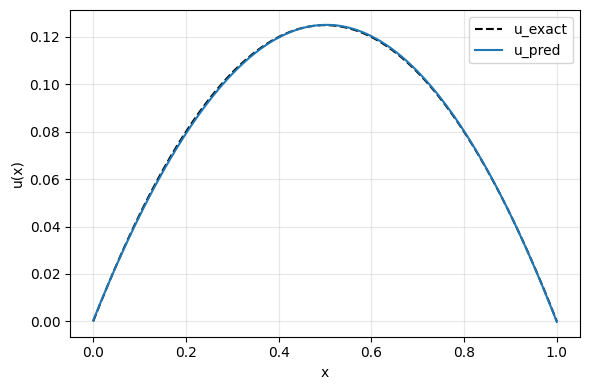

u(0) approx: 0.00037488108109584437   u(1) approx: -0.0002266673674616561
L2 error (grid): 0.00040409103981331863


In [10]:
# Comparison with the true solution u_exact(x) = 0.5 * x * (1-x)
x_grid = np.linspace(0, 1, 201)
x_in = np.clip(x_grid, 1e-6, 1 - 1e-6)
batch = x_in.shape[0]

n_modes = model.layers[0].input_size
X0 = np.zeros((n_modes, batch), dtype=np.complex128)
X0[0, :] = x_in
if n_modes > 1:
    X0[1:, :] = 1.0
dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
d2X0 = np.zeros_like(X0)

XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)
u_pred, u_x_pred, u_xx_pred, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)

u_true = 0.5 * x_grid * (1 - x_grid)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(x_grid, u_true, 'k--', label='u_exact')
plt.plot(x_grid, u_pred, 'C0', label='u_pred')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

print('u(0) approx:', u_pred[0], '  u(1) approx:', u_pred[-1])
print('L2 error (grid):', np.sqrt(np.mean((u_pred - u_true)**2)))

In [11]:
# Pull hyperparams from the training cell (authoritative)
required = ['init_seed', 'train_seed', 'N', 'epochs_pde', 'batch_size_pde', 'step_size_pde', 'lambda_bc_pde', 'losses_pde']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for Poisson 1D (f=1, Dirichlet): ' + ', '.join(missing) + '. Run the training cell first.')
init_seed_snap = int(init_seed)
train_seed_snap = int(train_seed)
N_snap = int(N)
epochs_final_snap = len(losses_pde)
batch_size_snap = int(batch_size_pde)
step_size_snap = float(step_size_pde)
lambda_bc_snap = float(lambda_bc_pde)

# Choose snapshot iterations: first, middle, final
epoch_first = 0
epoch_mid = epochs_final_snap // 2
epoch_final = epochs_final_snap - 1

# Evaluation grid for plotting snapshots (keep moderate for speed)
x_plot = np.linspace(0, 1, 401)
x_plot_in = np.clip(x_plot, 1e-6, 1 - 1e-6)
u_exact = 0.5 * x_plot * (1 - x_plot)

def _build_model_for_snapshots(init_seed: int, N: int):
    np.random.seed(init_seed)
    return neu.Sequential([
        neu.ClementsLayer(N),
        neu.Activation(ComplexSquared(N)),
        neu.ClementsLayer(N),
        neu.Activation(ComplexSquared(N)),
    ])

def _train_model_for_epochs(epochs: int):
    model_snap = _build_model_for_snapshots(init_seed_snap, N_snap)
    losses_snap = fit_unsupervised_insitu_adam(
        model_snap,
        epochs=epochs,
        batch_size=batch_size_snap,
        step_size=step_size_snap,
        seed=train_seed_snap,
        lambda_bc=lambda_bc_snap,
    )
    return model_snap, losses_snap

def _eval_u_on_grid(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

# Reuse the existing final training result if available; otherwise train once
if 'model' in globals() and 'losses_pde' in globals() and hasattr(losses_pde, '__len__') and len(losses_pde) >= epochs_final_snap:
    model_final_snap = model
    losses_final_snap = losses_pde[:epochs_final_snap]
else:
    model_final_snap, losses_final_snap = _train_model_for_epochs(epochs_final_snap)

# For snapshots at earlier iterations, retrain deterministically from the same init/seed
model_first_snap, _ = _train_model_for_epochs(epoch_first + 1)
model_mid_snap, _ = _train_model_for_epochs(epoch_mid + 1)

u_pred_first = _eval_u_on_grid(model_first_snap, x_plot_in)
u_pred_mid = _eval_u_on_grid(model_mid_snap, x_plot_in)
u_pred_final = _eval_u_on_grid(model_final_snap, x_plot_in)

print('Snapshot iterations:', {'first': epoch_first + 1, 'mid': epoch_mid + 1, 'final': epoch_final + 1})
print('Final loss:', losses_final_snap[-1])

epoch 200/501  loss=-3.647143e-02
epoch 400/501  loss=-4.840293e-02
Snapshot iterations: {'first': 1, 'mid': 501, 'final': 1000}
Final loss: -0.030803811231907566


In [12]:
# --- Circuit info only: architecture, modes, encoding (prints only) ---
import numpy as np

print('=== CIRCUIT / MODEL INFO ===')
if 'model' not in globals():
    raise RuntimeError('No `model` found in globals(). Run the model construction/training cell first.')

layers = list(getattr(model, 'layers', []))
print('Model type:', type(model))
print('Number of layers:', len(layers))

# Number of modes/ports (taken from the first layer when available)
if len(layers) > 0 and hasattr(layers[0], 'input_size'):
    n_modes = int(layers[0].input_size)
else:
    n_modes = int(N) if 'N' in globals() else None
print('Number of modes (N):', n_modes)

print('\nLayers:')
for i, layer in enumerate(layers):
    layer_name = layer.__class__.__name__
    desc = [f'[{i}] {layer_name}']
    if hasattr(layer, 'input_size'):
        desc.append(f"in={getattr(layer, 'input_size')}")
    if hasattr(layer, 'output_size'):
        desc.append(f"out={getattr(layer, 'output_size')}")
    if hasattr(layer, 'mesh'):
        mesh = getattr(layer, 'mesh')
        desc.append(f"mesh={mesh.__class__.__name__}")
        if hasattr(mesh, 'all_tunable_components'):
            cmpts = list(mesh.all_tunable_components())
            dof_total = int(sum(int(getattr(c, 'dof', 0)) for c in cmpts))
            desc.append(f"tunable_components={len(cmpts)}")
            desc.append(f"total_dof={dof_total}")
    print('  ' + '  |  '.join(desc))

print('\n=== RUN PARAMETERS (from current globals) ===')
def _maybe(name):
    return globals()[name] if name in globals() else None

print('Training cell params:')
print('  init_seed =', _maybe('init_seed'))
print('  train_seed =', _maybe('train_seed'))
print('  N =', _maybe('N'))

print('Snapshot cell params:')
print('  init_seed_snap =', _maybe('init_seed_snap'))
print('  train_seed_snap =', _maybe('train_seed_snap'))
print('  N_snap =', _maybe('N_snap'))
print('  epochs_final_snap =', _maybe('epochs_final_snap'))
print('  batch_size_snap =', _maybe('batch_size_snap'))
print('  step_size_snap =', _maybe('step_size_snap'))
print('  lambda_bc_snap =', _maybe('lambda_bc_snap'))

print('Per-iteration error cell params:')
print('  epochs_err =', _maybe('epochs_err'))
print('  n_eval_err =', _maybe('n_eval_err'))
print('  compute_every =', _maybe('compute_every'))
print('  step_size_err =', _maybe('step_size_err'))
print('  lambda_bc_err =', _maybe('lambda_bc_err'))

print('\n=== INPUT ENCODING (as implemented above) ===')
print('Using n_modes =', n_modes)
print('X0 construction:')
print('  X0 = zeros((n_modes, batch), complex128)')
print('  X0[0, :] = x')
if n_modes is None:
    print('  X0[1:, :] = 1.0   (cannot confirm n_modes>1 because n_modes is None)')
elif n_modes > 1:
    print('  X0[1:, :] = 1.0')
else:
    print('  (n_modes==1) => no X0[1:, :] rows exist')

print('dX0 construction:')
print('  dX0 = zeros_like(X0)')
print('  dX0[0, :] = 1.0')
print('d2X0 construction:')
print('  d2X0 = zeros_like(X0)')

=== CIRCUIT / MODEL INFO ===
Model type: <class 'neuroptica.models.Sequential'>
Number of layers: 4
Number of modes (N): 3

Layers:
  [0] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [1] Activation  |  in=3  |  out=3
  [2] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [3] Activation  |  in=3  |  out=3

=== RUN PARAMETERS (from current globals) ===
Training cell params:
  init_seed = 0
  train_seed = 1
  N = 3
Snapshot cell params:
  init_seed_snap = 0
  train_seed_snap = 1
  N_snap = 3
  epochs_final_snap = 1000
  batch_size_snap = 64
  step_size_snap = 0.02
  lambda_bc_snap = 50.0
Per-iteration error cell params:
  epochs_err = None
  n_eval_err = None
  compute_every = None
  step_size_err = None
  lambda_bc_err = None

=== INPUT ENCODING (as implemented above) ===
Using n_modes = 3
X0 construction:
  X0 = zeros((n_modes, batch), complex128)
  X0[0, :] = x
  X0[1:, :] = 1.0
dX0 cons

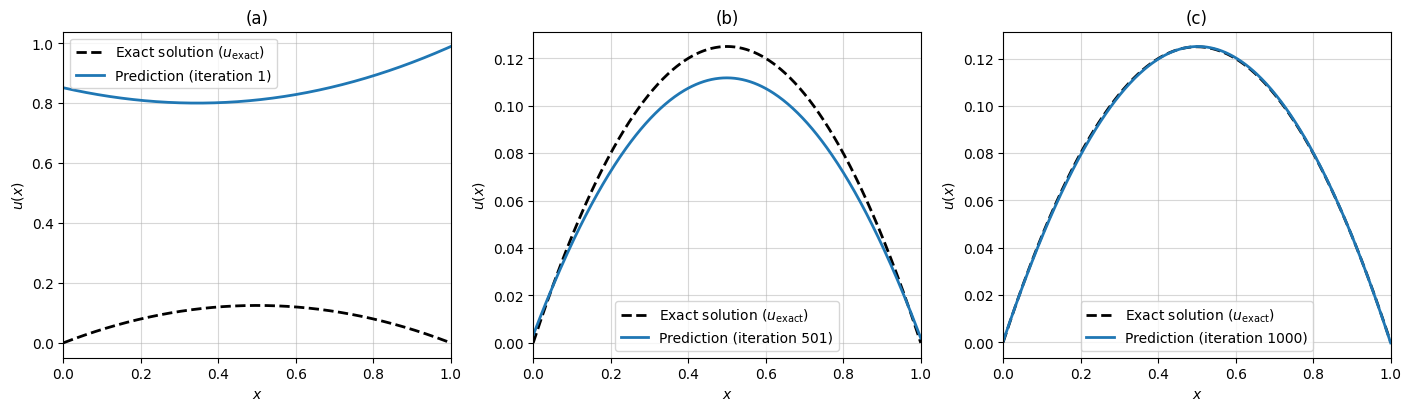

In [13]:
# --- Paper-style figure: predictions at 1 / mid / final (solutions only) ---
def _style_axes(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

fig, (ax_first, ax_mid, ax_final) = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

def _plot_panel(ax, u_pred, it_number, title):
    ax.plot(x_plot, u_exact, 'k--', linewidth=2.0, label=r'Exact solution ($u_{\mathrm{exact}}$)')
    ax.plot(x_plot, u_pred, color='C0', linewidth=2.0, label=f'Prediction (iteration {it_number})')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$u(x)$')
    ax.set_title(title)
    _style_axes(ax)
    ax.legend(frameon=True)

# (a) After first iteration
_plot_panel(ax_first, u_pred_first, epoch_first + 1, '(a)')

# (b) Middle iteration
_plot_panel(ax_mid, u_pred_mid, epoch_mid + 1, '(b)')

# (c) After training
_plot_panel(ax_final, u_pred_final, epoch_final + 1, '(c)')

plt.show()

In [14]:
# --- Save paper-ready solutions figure (added cell) ---
import os

# This cell assumes you've run the previous cell that creates `fig` (the 1x3 solutions plot).
if 'fig' not in globals():
    raise RuntimeError('Run the solutions-only plotting cell first so `fig` exists.')

out_name = 'pde1d_solutions.pdf'
fig.savefig(out_name, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_solutions.pdf


In [15]:
# --- Extra diagnostics: relative L2 error per iteration (added cell) ---
# NOTE: This retrains from scratch (same init/seed) to get the full per-iteration curve.
# It can take a while because it evaluates u(x) every iteration.

# You can reduce the cost by lowering n_eval_err or setting compute_every > 1.
n_eval_err = 101          # number of grid points for error evaluation
compute_every = 1         # compute error every this many iterations (1 = every iteration)
# Pull hyperparams from the training cell (authoritative)
required = ['init_seed', 'train_seed', 'N', 'batch_size_pde', 'step_size_pde', 'lambda_bc_pde', 'losses_pde']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for Poisson 1D (f=1, Dirichlet) diagnostics: ' + ', '.join(missing) + '. Run the training cell first.')
epochs_err = len(losses_pde)
init_seed_err = int(init_seed)
train_seed_err = int(train_seed)
N_err = int(N)
batch_size_err = int(batch_size_pde)
step_size_err = float(step_size_pde)
lambda_bc_err = float(lambda_bc_pde)

x_err = np.linspace(0.0, 1.0, n_eval_err)
x_err_in = np.clip(x_err, 1e-6, 1.0 - 1e-6)
u_exact_err = 0.5 * x_err * (1 - x_err)
den = float(np.sqrt(np.mean(u_exact_err**2)))
den = den if den > 0 else 1.0

def _eval_u_real(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def train_pde_with_l2_curve():
    # Local RNG for deterministic sampling
    rng = np.random.default_rng(train_seed_err)

    np.random.seed(init_seed_err)
    model_err = neu.Sequential([
        neu.ClementsLayer(N_err),
        neu.Activation(ComplexSquared(N_err)),
        neu.ClementsLayer(N_err),
        neu.Activation(ComplexSquared(N_err))
    ])

    # Adam state (copied pattern from fit_unsupervised_insitu_adam)
    m = {}
    v = {}
    t = 0
    for layer in model_err.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses_signed = []
    rel_l2 = []
    iters = []

    n_modes = model_err.layers[0].input_size

    for epoch in range(epochs_err):
        t += 1
        # sample
        x_int = rng.random(batch_size_err)
        x_int = np.clip(x_int, 1e-6, 1 - 1e-6)
        if lambda_bc_err > 0.0:
            x_bc = np.array([0.0, 1.0], dtype=np.float64)
            x = np.concatenate([x_int, x_bc], axis=0)
            is_bc = np.zeros((x.shape[0],), dtype=bool)
            is_bc[-2:] = True
        else:
            x = x_int
            is_bc = np.zeros((x.shape[0],), dtype=bool)

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model_err.forward_pass(X0)
        XL, dXL, d2XL = forward_pass_derivatives(model_err, X0, dX0, d2X0)
        loss, d_loss_star = build_dloss_star(
            x, XL, dXL, d2XL, f_value=1.0, a=None, b=0.0, is_bc=is_bc, lambda_bc=lambda_bc_err
        )
        losses_signed.append(float(loss))

        deltas = model_err.backward_pass(d_loss_star)
        delta_prev = d_loss_star

        for layer in reversed(model_err.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(layer.input_prev, delta_prev)
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = 0.9 * m[cmpt] + (1 - 0.9) * g
                    v[cmpt] = 0.99 * v[cmpt] + (1 - 0.99) * (g ** 2)
                    mhat = m[cmpt] / (1 - 0.9 ** t)
                    vhat = v[cmpt] / (1 - 0.99 ** t)
                    step = -step_size_err * mhat / (np.sqrt(vhat) + 1e-8)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        # metric (after update)
        if (epoch % compute_every) == 0:
            u_pred_err = _eval_u_real(model_err, x_err_in)
            num = float(np.sqrt(np.mean((u_pred_err - u_exact_err) ** 2)))
            rel = num / den
            iters.append(epoch + 1)
            rel_l2.append(rel)

        if (epoch + 1) % 500 == 0:
            print(f"iter {epoch+1}/{epochs_err}  loss={loss:+.3e}  relL2(last)={rel_l2[-1]:.3e}")

    return model_err, losses_signed, np.array(iters), np.array(rel_l2)

model_err, losses_signed_err, iters_err, rel_l2_err = train_pde_with_l2_curve()
print('Done. Final signed loss:', losses_signed_err[-1], ' Final rel L2:', rel_l2_err[-1])

iter 500/1000  loss=-4.112e-02  relL2(last)=1.030e-01
iter 1000/1000  loss=-3.080e-02  relL2(last)=4.445e-03
Done. Final signed loss: -0.030803811231907566  Final rel L2: 0.004445075640421769


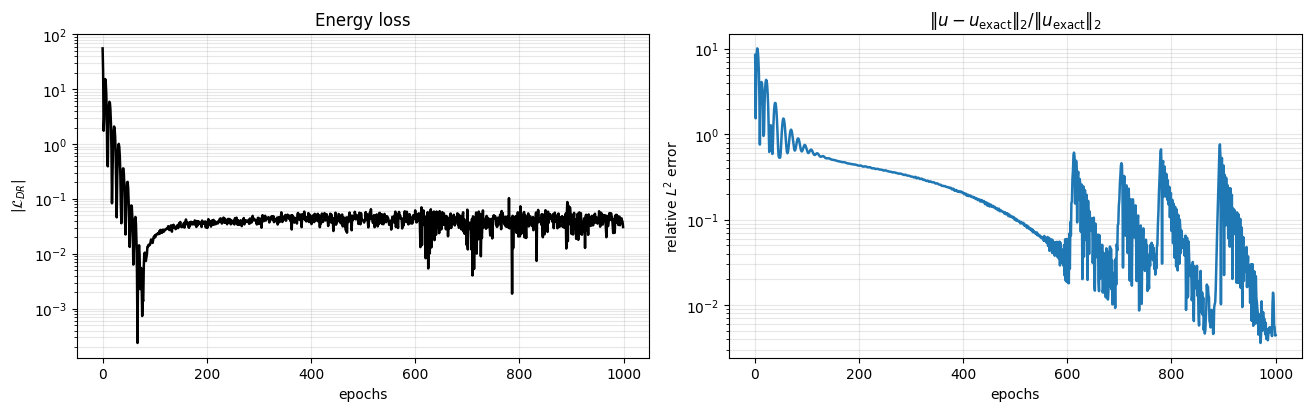

In [16]:
# Plotting |loss| and relative L2 error (paper-ready)
if 'losses_signed_err' not in globals() or 'rel_l2_err' not in globals():
    raise RuntimeError('Run the previous cell (per-iteration error logging) first.')

loss_arr = np.asarray(losses_signed_err, dtype=float)
abs_loss = np.abs(loss_arr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

# Absolute energy loss
ax1.plot(abs_loss, color='k', linewidth=1.8)
ax1.set_xlabel('epochs')
ax1.set_ylabel(r'$|\mathcal{L}_{DR}|$')
ax1.set_yscale('log')
ax1.set_title('Energy loss')
ax1.grid(True, which='both', alpha=0.3)

# Relative L2 error
ax2.plot(iters_err, rel_l2_err, color='C0', linewidth=1.8)
ax2.set_xlabel('epochs')
ax2.set_ylabel(r'relative $L^2$ error')
ax2.set_yscale('log')
ax2.set_title(r'$\|u-u_{\mathrm{exact}}\|_2 / \|u_{\mathrm{exact}}\|_2$')
ax2.grid(True, which='both', alpha=0.3)

plt.show()


In [17]:
# --- Save paper-ready losses figure (added cell) ---
import os

# This cell assumes you've run the previous loss-plot cell that creates `fig`.
if 'fig' not in globals():
    raise RuntimeError('Run the losses plotting cell first so `fig` exists.')

out_name_losses = 'pde1d_losses.pdf'
fig.savefig(out_name_losses, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_losses))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_losses.pdf


## Diagnostics (optional)

Even when the solution curve looks right, it’s useful to check the *strong-form* residual on a dense grid:
$$r(x)=u_{xx}(x)+f(x).$$

For the current Poisson test we used $f(x)=1$, so $r(x)=u_{xx}(x)+1$ (ideally near zero away from the boundary).

## Interpreting the loss and the residual (why they can be misleading)

### 1) Why the loss can be “small” even when $u(x)$ looks wrong

The “loss” is **not** an $L^2$ error of $(u-u^*)$: it is the **Deep Ritz variational energy**.

- It is an **average** over $x$: if the error is large only “at a few points”, the average can still be small.
- $\mathcal{L}_{DR}$ mainly “sees” $u_x$ (and $u$ weighted by $f$): two curves can have similar energy while differing visibly in some regions.
- For Poisson with $f=1$ and exact Dirichlet conditions, the exact minimizer has interior energy
  $$\mathcal{L}_{DR}(u^*)=-\tfrac{1}{24}\approx -0.0417.$$
  We achieved a final loss of `-0.0308`, whose absolute value does **not** necessarily mean “almost perfect solution”: it is simply a value consistent with the problem’s scale in which we have to consider Monte Carlo noise and the effect of the penalty term, that is included artificially. The little positive bias is due to the predicted values of the function at the boundary points.

### 2) Why the residual is large near the boundaries even if $u(0)\approx u(1)\approx 0$

In the following plot we show the **strong-form residual**
$$r(x)=u_{xx}(x)+f(x).$$

- The Deep Ritz objective is a **weak/energy** criterion. It does not directly force the strong equation $u_{xx}+f=0$ at every point. So it is normal that the residual is not uniformly small everywhere, especially early in training or near regions where the solution changes rapidly.
- The Dirichlet boundary condition is imposed via a **penalty** term (large $\lambda_{bc}$). That strongly encourages the *values* at $x=0,1$ to be near zero, but it does not constrain the *curvature* $u_{xx}$ at the boundary. This often creates a thin **boundary region** where $u$ bends quickly to satisfy the endpoints and $u_{xx}$ (hence the residual) can become large near the edges.

Moreover we also use **clipping** $x\mapsto \mathrm{clip}(x,\varepsilon,1-\varepsilon)$ when computing derivatives/residual:

- Numerically, evaluating derivative-based quantities exactly at $x=0$ and $x=1$ is often misleading: those points are “special” because they are included mainly for the boundary penalty and the strong-form residual there is not what the variational training is optimizing.
- Clipping ensures we evaluate $u_x$, $u_{xx}$, and $r(x)$ at *interior* points ($x\in(\varepsilon,1-\varepsilon)$), where the strong form is more meaningful and where the derivative propagation is typically more stable.
- Practically, this avoids showing artificial spikes that come purely from probing the very endpoints rather than the interior PDE satisfaction.

### 3) How to better stabilize the boundaries (practical options)

If you want to reduce the residual near the boundaries these are the most effective moves:
1. **Hard Dirichlet ansatz**: parameterize $u(x)=x(1-x)g(x)$ (so $u(0)=u(1)=0$ exactly and you can set `lambda_bc=0`). This is the cleanest way to remove the stiffness introduced by the penalty but it is not generalizable.
2. **More near-boundary samples**: in addition to the two points $\{0,1\}$, also sample points in $[0,\delta]\cup[1-\delta,1]$ (e.g., $\delta=0.02$) and include them in the loss (possibly with a slightly larger weight).
3. **Curriculum on $\lambda_{bc}$**: start with a small $\lambda_{bc}$ (or 0) and increase it progressively during training. This helps avoid the training getting “stuck” optimizing only the boundaries.

Residual diagnostics for f(x)=1 (r=u_xx+1) on dense grid
  RMS residual: 0.03530349773344521
  Max |residual|: 0.10387274668421331


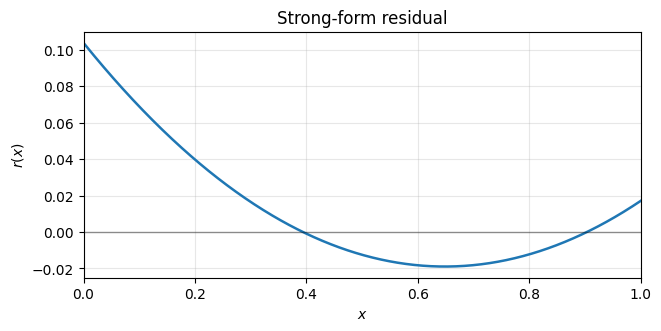

In [18]:
# Residual metrics for the current trained `model` on a dense grid.
# Uses the same readout u(x)=Re(a^H X_L)+b with default a selecting port 0.

def eval_on_grid(model, n_grid: int = 401, a=None, b: float = 0.0, clip_eps: float = 1e-6):
    x_grid = np.linspace(0.0, 1.0, n_grid)
    x_in = np.clip(x_grid, clip_eps, 1.0 - clip_eps)
    batch = x_in.shape[0]
    n_modes = model.layers[0].input_size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)
    u, u_x, u_xx, _ = linear_readout(x_in, XL, dXL, d2XL, a=a, b=b)
    return x_grid, x_in, u, u_x, u_xx

# Current Poisson: f(x)=1 -> residual r=u_xx+1
x_grid_d, x_in_d, u_d, u_x_d, u_xx_d = eval_on_grid(model, n_grid=801)
r = u_xx_d + 1.0

r_rms = float(np.sqrt(np.mean(r**2)))
r_max = float(np.max(np.abs(r)))
print("Residual diagnostics for f(x)=1 (r=u_xx+1) on dense grid")
print("  RMS residual:", r_rms)
print("  Max |residual|:", r_max)

# Paper-style plot (match the style of the figures above)
fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x_grid_d, r, linewidth=1.8)
ax.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$r(x)$')
ax.set_title(r'Strong-form residual')
ax.grid(True, which='both', alpha=0.3)
plt.show()

In [19]:
# --- Save paper-ready residuals figure (added cell) ---
import os

# This cell assumes you've run the previous residual-plot cell that creates `fig`.
if 'fig' not in globals():
    raise RuntimeError('Run the residual plotting cell first so `fig` exists.')

out_name_residuals = 'pde1d_residuals.pdf'
fig.savefig(out_name_residuals, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_residuals))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_residuals.pdf


## B2: Dirichlet BC, sinusoidal forcing $f(x)=\sin(\pi x)$

We now solve
$$-u''(x)=\sin(\pi x),\qquad u(0)=u(1)=0.$$
The exact solution is
$$u_{exact}(x)=\frac{\sin(\pi x)}{\pi^2}.$$

This is a better stress-test than constant forcing because the optimal solution has a different shape and the loss uses a point-dependent forcing term.

In [20]:
# We DO NOT touch the existing build_dloss_star / fit_unsupervised_insitu_adam; we define new ones here.

def build_dloss_star_fx(
    x: np.ndarray,
    XL: np.ndarray,
    dXL: np.ndarray,
    d2XL: np.ndarray,
    f_fn,
    a: np.ndarray | None = None,
    b: float = 0.0,
    is_bc: np.ndarray | None = None,
    lambda_bc: float = 0.0,
 ):
    batch_total = x.shape[0]
    if is_bc is None:
        is_bc = np.zeros((batch_total,), dtype=bool)
    else:
        is_bc = np.asarray(is_bc, dtype=bool)
        if is_bc.shape != (batch_total,):
            raise ValueError(f"is_bc must have shape (batch,), got {is_bc.shape}")

    u, du, d2u, du_dXL_star = linear_readout(x, XL, dXL, d2XL, a=a, b=b)
    idx_int = np.where(~is_bc)[0]
    idx_bc = np.where(is_bc)[0]
    if idx_int.size == 0:
        raise ValueError("Need at least 1 interior point.")

    # interior
    u_int = u[idx_int]
    du_int = du[idx_int]
    d2u_int = d2u[idx_int]
    du_star_int = du_dXL_star[:, idx_int]
    x_int = x[idx_int]
    f_int = np.asarray(f_fn(x_int), dtype=np.float64).reshape(-1)
    if f_int.shape != (idx_int.size,):
        raise ValueError("f_fn(x) must return shape (n_int,)")
    g_int = 0.5 * (np.abs(du_int) ** 2) - f_int * u_int
    loss_interior = float(np.mean(g_int))
    batch_interior = idx_int.size
    residual_int = (-(d2u_int + f_int) / batch_interior).astype(np.float64)
    d_loss_star_int = (du_star_int * residual_int[None, :]).astype(np.complex128)

    # boundary penalty (Dirichlet)
    loss_boundary = 0.0
    d_loss_star_bc = np.zeros((XL.shape[0], 0), dtype=np.complex128)
    if lambda_bc > 0.0:
        if idx_bc.size == 0:
            raise ValueError("lambda_bc > 0 but no BC points were provided.")
        u_bc = u[idx_bc]
        du_star_bc = du_dXL_star[:, idx_bc]
        n_bc = idx_bc.size
        loss_boundary = float(lambda_bc * 0.5 * np.mean(u_bc ** 2))
        w_bc = (lambda_bc / n_bc)
        d_loss_star_bc = (du_star_bc * (w_bc * u_bc)[None, :]).astype(np.complex128)

    d_loss_star = np.zeros_like(XL, dtype=np.complex128)
    d_loss_star[:, idx_int] = d_loss_star_int
    if idx_bc.size > 0 and lambda_bc > 0.0:
        d_loss_star[:, idx_bc] = d_loss_star_bc
    return loss_interior + loss_boundary, d_loss_star

def fit_unsupervised_insitu_adam_fx(
    model: neu.Sequential,
    f_fn,
    epochs: int = 800,
    batch_size: int = 64,
    step_size: float = 0.005,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    seed: int = 0,
    cache_fields: bool = False,
    use_partial_vectors: bool = False,
    a: np.ndarray | None = None,
    b: float = 0.0,
    lambda_bc: float = 2000.0,
 ):
    rng = np.random.default_rng(seed)
    m = {}
    v = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)
    losses = []
    n_modes = model.layers[0].input_size

    for epoch in range(epochs):
        t += 1
        x_int = rng.random(batch_size)
        x_int = np.clip(x_int, 1e-6, 1 - 1e-6)
        if lambda_bc > 0.0:
            x_bc = np.array([0.0, 1.0], dtype=np.float64)
            x = np.concatenate([x_int, x_bc], axis=0)
            is_bc = np.zeros((x.shape[0],), dtype=bool)
            is_bc[-2:] = True
        else:
            x = x_int
            is_bc = np.zeros((x.shape[0],), dtype=bool)
        batch_total = x.shape[0]

        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)

        loss, d_loss_star = build_dloss_star_fx(
            x, XL, dXL, d2XL, f_fn=f_fn, a=a, b=b, is_bc=is_bc, lambda_bc=lambda_bc
        )
        losses.append(loss)

        deltas = model.backward_pass(d_loss_star, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        delta_prev = d_loss_star
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev,
                    delta_prev,
                    cache_fields=cache_fields,
                    use_partial_vectors=use_partial_vectors,
                )
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = beta1 * m[cmpt] + (1 - beta1) * g
                    v[cmpt] = beta2 * v[cmpt] + (1 - beta2) * (g ** 2)
                    mhat = m[cmpt] / (1 - beta1 ** t)
                    vhat = v[cmpt] / (1 - beta2 ** t)
                    step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch + 1) % 200 == 0:
            print(f"epoch {epoch+1}/{epochs}  loss={loss:.6e}")
    return losses

In [21]:
# Run the variable-forcing test: f(x)=sin(pi x). (TRAINING CELL)
# Like the Poisson cell above, we rebuild the model from a fixed init seed each time for reproducibility.


def f_sinpi(x):
    return np.sin(np.pi * x)


def u_true_sinpi(x):
    return np.sin(np.pi * x) / (np.pi**2)


# Reproducibility controls
init_seed = 0
train_seed = 1  # controls sampling inside fit_unsupervised_insitu_adam_fx (deterministic via default_rng)

# Canonical hyperparameters for this benchmark (used by all downstream paper/diagnostics cells)
N_sin = 3
epochs_sin = 7000
batch_size_sin = 64
step_size_sin = 0.02
lambda_bc_sin = 200.0


# Build (or reuse) a model-builder
if "build_photonic_model" not in globals():
    def build_photonic_model(N: int = 3, seed: int = 0) -> neu.Sequential:
        np.random.seed(seed)
        return neu.Sequential([
            neu.ClementsLayer(N),
            neu.Activation(ComplexSquared(N)),
            neu.ClementsLayer(N),
            neu.Activation(ComplexSquared(N)),
        ])


model_sin = build_photonic_model(N=int(N_sin), seed=int(init_seed))
losses_sin = fit_unsupervised_insitu_adam_fx(
    model_sin,
    f_fn=f_sinpi,
    epochs=int(epochs_sin),
    batch_size=int(batch_size_sin),
    step_size=float(step_size_sin),
    seed=int(train_seed),
    lambda_bc=float(lambda_bc_sin),
 )
print('final loss (sin forcing):', losses_sin[-1])

epoch 200/7000  loss=-2.982329e-03
epoch 400/7000  loss=-2.204504e-02
epoch 600/7000  loss=-2.403493e-02
epoch 800/7000  loss=3.844448e-02
epoch 1000/7000  loss=4.114600e-02
epoch 1200/7000  loss=1.085893e-01
epoch 1400/7000  loss=-2.542810e-02
epoch 1600/7000  loss=-2.456767e-02
epoch 1800/7000  loss=-7.129896e-03
epoch 2000/7000  loss=-3.187398e-02
epoch 2200/7000  loss=-2.002737e-02
epoch 2400/7000  loss=-1.494651e-02
epoch 2600/7000  loss=-3.234561e-02
epoch 2800/7000  loss=-2.401368e-02
epoch 3000/7000  loss=-2.369223e-02
epoch 3200/7000  loss=-2.181525e-02
epoch 3400/7000  loss=-2.193516e-02
epoch 3600/7000  loss=-2.153903e-02
epoch 3800/7000  loss=-1.833258e-02
epoch 4000/7000  loss=-2.673281e-02
epoch 4200/7000  loss=-2.326111e-02
epoch 4400/7000  loss=-3.076773e-02
epoch 4600/7000  loss=-3.552335e-02
epoch 4800/7000  loss=-3.710015e-02
epoch 5000/7000  loss=-2.251619e-02
epoch 5200/7000  loss=-2.609033e-02
epoch 5400/7000  loss=-2.596982e-02
epoch 5600/7000  loss=-2.491226e-02

In [22]:
# --- Circuit info only (variable forcing): architecture, modes, encoding ---
import numpy as np

print('=== CIRCUIT / MODEL INFO (variable forcing) ===')
if 'model_sin' not in globals():
    raise RuntimeError('No `model_sin` found in globals(). Run the variable-forcing training cell first.')

layers = list(getattr(model_sin, 'layers', []))
print('Model type:', type(model_sin))
print('Number of layers:', len(layers))

# Number of modes/ports (taken from the first layer when available)
if len(layers) > 0 and hasattr(layers[0], 'input_size'):
    n_modes = int(layers[0].input_size)
else:
    n_modes = None
print('Number of modes (N):', n_modes)

print('\nLayers:')
for i, layer in enumerate(layers):
    layer_name = layer.__class__.__name__
    desc = [f'[{i}] {layer_name}']
    if hasattr(layer, 'input_size'):
        desc.append(f"in={getattr(layer, 'input_size')}")
    if hasattr(layer, 'output_size'):
        desc.append(f"out={getattr(layer, 'output_size')}")
    if hasattr(layer, 'mesh'):
        mesh = getattr(layer, 'mesh')
        desc.append(f"mesh={mesh.__class__.__name__}")
        if hasattr(mesh, 'all_tunable_components'):
            cmpts = list(mesh.all_tunable_components())
            dof_total = int(sum(int(getattr(c, 'dof', 0)) for c in cmpts))
            desc.append(f"tunable_components={len(cmpts)}")
            desc.append(f"total_dof={dof_total}")
    print('  ' + '  |  '.join(desc))

print('\n=== RUN PARAMETERS (from current globals) ===')
def _maybe(name):
    return globals()[name] if name in globals() else None

print('Variable forcing params:')
print('  init_seed =', _maybe('init_seed'))
print('  train_seed =', _maybe('train_seed'))
print('  epochs (len(losses_sin)) =', len(losses_sin) if 'losses_sin' in globals() else None)

print('\n=== INPUT ENCODING (as implemented) ===')
print('Using n_modes =', n_modes)
print('X0 construction:')
print('  X0 = zeros((n_modes, batch), complex128)')
print('  X0[0, :] = x')
if n_modes is None:
    print('  X0[1:, :] = 1.0   (cannot confirm n_modes>1 because n_modes is None)')
elif n_modes > 1:
    print('  X0[1:, :] = 1.0')
else:
    print('  (n_modes==1) => no X0[1:, :] rows exist')

print('dX0 construction:')
print('  dX0 = zeros_like(X0)')
print('  dX0[0, :] = 1.0')
print('d2X0 construction:')
print('  d2X0 = zeros_like(X0)')

=== CIRCUIT / MODEL INFO (variable forcing) ===
Model type: <class 'neuroptica.models.Sequential'>
Number of layers: 4
Number of modes (N): 3

Layers:
  [0] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [1] Activation  |  in=3  |  out=3
  [2] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [3] Activation  |  in=3  |  out=3

=== RUN PARAMETERS (from current globals) ===
Variable forcing params:
  init_seed = 0
  train_seed = 1
  epochs (len(losses_sin)) = 7000

=== INPUT ENCODING (as implemented) ===
Using n_modes = 3
X0 construction:
  X0 = zeros((n_modes, batch), complex128)
  X0[0, :] = x
  X0[1:, :] = 1.0
dX0 construction:
  dX0 = zeros_like(X0)
  dX0[0, :] = 1.0
d2X0 construction:
  d2X0 = zeros_like(X0)


epoch 200/3500  loss=-2.982329e-03
epoch 400/3500  loss=-2.204504e-02
epoch 600/3500  loss=-2.403493e-02
epoch 800/3500  loss=3.844448e-02
epoch 1000/3500  loss=4.114600e-02
epoch 1200/3500  loss=1.085893e-01
epoch 1400/3500  loss=-2.542810e-02
epoch 1600/3500  loss=-2.456767e-02
epoch 1800/3500  loss=-7.129896e-03
epoch 2000/3500  loss=-3.187398e-02
epoch 2200/3500  loss=-2.002737e-02
epoch 2400/3500  loss=-1.494651e-02
epoch 2600/3500  loss=-3.234561e-02
epoch 2800/3500  loss=-2.401368e-02
epoch 3000/3500  loss=-2.369223e-02
epoch 3200/3500  loss=-2.181525e-02
epoch 3400/3500  loss=-2.193516e-02
Variable forcing snapshot iterations: {'first': 1, 'mid': 3500, 'final': 7000}
Final loss (sin forcing): -0.014193601459454286


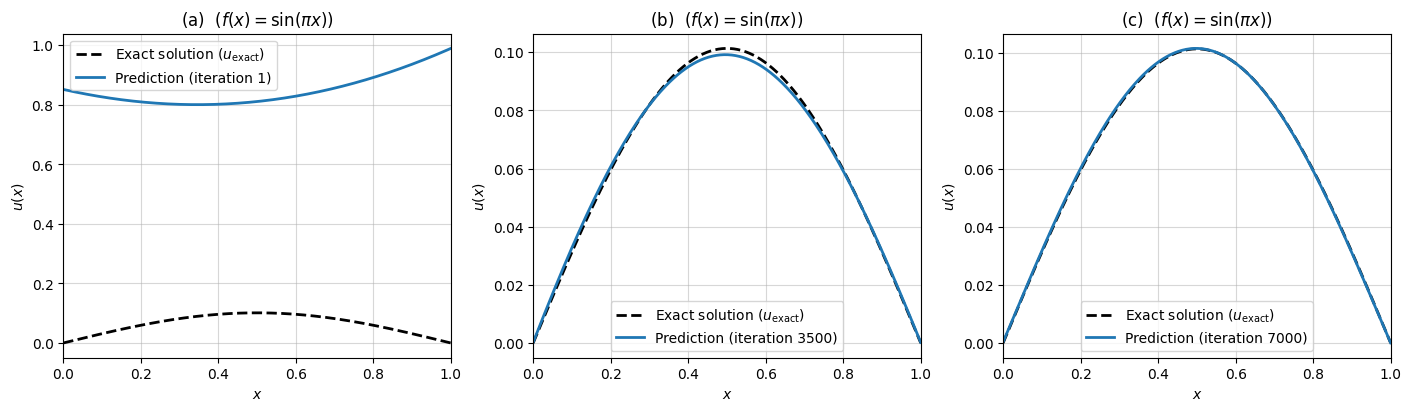

In [23]:
# --- Paper-style figure (variable forcing): predictions at 1 / mid / final (solutions only) ---
if 'f_sinpi' not in globals() or 'u_true_sinpi' not in globals():
    raise RuntimeError('Run the variable-forcing training cell first (defines f_sinpi/u_true_sinpi).')
if 'build_photonic_model' not in globals():
    raise RuntimeError('Expected build_photonic_model to exist (defined in the variable-forcing training cell).')
if 'fit_unsupervised_insitu_adam_fx' not in globals():
    raise RuntimeError('Expected fit_unsupervised_insitu_adam_fx to exist (defined earlier in the variable-forcing section).')

def _style_axes_paper(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

# Pull hyperparams from the training cell (authoritative)
required = ['init_seed', 'train_seed', 'N_sin', 'epochs_sin', 'batch_size_sin', 'step_size_sin', 'lambda_bc_sin', 'losses_sin']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for variable forcing (Dirichlet): ' + ', '.join(missing) + '. Run the training cell first.')
init_seed_sin = int(init_seed)
train_seed_sin = int(train_seed)
N_sin_val = int(N_sin)
batch_size_sin = int(batch_size_sin)
step_size_sin = float(step_size_sin)
lambda_bc_sin = float(lambda_bc_sin)

# How many epochs in the "final" model (reuse the existing run if available)
epochs_final_sin = len(losses_sin)
epoch_first_sin = 0
epoch_mid_sin = max(0, (epochs_final_sin // 2) - 1)
epoch_final_sin = epochs_final_sin - 1

# Grid for plotting/evaluation
x_plot_sin = np.linspace(0.0, 1.0, 401)
x_plot_in_sin = np.clip(x_plot_sin, 1e-6, 1.0 - 1e-6)
u_exact_sin = u_true_sinpi(x_plot_sin)

def _eval_u_on_grid_sin(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def _train_model_sin_for_epochs(epochs: int):
    model_tmp = build_photonic_model(N=int(N_sin_val), seed=int(init_seed_sin))
    losses_tmp = fit_unsupervised_insitu_adam_fx(
        model_tmp,
        f_fn=f_sinpi,
        epochs=int(epochs),
        batch_size=int(batch_size_sin),
        step_size=float(step_size_sin),
        seed=int(train_seed_sin),
        lambda_bc=float(lambda_bc_sin),
    )
    return model_tmp, losses_tmp

# Reuse the existing trained model as the final snapshot when possible
if 'model_sin' in globals() and 'losses_sin' in globals() and isinstance(losses_sin, list) and len(losses_sin) >= (epoch_final_sin + 1):
    model_final_sin = model_sin
    losses_final_sin = losses_sin
else:
    model_final_sin, losses_final_sin = _train_model_sin_for_epochs(epoch_final_sin + 1)

# Retrain deterministically for first/mid snapshots (same init/seed)
model_first_sin, _ = _train_model_sin_for_epochs(epoch_first_sin + 1)
model_mid_sin, _ = _train_model_sin_for_epochs(epoch_mid_sin + 1)

u_pred_first_sin = _eval_u_on_grid_sin(model_first_sin, x_plot_in_sin)
u_pred_mid_sin = _eval_u_on_grid_sin(model_mid_sin, x_plot_in_sin)
u_pred_final_sin = _eval_u_on_grid_sin(model_final_sin, x_plot_in_sin)

print('Variable forcing snapshot iterations:', {'first': epoch_first_sin + 1, 'mid': epoch_mid_sin + 1, 'final': epoch_final_sin + 1})
print('Final loss (sin forcing):', float(losses_final_sin[-1]) if isinstance(losses_final_sin, list) and len(losses_final_sin) else None)

fig_sin_sol, (ax_first, ax_mid, ax_final) = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

def _plot_panel(ax, u_pred, it_number, title):
    ax.plot(x_plot_sin, u_exact_sin, 'k--', linewidth=2.0, label=r'Exact solution ($u_{\mathrm{exact}}$)')
    ax.plot(x_plot_sin, u_pred, color='C0', linewidth=2.0, label=f'Prediction (iteration {it_number})')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$u(x)$')
    ax.set_title(title + r'  ($f(x)=\sin(\pi x)$)')
    _style_axes_paper(ax)
    ax.legend(frameon=True)

_plot_panel(ax_first, u_pred_first_sin, epoch_first_sin + 1, '(a)')
_plot_panel(ax_mid, u_pred_mid_sin, epoch_mid_sin + 1, '(b)')
_plot_panel(ax_final, u_pred_final_sin, epoch_final_sin + 1, '(c)')

plt.show()

In [24]:
# --- Save paper-ready variable-forcing solution figure (added cell) ---
import os

if 'fig_sin_sol' not in globals():
    raise RuntimeError('Run the variable-forcing solution plotting cell first so `fig_sin_sol` exists.')

out_name_var_sol = 'pde1d_varforcing_solution.pdf'
fig_sin_sol.savefig(out_name_var_sol, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_var_sol))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_varforcing_solution.pdf


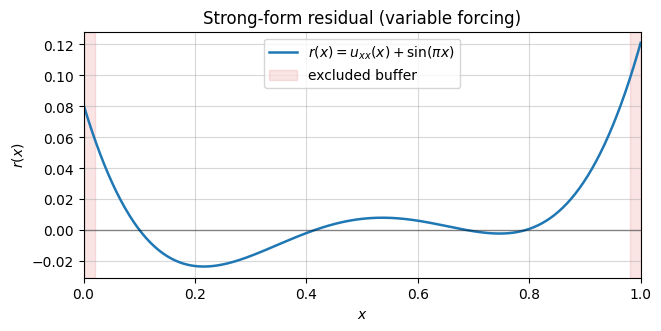

In [25]:
# --- Paper-style figure (variable forcing): strong-form residual ---
if 'model_sin' not in globals():
    raise RuntimeError('Run the variable-forcing training cell first so `model_sin` exists.')
if 'f_sinpi' not in globals():
    raise RuntimeError('Expected `f_sinpi` to be defined (see the variable-forcing section).')

# Fallback in case the styling helper is not in scope
if '_style_axes_paper' not in globals():
    def _style_axes_paper(ax):
        ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
        ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
        ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
        ax.set_xlim(0.0, 1.0)

# Evaluate residual on a dense interior grid
x_grid_res = np.linspace(0.0, 1.0, 401)
x_in_res = np.clip(x_grid_res, 1e-6, 1.0 - 1e-6)
batch_res = x_in_res.shape[0]
n_modes_res = model_sin.layers[0].input_size
X0_res = np.zeros((n_modes_res, batch_res), dtype=np.complex128)
X0_res[0, :] = x_in_res
if n_modes_res > 1:
    X0_res[1:, :] = 1.0
dX0_res = np.zeros_like(X0_res)
dX0_res[0, :] = 1.0
d2X0_res = np.zeros_like(X0_res)

XL_res, dXL_res, d2XL_res = forward_pass_derivatives(model_sin, X0_res, dX0_res, d2X0_res)
_, _, u_xx_res, _ = linear_readout(x_in_res, XL_res, dXL_res, d2XL_res, a=None, b=0.0)

r_sin = np.real(u_xx_res) + f_sinpi(x_in_res)
buffer = 0.02

fig_sin_res, ax = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x_in_res, r_sin, linewidth=1.8, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
ax.axvspan(1.0 - buffer, 1.0, color='C3', alpha=0.12)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$r(x)$')
ax.set_title('Strong-form residual (variable forcing)')
_style_axes_paper(ax)
ax.legend(frameon=True, loc='best')
plt.show()

In [26]:
# --- Save paper-ready variable-forcing residual figure (added cell) ---
import os

if 'fig_sin_res' not in globals():
    raise RuntimeError('Run the variable-forcing residual plotting cell first so `fig_sin_res` exists.')

out_name_var_res = 'pde1d_varforcing_residual.pdf'
fig_sin_res.savefig(out_name_var_res, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_var_res))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_varforcing_residual.pdf


In [27]:
# --- Extra diagnostics (variable forcing): relative L2 error per iteration (added cell) ---
# NOTE: This retrains from scratch (same init/seed) to get the full per-iteration curve.
# It can take a while because it evaluates u(x) during training.

# You can reduce cost by lowering n_eval_sin or setting compute_every_sin > 1.
n_eval_sin = 101
compute_every_sin = 10   # set to 1 for every iteration
required = ['init_seed', 'train_seed', 'N_sin', 'epochs_sin', 'batch_size_sin', 'step_size_sin', 'lambda_bc_sin', 'losses_sin']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for variable forcing (Dirichlet) diagnostics: ' + ', '.join(missing) + '. Run the training cell first.')
epochs_sin_err = len(losses_sin)
init_seed_sin = int(init_seed)
train_seed_sin = int(train_seed)
N_sin_val = int(N_sin)
batch_size_sin = int(batch_size_sin)
step_size_sin = float(step_size_sin)
lambda_bc_sin = float(lambda_bc_sin)

x_err_sin = np.linspace(0.0, 1.0, n_eval_sin)
x_err_in_sin = np.clip(x_err_sin, 1e-6, 1.0 - 1e-6)
u_exact_err_sin = u_true_sinpi(x_err_sin)
den_sin = float(np.sqrt(np.mean(u_exact_err_sin**2)))
den_sin = den_sin if den_sin > 0 else 1.0

def _eval_u_real_sin(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def train_sin_with_l2_curve():
    rng = np.random.default_rng(train_seed_sin)
    np.random.seed(init_seed_sin)
    model_err_sin = build_photonic_model(N=int(N_sin_val), seed=int(init_seed_sin))

    # Adam state
    m = {}
    v = {}
    t = 0
    for layer in model_err_sin.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses_signed_sin = []
    iters_sin = []
    rel_l2_sin = []

    n_modes = model_err_sin.layers[0].input_size

    for epoch in range(int(epochs_sin_err)):
        t += 1
        x_int = rng.random(int(batch_size_sin))
        x_int = np.clip(x_int, 1e-6, 1 - 1e-6)
        if lambda_bc_sin > 0.0:
            x_bc = np.array([0.0, 1.0], dtype=np.float64)
            x = np.concatenate([x_int, x_bc], axis=0)
            is_bc = np.zeros((x.shape[0],), dtype=bool)
            is_bc[-2:] = True
        else:
            x = x_int
            is_bc = np.zeros((x.shape[0],), dtype=bool)

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model_err_sin.forward_pass(X0)
        XL, dXL, d2XL = forward_pass_derivatives(model_err_sin, X0, dX0, d2X0)
        loss, d_loss_star = build_dloss_star_fx(
            x, XL, dXL, d2XL, f_fn=f_sinpi, a=None, b=0.0, is_bc=is_bc, lambda_bc=float(lambda_bc_sin)
        )
        losses_signed_sin.append(float(loss))

        deltas = model_err_sin.backward_pass(d_loss_star)
        delta_prev = d_loss_star
        for layer in reversed(model_err_sin.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(layer.input_prev, delta_prev)
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = 0.9 * m[cmpt] + (1 - 0.9) * g
                    v[cmpt] = 0.99 * v[cmpt] + (1 - 0.99) * (g ** 2)
                    mhat = m[cmpt] / (1 - 0.9 ** t)
                    vhat = v[cmpt] / (1 - 0.99 ** t)
                    step = -float(step_size_sin) * mhat / (np.sqrt(vhat) + 1e-8)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch % int(compute_every_sin)) == 0:
            u_pred_err = _eval_u_real_sin(model_err_sin, x_err_in_sin)
            num = float(np.sqrt(np.mean((u_pred_err - u_exact_err_sin) ** 2)))
            iters_sin.append(epoch + 1)
            rel_l2_sin.append(num / den_sin)

        if (epoch + 1) % 500 == 0:
            print(f"iter {epoch+1}/{int(epochs_sin_err)}  loss={loss:+.3e}  relL2(last)={rel_l2_sin[-1]:.3e}")

    return model_err_sin, losses_signed_sin, np.array(iters_sin), np.array(rel_l2_sin)

model_err_sin, losses_signed_sin, iters_sin, rel_l2_sin = train_sin_with_l2_curve()
print('Done. Final signed loss:', losses_signed_sin[-1], ' Final rel L2:', rel_l2_sin[-1])

iter 500/7000  loss=-2.023e-02  relL2(last)=3.747e-01
iter 1000/7000  loss=+4.115e-02  relL2(last)=7.219e-02
iter 1500/7000  loss=-2.505e-02  relL2(last)=5.511e-02
iter 2000/7000  loss=-3.187e-02  relL2(last)=1.387e-01
iter 2500/7000  loss=-2.049e-02  relL2(last)=3.764e-02
iter 3000/7000  loss=-2.369e-02  relL2(last)=7.572e-02
iter 3500/7000  loss=-2.135e-02  relL2(last)=3.931e-02
iter 4000/7000  loss=-2.673e-02  relL2(last)=2.095e-02
iter 4500/7000  loss=-2.295e-02  relL2(last)=3.572e-02
iter 5000/7000  loss=-2.252e-02  relL2(last)=2.529e-02
iter 5500/7000  loss=-1.935e-02  relL2(last)=3.703e-02
iter 6000/7000  loss=-1.866e-02  relL2(last)=4.432e-03
iter 6500/7000  loss=-2.065e-02  relL2(last)=5.215e-03
iter 7000/7000  loss=-1.419e-02  relL2(last)=3.943e-02
Done. Final signed loss: -0.014193601459454286  Final rel L2: 0.039426348438912705


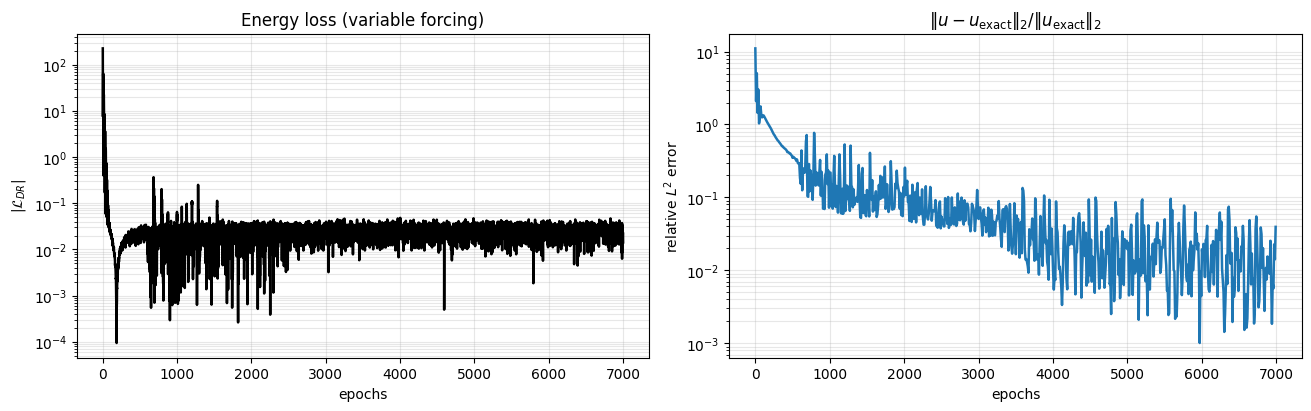

In [28]:
# --- Paper-style losses + relative L2 error (variable forcing) ---
# If you ran the per-iteration diagnostics cell, this will plot both |loss| and relative L2.
# Otherwise it will plot only |loss| from `losses_sin`.

if 'losses_signed_sin' in globals():
    loss_sin_arr = np.asarray(losses_signed_sin, dtype=float)
elif 'losses_sin' in globals():
    loss_sin_arr = np.asarray(losses_sin, dtype=float)
else:
    raise RuntimeError('No losses found. Run the variable-forcing training cell first.')

abs_loss_sin = np.abs(loss_sin_arr)
epochs_sin = np.arange(1, abs_loss_sin.size + 1)

has_rel = ('rel_l2_sin' in globals()) and ('iters_sin' in globals())

if has_rel:
    fig_sin_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
else:
    fig_sin_loss, ax1 = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)

# Absolute energy loss
ax1.plot(epochs_sin, abs_loss_sin, color='k', linewidth=1.8)
ax1.set_xlabel('epochs')
ax1.set_ylabel(r'$|\mathcal{L}_{DR}|$')
ax1.set_yscale('log')
ax1.set_title('Energy loss (variable forcing)')
ax1.grid(True, which='both', alpha=0.3)

if has_rel:
    ax2.plot(iters_sin, rel_l2_sin, color='C0', linewidth=1.8)
    ax2.set_xlabel('epochs')
    ax2.set_ylabel(r'relative $L^2$ error')
    ax2.set_yscale('log')
    ax2.set_title(r'$\|u-u_{\mathrm{exact}}\|_2 / \|u_{\mathrm{exact}}\|_2$')
    ax2.grid(True, which='both', alpha=0.3)

plt.show()

In [29]:
# --- Save paper-ready variable-forcing loss figure (added cell) ---
import os

if 'fig_sin_loss' not in globals():
    raise RuntimeError('Run the variable-forcing loss plotting cell first so `fig_sin_loss` exists.')

out_name_var_loss = 'pde1d_varforcing_losses.pdf'
fig_sin_loss.savefig(out_name_var_loss, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_var_loss))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_varforcing_losses.pdf


bc_err: 0.00032887267422900283
L2 error (grid): 0.000351257737945892
Residual RMS (full): 0.02970381136440819   Residual max (full): 0.12103485580034978
Residual RMS (interior |x-0|>0.02): 0.023641379506003327   Residual max (interior): 0.09728412007194576


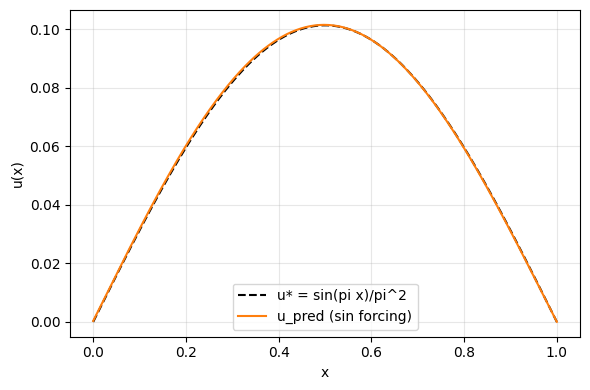

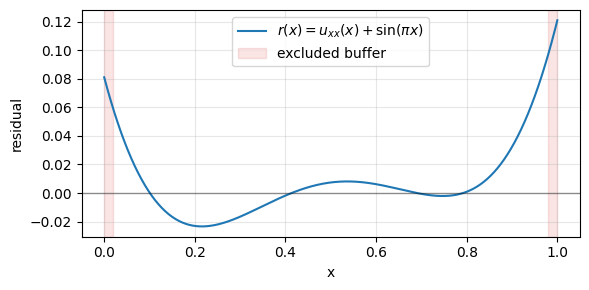

In [30]:
# Variable forcing (PLOT + METRICS CELL)
# This cell assumes `model_sin` is trained in the previous cell.


x_grid = np.linspace(0.0, 1.0, 401)
x_in = np.clip(x_grid, 1e-6, 1.0 - 1e-6)
batch = x_in.shape[0]


n_modes = model_sin.layers[0].input_size
X0 = np.zeros((n_modes, batch), dtype=np.complex128)
X0[0, :] = x_in
if n_modes > 1:
    X0[1:, :] = 1.0
dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
d2X0 = np.zeros_like(X0)


XL, dXL, d2XL = forward_pass_derivatives(model_sin, X0, dX0, d2X0)
u_pred, u_x_pred, u_xx_pred, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)


u_true = u_true_sinpi(x_grid)
l2 = float(np.sqrt(np.mean((u_pred - u_true)**2)))
bc_err = float(max(abs(u_pred[0]), abs(u_pred[-1])))


# Strong-form residual r=u_xx+sin(pi x) (note: uses x_in for derivatives)
r = u_xx_pred + f_sinpi(x_in)
r_rms = float(np.sqrt(np.mean(r**2)))
r_max = float(np.max(np.abs(r)))


# Interior-only residual metrics (exclude a small buffer)
buffer = 0.02
mask_int = (x_grid >= buffer) & (x_grid <= 1.0 - buffer)
r_rms_int = float(np.sqrt(np.mean(r[mask_int]**2)))
r_max_int = float(np.max(np.abs(r[mask_int])))


print('bc_err:', bc_err)
print('L2 error (grid):', l2)
print('Residual RMS (full):', r_rms, '  Residual max (full):', r_max)
print(f'Residual RMS (interior |x-0|>{buffer}):', r_rms_int, '  Residual max (interior):', r_max_int)


plt.figure(figsize=(6,4))
plt.plot(x_grid, u_true, 'k--', label='u* = sin(pi x)/pi^2')
plt.plot(x_grid, u_pred, 'C1', label='u_pred (sin forcing)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()


plt.figure(figsize=(6,3))
plt.plot(x_in, r, lw=1.5, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
plt.axhline(0.0, color='k', lw=1, alpha=0.4)
plt.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
plt.axvspan(1.0-buffer, 1.0, color='C3', alpha=0.12)
plt.xlabel('x'); plt.ylabel('residual')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout(); plt.show()

## B3: Mixed BC, constant forcing $f(x)=1$

We solve on $x\in(0,1)$
$$-u''(x)=1,\qquad u(0)=0,\qquad u'(1)=g.$$

**Deep Ritz functional**

$$\mathcal{L}_{DR}(u)=\mathbb{E}\left[\tfrac12 u^2_x(x) - u(x)\right] - g\,u(1) + \frac{\lambda_0}{2}u(0)^2,$$
where the last term enforces $u(0)=0$ softly (Dirichlet penalty at $x=0$ only).

**Key point**

The stationarity condition yields the interior coefficient $-(u_{xx}+1)$ and the boundary coefficient $(u_x(1)-g)$.

**Adjoint source term**

We build $\partial \mathcal{L}_{DR}/\partial \mathbf{X}_L^*(x_i)$ and inject it at the output. With the readout $u(x)=\Re\{\mathbf{a}^\dagger \mathbf{X}_L(x)\}+b$, we have $\partial u/\partial \mathbf{X}_L^*=\tfrac12\mathbf{a}$.
- Interior samples: $-(u_{xx}(x_i)+1)\,\tfrac12\mathbf{a}$.
- Neumann sample at $x=1$: $$\big(u_x(1)-g\big)\,\frac{\partial u(1)}{\partial \mathbf{X}_L^*}=\frac{u_x(1)-g}{2}\,\mathbf{a}.$$

In [31]:
# Mixed BC (Dirichlet@0, Neumann@1): build δ_L = ∂L_DR/∂X_L* and train with TRIM/Adam.

def build_dloss_star_fx_neumann1(
    x: np.ndarray,
    XL: np.ndarray,
    dXL: np.ndarray,
    d2XL: np.ndarray,
    f_fn,
    g_neumann: float,
    a: np.ndarray | None = None,
    b: float = 0.0,
    is_dirichlet: np.ndarray | None = None,
    is_neumann: np.ndarray | None = None,
    lambda_dirichlet: float = 0.0,
 ):
    """
    Returns (loss_total, d_loss_star) where d_loss_star = ∂L_DR/∂X_L* (Wirtinger).

    This implements the first-variation form of the Deep Ritz functional for mixed BCs:
      - Interior coefficient:  -(u_xx + f)
      - Neumann boundary coefficient at x=1: (u_x - g)
      - Dirichlet at x=0 is enforced softly via 0.5*lambda*mean(u^2).

    Clarity note:
      - The Deep Ritz functional contains the boundary loading term -g*u(1), but it does NOT contain +u_x(1).
        The +u_x(1) contribution appears in the FIRST VARIATION after integrating by parts the quadratic term 0.5*∫ u_x^2.
      - loss_total is only used for monitoring; TRIM uses d_loss_star for backprop/updates.
    """
    batch_total = x.shape[0]
    if is_dirichlet is None:
        is_dirichlet = np.zeros((batch_total,), dtype=bool)
    else:
        is_dirichlet = np.asarray(is_dirichlet, dtype=bool)
        if is_dirichlet.shape != (batch_total,):
            raise ValueError(f"is_dirichlet must have shape (batch,), got {is_dirichlet.shape}")
    if is_neumann is None:
        is_neumann = np.zeros((batch_total,), dtype=bool)
    else:
        is_neumann = np.asarray(is_neumann, dtype=bool)
        if is_neumann.shape != (batch_total,):
            raise ValueError(f"is_neumann must have shape (batch,), got {is_neumann.shape}")
    if np.any(is_dirichlet & is_neumann):
        raise ValueError("A sample cannot be both Dirichlet and Neumann.")
    
    u, du, d2u, du_dXL_star = linear_readout(x, XL, dXL, d2XL, a=a, b=b)
    idx_int = np.where(~(is_dirichlet | is_neumann))[0]
    idx_dir = np.where(is_dirichlet)[0]
    idx_neu = np.where(is_neumann)[0]
    if idx_int.size == 0:
        raise ValueError("Need at least 1 interior point.")

    # ---- interior ----
    u_int = u[idx_int]
    du_int = du[idx_int]
    d2u_int = d2u[idx_int]
    du_star_int = du_dXL_star[:, idx_int]
    x_int = x[idx_int]
    f_int = np.asarray(f_fn(x_int), dtype=np.float64).reshape(-1)
    if f_int.shape != (idx_int.size,):
        raise ValueError("f_fn(x) must return shape (n_int,)")
    g_int = 0.5 * (np.abs(du_int) ** 2) - f_int * u_int
    loss_interior = float(np.mean(g_int))
    n_int = idx_int.size
    coeff_int = (-(d2u_int + f_int) / n_int).astype(np.float64)
    d_loss_star_int = (du_star_int * coeff_int[None, :]).astype(np.complex128)

    # ---- Neumann boundary term at x=1 ----
    # δ_L(1) = (u_x(1) - g) * ∂u(1)/∂X_L*
    loss_neumann = 0.0
    d_loss_star_neu = np.zeros((XL.shape[0], 0), dtype=np.complex128)
    if idx_neu.size > 0:
        u_neu = u[idx_neu]
        du_neu = du[idx_neu]
        du_star_neu = du_dXL_star[:, idx_neu]
        n_neu = idx_neu.size
        # This is the explicit boundary loading term -g*u(1) in L_DR (monitoring only).
        loss_neumann = float((-g_neumann) * np.mean(u_neu))
        coeff_neu = ((du_neu - g_neumann) / n_neu).astype(np.float64)
        d_loss_star_neu = (du_star_neu * coeff_neu[None, :]).astype(np.complex128)

    # ---- Dirichlet penalty at x=0 ----
    loss_dirichlet = 0.0
    d_loss_star_dir = np.zeros((XL.shape[0], 0), dtype=np.complex128)
    if lambda_dirichlet > 0.0:
        if idx_dir.size == 0:
            raise ValueError("lambda_dirichlet > 0 but no Dirichlet points were provided.")
        u_dir = u[idx_dir]
        du_star_dir = du_dXL_star[:, idx_dir]
        n_dir = idx_dir.size
        loss_dirichlet = float(lambda_dirichlet * 0.5 * np.mean(u_dir ** 2))
        coeff_dir = (lambda_dirichlet / n_dir) * u_dir
        d_loss_star_dir = (du_star_dir * coeff_dir[None, :]).astype(np.complex128)

    # ---- merge into full batch order ----
    d_loss_star = np.zeros_like(XL, dtype=np.complex128)
    d_loss_star[:, idx_int] = d_loss_star_int
    if idx_neu.size > 0:
        d_loss_star[:, idx_neu] = d_loss_star_neu
    if idx_dir.size > 0 and lambda_dirichlet > 0.0:
        d_loss_star[:, idx_dir] = d_loss_star_dir

    loss_total = loss_interior + loss_neumann + loss_dirichlet
    return loss_total, d_loss_star

def fit_unsupervised_insitu_adam_fx_neumann1(
    model: neu.Sequential,
    f_fn,
    g_neumann: float,
    epochs: int = 2000,
    batch_size: int = 64,
    step_size: float = 0.005,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    seed: int = 0,
    cache_fields: bool = False,
    use_partial_vectors: bool = False,
    a: np.ndarray | None = None,
    b: float = 0.0,
    lambda_dirichlet: float = 200.0,
 ):
    """
    Trains with interior sampling + boundary samples: x=0 (Dirichlet penalty) and x=1 (Neumann injection).
    """
    rng = np.random.default_rng(seed)
    m = {}
    v = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)
    losses = []
    n_modes = model.layers[0].input_size

    for epoch in range(epochs):
        t += 1
        x_int = rng.random(batch_size)
        x_int = np.clip(x_int, 1e-6, 1.0 - 1e-6)

        # boundary samples (Dirichlet at 0, Neumann at 1)
        x_dir = np.array([0.0], dtype=np.float64)
        x_neu = np.array([1.0], dtype=np.float64)
        x = np.concatenate([x_int, x_dir, x_neu], axis=0)
        is_dir = np.zeros((x.shape[0],), dtype=bool)
        is_neu = np.zeros((x.shape[0],), dtype=bool)
        is_dir[-2] = True
        is_neu[-1] = True

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)

        loss, d_loss_star = build_dloss_star_fx_neumann1(
            x, XL, dXL, d2XL,
            f_fn=f_fn,
            g_neumann=g_neumann,
            a=a, b=b,
            is_dirichlet=is_dir,
            is_neumann=is_neu,
            lambda_dirichlet=lambda_dirichlet,
        )
        losses.append(loss)

        deltas = model.backward_pass(d_loss_star, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        delta_prev = d_loss_star
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev,
                    delta_prev,
                    cache_fields=cache_fields,
                    use_partial_vectors=use_partial_vectors,
                )
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = beta1 * m[cmpt] + (1 - beta1) * g
                    v[cmpt] = beta2 * v[cmpt] + (1 - beta2) * (g ** 2)
                    mhat = m[cmpt] / (1 - beta1 ** t)
                    vhat = v[cmpt] / (1 - beta2 ** t)
                    step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch + 1) % 200 == 0:
            print(f"epoch {epoch+1}/{epochs}  loss={loss:.6e}")
    return losses

In [32]:
# Mixed BC benchmark (TRAINING CELL): -u''=1, u(0)=0, u'(1)=g.

def f_const1(x):
    x = np.asarray(x)
    return np.ones_like(x, dtype=np.float64)

def u_true_const1_mixed(x, g: float):
    # Solve -u''=1, u(0)=0, u'(1)=g => u(x)=-(1/2)x^2 + (g+1)x
    x = np.asarray(x, dtype=np.float64)
    return -0.5 * x**2 + (g + 1.0) * x

init_seed = 0
train_seed = 1
g_neu = 0.0   # change this to test non-zero Neumann flux

# Canonical hyperparameters for this benchmark (used by all downstream paper/diagnostics cells)
epochs_neu = 7000
batch_size_neu = 64
step_size_neu = 0.005
lambda_dirichlet_neu = 200.0
N_neu = 3

if "build_photonic_model" not in globals():
    def build_photonic_model(N: int = 3, seed: int = 0) -> neu.Sequential:
        np.random.seed(seed)
        return neu.Sequential([
            neu.ClementsLayer(N),
            neu.Activation(ComplexSquared(N)),
            neu.ClementsLayer(N),
            neu.Activation(ComplexSquared(N)),
        ])

model_neu = build_photonic_model(N=int(N_neu), seed=int(init_seed))
losses_neu = fit_unsupervised_insitu_adam_fx_neumann1(
    model_neu,
    f_fn=f_const1,
    g_neumann=g_neu,
    epochs=int(epochs_neu),
    batch_size=int(batch_size_neu),
    step_size=float(step_size_neu),
    seed=int(train_seed),
    lambda_dirichlet=float(lambda_dirichlet_neu),
 )
print('final loss (mixed BC):', losses_neu[-1])

epoch 200/7000  loss=4.171992e-02
epoch 400/7000  loss=-1.455857e-02
epoch 600/7000  loss=-7.721442e-02
epoch 800/7000  loss=-1.656496e-01
epoch 1000/7000  loss=-1.648331e-01
epoch 1200/7000  loss=-1.293759e-01
epoch 1400/7000  loss=-1.332569e-01
epoch 1600/7000  loss=-2.001132e-01
epoch 1800/7000  loss=-1.078311e-01
epoch 2000/7000  loss=-1.834634e-01
epoch 2200/7000  loss=-1.447121e-01
epoch 2400/7000  loss=-1.697179e-01
epoch 2600/7000  loss=-1.858222e-01
epoch 2800/7000  loss=-1.620699e-01
epoch 3000/7000  loss=-2.054373e-01
epoch 3200/7000  loss=-1.599449e-01
epoch 3400/7000  loss=-1.641549e-01
epoch 3600/7000  loss=-1.496251e-01
epoch 3800/7000  loss=-2.438366e-01
epoch 4000/7000  loss=-1.464079e-01
epoch 4200/7000  loss=-2.689915e-01
epoch 4400/7000  loss=-1.550090e-01
epoch 4600/7000  loss=-2.285400e-01
epoch 4800/7000  loss=-1.300978e-01
epoch 5000/7000  loss=-1.582639e-01
epoch 5200/7000  loss=-1.457078e-01
epoch 5400/7000  loss=-1.628128e-01
epoch 5600/7000  loss=-1.647324e-

In [33]:
# --- Circuit info only (mixed BC): architecture, modes, encoding ---
import numpy as np

print('=== CIRCUIT / MODEL INFO (mixed BC) ===')
if 'model_neu' not in globals():
    raise RuntimeError('No `model_neu` found in globals(). Run the mixed-BC training cell first.')

layers = list(getattr(model_neu, 'layers', []))
print('Model type:', type(model_neu))
print('Number of layers:', len(layers))

# Number of modes/ports
if len(layers) > 0 and hasattr(layers[0], 'input_size'):
    n_modes = int(layers[0].input_size)
else:
    n_modes = None
print('Number of modes (N):', n_modes)

print('\nLayers:')
for i, layer in enumerate(layers):
    layer_name = layer.__class__.__name__
    desc = [f'[{i}] {layer_name}']
    if hasattr(layer, 'input_size'):
        desc.append(f"in={getattr(layer, 'input_size')}")
    if hasattr(layer, 'output_size'):
        desc.append(f"out={getattr(layer, 'output_size')}")
    if hasattr(layer, 'mesh'):
        mesh = getattr(layer, 'mesh')
        desc.append(f"mesh={mesh.__class__.__name__}")
        if hasattr(mesh, 'all_tunable_components'):
            cmpts = list(mesh.all_tunable_components())
            dof_total = int(sum(int(getattr(c, 'dof', 0)) for c in cmpts))
            desc.append(f"tunable_components={len(cmpts)}")
            desc.append(f"total_dof={dof_total}")
    print('  ' + '  |  '.join(desc))

print('\n=== RUN PARAMETERS (from current globals) ===')
def _maybe(name):
    return globals()[name] if name in globals() else None

print('Mixed BC params:')
print('  init_seed =', _maybe('init_seed'))
print('  train_seed =', _maybe('train_seed'))
print('  g_neu =', _maybe('g_neu'))
print('  epochs (len(losses_neu)) =', len(losses_neu) if 'losses_neu' in globals() else None)

print('\n=== INPUT ENCODING (as implemented) ===')
print('Using n_modes =', n_modes)
print('X0 construction:')
print('  X0 = zeros((n_modes, batch), complex128)')
print('  X0[0, :] = x')
if n_modes is None:
    print('  X0[1:, :] = 1.0   (cannot confirm n_modes>1 because n_modes is None)')
elif n_modes > 1:
    print('  X0[1:, :] = 1.0')
else:
    print('  (n_modes==1) => no X0[1:, :] rows exist')

print('dX0 construction:')
print('  dX0 = zeros_like(X0)')
print('  dX0[0, :] = 1.0')
print('d2X0 construction:')
print('  d2X0 = zeros_like(X0)')

=== CIRCUIT / MODEL INFO (mixed BC) ===
Model type: <class 'neuroptica.models.Sequential'>
Number of layers: 4
Number of modes (N): 3

Layers:
  [0] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [1] Activation  |  in=3  |  out=3
  [2] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [3] Activation  |  in=3  |  out=3

=== RUN PARAMETERS (from current globals) ===
Mixed BC params:
  init_seed = 0
  train_seed = 1
  g_neu = 0.0
  epochs (len(losses_neu)) = 7000

=== INPUT ENCODING (as implemented) ===
Using n_modes = 3
X0 construction:
  X0 = zeros((n_modes, batch), complex128)
  X0[0, :] = x
  X0[1:, :] = 1.0
dX0 construction:
  dX0 = zeros_like(X0)
  dX0[0, :] = 1.0
d2X0 construction:
  d2X0 = zeros_like(X0)


epoch 200/3500  loss=4.171992e-02
epoch 400/3500  loss=-1.455857e-02
epoch 600/3500  loss=-7.721442e-02
epoch 800/3500  loss=-1.656496e-01
epoch 1000/3500  loss=-1.648331e-01
epoch 1200/3500  loss=-1.293759e-01
epoch 1400/3500  loss=-1.332569e-01
epoch 1600/3500  loss=-2.001132e-01
epoch 1800/3500  loss=-1.078311e-01
epoch 2000/3500  loss=-1.834634e-01
epoch 2200/3500  loss=-1.447121e-01
epoch 2400/3500  loss=-1.697179e-01
epoch 2600/3500  loss=-1.858222e-01
epoch 2800/3500  loss=-1.620699e-01
epoch 3000/3500  loss=-2.054373e-01
epoch 3200/3500  loss=-1.599449e-01
epoch 3400/3500  loss=-1.641549e-01
Mixed BC snapshot iterations: {'first': 1, 'mid': 3500, 'final': 7000}
Final loss (mixed BC): -0.15402485665590993


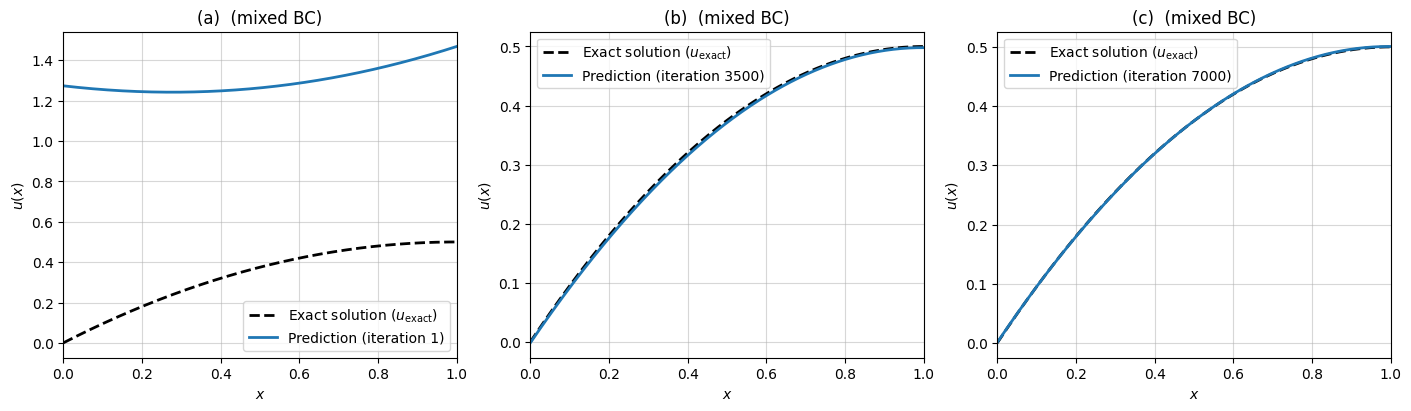

In [34]:
# --- Paper-style figure (mixed BC): predictions at 1 / mid / final (solutions only) ---
if 'f_const1' not in globals() or 'u_true_const1_mixed' not in globals():
    raise RuntimeError('Run the mixed-BC training cell first (defines f_const1/u_true_const1_mixed).')
if 'build_photonic_model' not in globals():
    raise RuntimeError('Expected build_photonic_model to exist (defined earlier in the notebook).')
if 'fit_unsupervised_insitu_adam_fx_neumann1' not in globals():
    raise RuntimeError('Expected fit_unsupervised_insitu_adam_fx_neumann1 to exist (defined in the mixed-BC section).')

def _style_axes_paper(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

# Pull hyperparams from the training cell (authoritative)
required = ['init_seed', 'train_seed', 'g_neu', 'N_neu', 'epochs_neu', 'batch_size_neu', 'step_size_neu', 'lambda_dirichlet_neu', 'losses_neu']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for mixed BC (f=1): ' + ', '.join(missing) + '. Run the training cell first.')
init_seed_neu = int(init_seed)
train_seed_neu = int(train_seed)
g_neu_val = float(g_neu)
N_neu_val = int(N_neu)
batch_size_neu = int(batch_size_neu)
step_size_neu = float(step_size_neu)
lambda_dirichlet_neu = float(lambda_dirichlet_neu)

epochs_final_neu = len(losses_neu)
epoch_first_neu = 0
epoch_mid_neu = max(0, (epochs_final_neu // 2) - 1)
epoch_final_neu = epochs_final_neu - 1

x_plot_neu = np.linspace(0.0, 1.0, 401)
x_plot_in_neu = np.clip(x_plot_neu, 1e-6, 1.0 - 1e-6)
u_exact_neu = u_true_const1_mixed(x_plot_neu, g=float(g_neu_val))

def _eval_u_on_grid_neu(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def _train_model_neu_for_epochs(epochs: int):
    model_tmp = build_photonic_model(N=int(N_neu_val), seed=int(init_seed_neu))
    losses_tmp = fit_unsupervised_insitu_adam_fx_neumann1(
        model_tmp,
        f_fn=f_const1,
        g_neumann=float(g_neu_val),
        epochs=int(epochs),
        batch_size=int(batch_size_neu),
        step_size=float(step_size_neu),
        seed=int(train_seed_neu),
        lambda_dirichlet=float(lambda_dirichlet_neu),
    )
    return model_tmp, losses_tmp

# Reuse existing trained model as final snapshot when possible
if 'model_neu' in globals() and 'losses_neu' in globals() and isinstance(losses_neu, list) and len(losses_neu) >= (epoch_final_neu + 1):
    model_final_neu = model_neu
    losses_final_neu = losses_neu
else:
    model_final_neu, losses_final_neu = _train_model_neu_for_epochs(epoch_final_neu + 1)

# Retrain deterministically for first/mid snapshots
model_first_neu, _ = _train_model_neu_for_epochs(epoch_first_neu + 1)
model_mid_neu, _ = _train_model_neu_for_epochs(epoch_mid_neu + 1)

u_pred_first_neu = _eval_u_on_grid_neu(model_first_neu, x_plot_in_neu)
u_pred_mid_neu = _eval_u_on_grid_neu(model_mid_neu, x_plot_in_neu)
u_pred_final_neu = _eval_u_on_grid_neu(model_final_neu, x_plot_in_neu)

print('Mixed BC snapshot iterations:', {'first': epoch_first_neu + 1, 'mid': epoch_mid_neu + 1, 'final': epoch_final_neu + 1})
print('Final loss (mixed BC):', float(losses_final_neu[-1]) if isinstance(losses_final_neu, list) and len(losses_final_neu) else None)

fig_neu_sol, (ax_first, ax_mid, ax_final) = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

def _plot_panel(ax, u_pred, it_number, title):
    ax.plot(x_plot_neu, u_exact_neu, 'k--', linewidth=2.0, label=r'Exact solution ($u_{\mathrm{exact}}$)')
    ax.plot(x_plot_neu, u_pred, color='C0', linewidth=2.0, label=f'Prediction (iteration {it_number})')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$u(x)$')
    ax.set_title(title + r'  (mixed BC)')
    _style_axes_paper(ax)
    ax.legend(frameon=True)

_plot_panel(ax_first, u_pred_first_neu, epoch_first_neu + 1, '(a)')
_plot_panel(ax_mid, u_pred_mid_neu, epoch_mid_neu + 1, '(b)')
_plot_panel(ax_final, u_pred_final_neu, epoch_final_neu + 1, '(c)')

plt.show()

In [35]:
# --- Save paper-ready mixed-BC solutions figure (added cell) ---
import os

if 'fig_neu_sol' not in globals():
    raise RuntimeError('Run the mixed-BC solutions plotting cell first so `fig_neu_sol` exists.')

out_name_mixed_sol = 'pde1d_mixedBC_solutions.pdf'
fig_neu_sol.savefig(out_name_mixed_sol, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sol))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_solutions.pdf


Neumann check (at x=1-eps): u_x(1-)≈ -0.0062235420827652784  target g= 0.0  |error|= 0.0062235420827652784


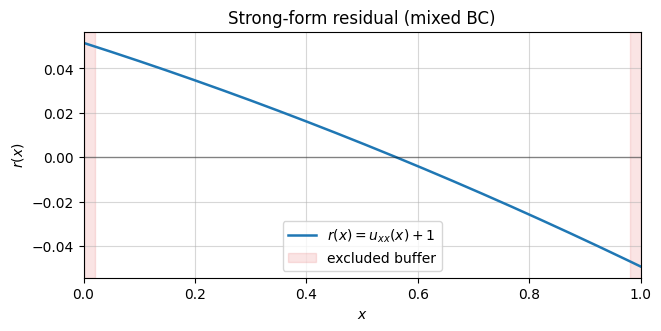

In [36]:
# --- Paper-style figure (mixed BC): strong-form residual + Neumann check ---
if 'model_neu' not in globals():
    raise RuntimeError('Run the mixed-BC training cell first so `model_neu` exists.')

# Styling helper (self-contained)
def _style_axes_paper(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

g_neu_val = g_neu if 'g_neu' in globals() else 0.0

x_grid_res = np.linspace(0.0, 1.0, 401)
x_in_res = np.clip(x_grid_res, 1e-6, 1.0 - 1e-6)
batch_res = x_in_res.shape[0]
n_modes_res = model_neu.layers[0].input_size
X0_res = np.zeros((n_modes_res, batch_res), dtype=np.complex128)
X0_res[0, :] = x_in_res
if n_modes_res > 1:
    X0_res[1:, :] = 1.0
dX0_res = np.zeros_like(X0_res)
dX0_res[0, :] = 1.0
d2X0_res = np.zeros_like(X0_res)

XL_res, dXL_res, d2XL_res = forward_pass_derivatives(model_neu, X0_res, dX0_res, d2X0_res)
_, u_x_res, u_xx_res, _ = linear_readout(x_in_res, XL_res, dXL_res, d2XL_res, a=None, b=0.0)

r_neu = np.real(u_xx_res) + 1.0
ux_1m = float(np.real(u_x_res[-1]))
neu_err = float(abs(ux_1m - float(g_neu_val)))
print('Neumann check (at x=1-eps): u_x(1-)≈', ux_1m, ' target g=', float(g_neu_val), ' |error|=', neu_err)

buffer = 0.02
fig_neu_res, ax = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x_in_res, r_neu, linewidth=1.8, label=r'$r(x)=u_{xx}(x)+1$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
ax.axvspan(1.0 - buffer, 1.0, color='C3', alpha=0.12)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$r(x)$')
ax.set_title('Strong-form residual (mixed BC)')
_style_axes_paper(ax)
ax.legend(frameon=True, loc='best')
plt.show()

In [37]:
# --- Save paper-ready mixed-BC residual figure (added cell) ---
import os

if 'fig_neu_res' not in globals():
    raise RuntimeError('Run the mixed-BC residual plotting cell first so `fig_neu_res` exists.')

out_name_mixed_res = 'pde1d_mixedBC_residual.pdf'
fig_neu_res.savefig(out_name_mixed_res, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_res))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_residual.pdf


In [38]:
# --- Extra diagnostics (mixed BC): relative L2 error per iteration (added cell) ---
# NOTE: This retrains from scratch (same init/seed) to get the full per-iteration curve.
# It can take a while because it evaluates u(x) during training.

n_eval_neu = 101
compute_every_neu = 10  # set to 1 for every iteration
required = ['init_seed', 'train_seed', 'g_neu', 'N_neu', 'epochs_neu', 'batch_size_neu', 'step_size_neu', 'lambda_dirichlet_neu', 'losses_neu']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for mixed BC (f=1) diagnostics: ' + ', '.join(missing) + '. Run the training cell first.')
epochs_neu_err = len(losses_neu)
init_seed_neu = int(init_seed)
train_seed_neu = int(train_seed)
g_neu_val = float(g_neu)
N_neu_val = int(N_neu)
batch_size_neu = int(batch_size_neu)
step_size_neu = float(step_size_neu)
lambda_dirichlet_neu = float(lambda_dirichlet_neu)

x_err_neu = np.linspace(0.0, 1.0, n_eval_neu)
x_err_in_neu = np.clip(x_err_neu, 1e-6, 1.0 - 1e-6)
u_exact_err_neu = u_true_const1_mixed(x_err_neu, g=float(g_neu_val))
den_neu = float(np.sqrt(np.mean(u_exact_err_neu**2)))
den_neu = den_neu if den_neu > 0 else 1.0

def _eval_u_real_neu(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def train_neu_with_l2_curve():
    rng = np.random.default_rng(train_seed_neu)
    np.random.seed(init_seed_neu)
    model_err_neu = build_photonic_model(N=int(N_neu_val), seed=int(init_seed_neu))

    m = {}
    v = {}
    t = 0
    for layer in model_err_neu.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses_signed_neu = []
    iters_neu = []
    rel_l2_neu = []

    n_modes = model_err_neu.layers[0].input_size

    for epoch in range(int(epochs_neu_err)):
        t += 1
        x_int = rng.random(int(batch_size_neu))
        x_int = np.clip(x_int, 1e-6, 1.0 - 1e-6)

        # boundary samples (Dirichlet at 0, Neumann at 1)
        x_dir = np.array([0.0], dtype=np.float64)
        x_neu = np.array([1.0], dtype=np.float64)
        x = np.concatenate([x_int, x_dir, x_neu], axis=0)
        is_dir = np.zeros((x.shape[0],), dtype=bool)
        is_neu = np.zeros((x.shape[0],), dtype=bool)
        is_dir[-2] = True
        is_neu[-1] = True

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model_err_neu.forward_pass(X0)
        XL, dXL, d2XL = forward_pass_derivatives(model_err_neu, X0, dX0, d2X0)
        loss, d_loss_star = build_dloss_star_fx_neumann1(
            x, XL, dXL, d2XL,
            f_fn=f_const1,
            g_neumann=float(g_neu_val),
            a=None, b=0.0,
            is_dirichlet=is_dir,
            is_neumann=is_neu,
            lambda_dirichlet=float(lambda_dirichlet_neu),
        )
        losses_signed_neu.append(float(loss))

        deltas = model_err_neu.backward_pass(d_loss_star)
        delta_prev = d_loss_star
        for layer in reversed(model_err_neu.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(layer.input_prev, delta_prev)
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = 0.9 * m[cmpt] + (1 - 0.9) * g
                    v[cmpt] = 0.99 * v[cmpt] + (1 - 0.99) * (g ** 2)
                    mhat = m[cmpt] / (1 - 0.9 ** t)
                    vhat = v[cmpt] / (1 - 0.99 ** t)
                    step = -float(step_size_neu) * mhat / (np.sqrt(vhat) + 1e-8)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch % int(compute_every_neu)) == 0:
            u_pred_err = _eval_u_real_neu(model_err_neu, x_err_in_neu)
            num = float(np.sqrt(np.mean((u_pred_err - u_exact_err_neu) ** 2)))
            iters_neu.append(epoch + 1)
            rel_l2_neu.append(num / den_neu)

        if (epoch + 1) % 500 == 0:
            print(f"iter {epoch+1}/{int(epochs_neu_err)}  loss={loss:+.3e}  relL2(last)={rel_l2_neu[-1]:.3e}")

    return model_err_neu, losses_signed_neu, np.array(iters_neu), np.array(rel_l2_neu)

model_err_neu, losses_signed_neu, iters_neu, rel_l2_neu = train_neu_with_l2_curve()
print('Done. Final signed loss:', losses_signed_neu[-1], ' Final rel L2:', rel_l2_neu[-1])

iter 500/7000  loss=-4.797e-02  relL2(last)=7.492e-01
iter 1000/7000  loss=-1.648e-01  relL2(last)=6.888e-02
iter 1500/7000  loss=-1.693e-01  relL2(last)=3.996e-02
iter 2000/7000  loss=-1.835e-01  relL2(last)=2.960e-02
iter 2500/7000  loss=-1.670e-01  relL2(last)=9.326e-03
iter 3000/7000  loss=-2.054e-01  relL2(last)=2.423e-02
iter 3500/7000  loss=-1.142e-01  relL2(last)=2.845e-03
iter 4000/7000  loss=-1.464e-01  relL2(last)=6.337e-03
iter 4500/7000  loss=-1.669e-01  relL2(last)=7.315e-03
iter 5000/7000  loss=-1.583e-01  relL2(last)=4.646e-03
iter 5500/7000  loss=-1.752e-01  relL2(last)=3.331e-03
iter 6000/7000  loss=-1.239e-01  relL2(last)=8.385e-03
iter 6500/7000  loss=-1.671e-01  relL2(last)=4.201e-03
iter 7000/7000  loss=-1.540e-01  relL2(last)=8.493e-03
Done. Final signed loss: -0.15402485665590993  Final rel L2: 0.008493056018560947


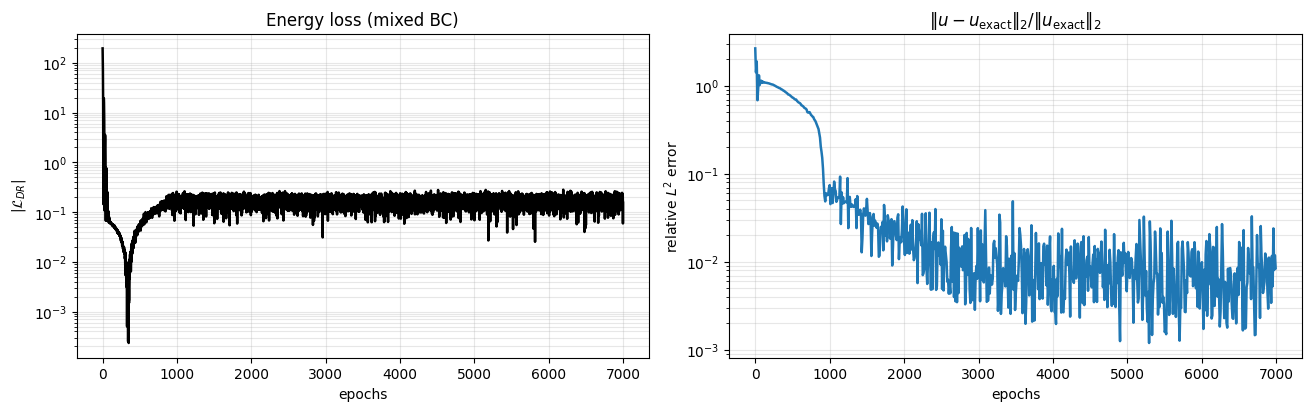

In [39]:
# --- Paper-style losses + relative L2 error (mixed BC) ---
# If you ran the per-iteration diagnostics cell, this will plot both |loss| and relative L2.
# Otherwise it will plot only |loss| from `losses_neu`.

if 'losses_signed_neu' in globals():
    loss_neu_arr = np.asarray(losses_signed_neu, dtype=float)
elif 'losses_neu' in globals():
    loss_neu_arr = np.asarray(losses_neu, dtype=float)
else:
    raise RuntimeError('No losses found. Run the mixed-BC training cell first.')

abs_loss_neu = np.abs(loss_neu_arr)
epochs_neu = np.arange(1, abs_loss_neu.size + 1)

has_rel_neu = ('rel_l2_neu' in globals()) and ('iters_neu' in globals())

if has_rel_neu:
    fig_neu_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
else:
    fig_neu_loss, ax1 = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)

# Absolute energy loss
ax1.plot(epochs_neu, abs_loss_neu, color='k', linewidth=1.8)
ax1.set_xlabel('epochs')
ax1.set_ylabel(r'$|\mathcal{L}_{DR}|$')
ax1.set_yscale('log')
ax1.set_title('Energy loss (mixed BC)')
ax1.grid(True, which='both', alpha=0.3)

if has_rel_neu:
    ax2.plot(iters_neu, rel_l2_neu, color='C0', linewidth=1.8)
    ax2.set_xlabel('epochs')
    ax2.set_ylabel(r'relative $L^2$ error')
    ax2.set_yscale('log')
    ax2.set_title(r'$\|u-u_{\mathrm{exact}}\|_2 / \|u_{\mathrm{exact}}\|_2$')
    ax2.grid(True, which='both', alpha=0.3)

plt.show()

In [40]:
# --- Save paper-ready mixed-BC losses figure (added cell) ---
import os

if 'fig_neu_loss' not in globals():
    raise RuntimeError('Run the mixed-BC losses plotting cell first so `fig_neu_loss` exists.')

out_name_mixed_loss = 'pde1d_mixedBC_losses.pdf'
fig_neu_loss.savefig(out_name_mixed_loss, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_loss))

Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_losses.pdf


Dirichlet error |u(0)|: 0.0007954812373637812
Neumann error |u_x(1-)-g|: 0.0062235420827652784   (u_x(1-)≈ -0.0062235420827652784 )
L2 error (grid): 0.0006609706212942914
Residual RMS (full): 0.02951543933516707   max: 0.05147651225142624
Residual RMS (interior |x-0|>0.02): 0.028384989387824033   max: 0.04986315304057265


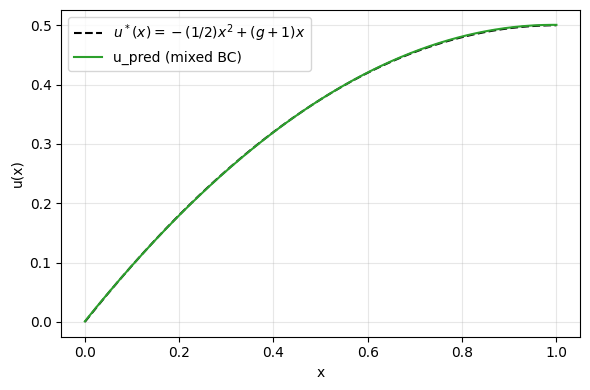

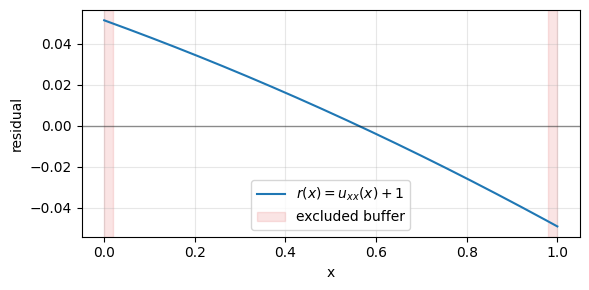

In [41]:
# Mixed BC benchmark (PLOT + METRICS CELL)

x_grid = np.linspace(0.0, 1.0, 401)
x_in = np.clip(x_grid, 1e-6, 1.0 - 1e-6)
batch = x_in.shape[0]

n_modes = model_neu.layers[0].input_size
X0 = np.zeros((n_modes, batch), dtype=np.complex128)
X0[0, :] = x_in
if n_modes > 1:
    X0[1:, :] = 1.0
dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
d2X0 = np.zeros_like(X0)

XL, dXL, d2XL = forward_pass_derivatives(model_neu, X0, dX0, d2X0)
u_pred, u_x_pred, u_xx_pred, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)

u_true = u_true_const1_mixed(x_grid, g=g_neu)
l2 = float(np.sqrt(np.mean((u_pred - u_true) ** 2)))
bc_dir_err = float(abs(u_pred[0]))

# Neumann check: evaluate u_x near x=1 (from x_in, last point is 1-eps)
ux_1m = float(u_x_pred[-1])
neu_err = float(abs(ux_1m - g_neu))

# Strong-form residual r=u_xx+1 on interior grid (diagnostic only)
r = u_xx_pred + 1.0
r_rms = float(np.sqrt(np.mean(r ** 2)))
r_max = float(np.max(np.abs(r)))

buffer = 0.02
mask_int = (x_grid >= buffer) & (x_grid <= 1.0 - buffer)
r_rms_int = float(np.sqrt(np.mean(r[mask_int] ** 2)))
r_max_int = float(np.max(np.abs(r[mask_int])))

print('Dirichlet error |u(0)|:', bc_dir_err)
print('Neumann error |u_x(1-)-g|:', neu_err, '  (u_x(1-)≈', ux_1m, ')')
print('L2 error (grid):', l2)
print('Residual RMS (full):', r_rms, '  max:', r_max)
print(f'Residual RMS (interior |x-0|>{buffer}):', r_rms_int, '  max:', r_max_int)

plt.figure(figsize=(6,4))
plt.plot(x_grid, u_true, 'k--', label=r'$u^*(x)=-(1/2)x^2+(g+1)x$')
plt.plot(x_grid, u_pred, 'C2', label='u_pred (mixed BC)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,3))
plt.plot(x_in, r, lw=1.5, label=r'$r(x)=u_{xx}(x)+1$')
plt.axhline(0.0, color='k', lw=1, alpha=0.4)
plt.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
plt.axvspan(1.0-buffer, 1.0, color='C3', alpha=0.12)
plt.xlabel('x'); plt.ylabel('residual')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout(); plt.show()

## B4: Mixed BC, sinusoidal forcing $f(x)=\sin(\pi x)$

Goal: show a different qualitative behavior than the quadratic case, while keeping the same mixed BC setup.

We solve
$$-u''(x)=\sin(\pi x),\qquad u(0)=0,\qquad u'(1)=g.$$
A closed-form solution is
$$u_{exact}(x)=\frac{\sin(\pi x)}{\pi^2} + \left(g+\frac{1}{\pi}\right)x.$$

In [42]:
# Mixed BC + sinusoidal forcing (TRAINING CELL)

def f_sinpi_mixed(x):
    return np.sin(np.pi * np.asarray(x))

def u_true_sinpi_mixed(x, g: float):
    x = np.asarray(x, dtype=np.float64)
    return np.sin(np.pi * x) / (np.pi ** 2) + (g + 1.0 / np.pi) * x

init_seed = 0
train_seed = 1
g_neu_sin = 0.0  # change to test non-zero Neumann flux

# Canonical hyperparameters for this benchmark (used by all downstream cells)
epochs_neu_sin = 7500
batch_size_neu_sin = 64
step_size_neu_sin = 0.005
lambda_dirichlet_neu_sin = 50.0
N_neu_sin = 3

model_neu_sin = build_photonic_model(N=int(N_neu_sin), seed=int(init_seed))
losses_neu_sin = fit_unsupervised_insitu_adam_fx_neumann1(
    model_neu_sin,
    f_fn=f_sinpi_mixed,
    g_neumann=g_neu_sin,
    epochs=int(epochs_neu_sin),
    batch_size=int(batch_size_neu_sin),
    step_size=float(step_size_neu_sin),
    seed=train_seed,
    lambda_dirichlet=float(lambda_dirichlet_neu_sin),
 )
print('final loss (mixed BC, sin forcing):', losses_neu_sin[-1])

epoch 200/7500  loss=1.569553e-02
epoch 400/7500  loss=-4.243274e-02
epoch 600/7500  loss=-6.834346e-02
epoch 800/7500  loss=-1.002608e-01
epoch 1000/7500  loss=-6.621798e-02
epoch 1200/7500  loss=-6.466975e-02
epoch 1400/7500  loss=-6.440422e-02
epoch 1600/7500  loss=-8.654243e-02
epoch 1800/7500  loss=-2.913892e-02
epoch 2000/7500  loss=-8.981159e-02
epoch 2200/7500  loss=-6.556533e-02
epoch 2400/7500  loss=-6.168343e-02
epoch 2600/7500  loss=-8.879806e-02
epoch 2800/7500  loss=-7.474643e-02
epoch 3000/7500  loss=-8.580349e-02
epoch 3200/7500  loss=-6.661547e-02
epoch 3400/7500  loss=-7.056309e-02
epoch 3600/7500  loss=-6.048950e-02
epoch 3800/7500  loss=-9.341854e-02
epoch 4000/7500  loss=-7.583648e-02
epoch 4200/7500  loss=-1.084335e-01
epoch 4400/7500  loss=-6.773964e-02
epoch 4600/7500  loss=-1.092708e-01
epoch 4800/7500  loss=-8.807363e-02
epoch 5000/7500  loss=-6.163008e-02
epoch 5200/7500  loss=-6.663451e-02
epoch 5400/7500  loss=-7.686638e-02
epoch 5600/7500  loss=-7.328038e-

Dirichlet error |u(0)|: 0.0012526301290925231
Neumann error |u_x(1-)-g|: 0.07396263124627052   (u_x(1-)≈ -0.07396263124627052 )
L2 error (grid): 0.003930979834541289
Residual RMS (full): 0.31637153839365617   max: 0.7912630613997492
Residual RMS (interior |x-0|>0.02): 0.29054980230121746   max: 0.7313489318394556


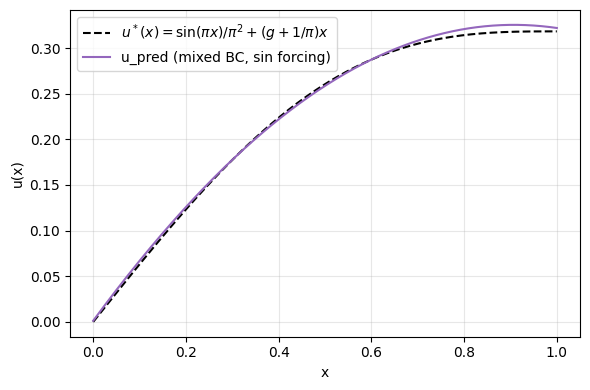

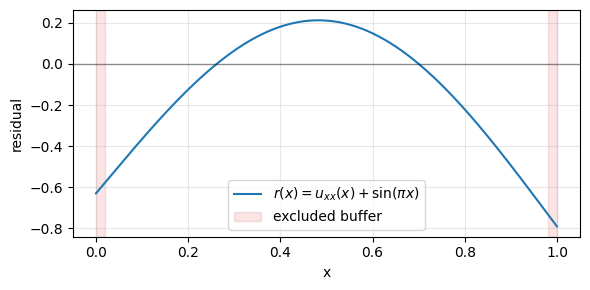

In [43]:
# Mixed BC + sinusoidal forcing (PLOT + METRICS CELL)

x_grid = np.linspace(0.0, 1.0, 401)
x_in = np.clip(x_grid, 1e-6, 1.0 - 1e-6)
batch = x_in.shape[0]

n_modes = model_neu_sin.layers[0].input_size
X0 = np.zeros((n_modes, batch), dtype=np.complex128)
X0[0, :] = x_in
if n_modes > 1:
    X0[1:, :] = 1.0
dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
d2X0 = np.zeros_like(X0)

XL, dXL, d2XL = forward_pass_derivatives(model_neu_sin, X0, dX0, d2X0)
u_pred, u_x_pred, u_xx_pred, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)

u_true = u_true_sinpi_mixed(x_grid, g=g_neu_sin)
l2 = float(np.sqrt(np.mean((u_pred - u_true) ** 2)))
bc_dir_err = float(abs(u_pred[0]))
ux_1m = float(u_x_pred[-1])
neu_err = float(abs(ux_1m - g_neu_sin))

# Strong-form residual r=u_xx + sin(pi x) (diagnostic only)
r = u_xx_pred + f_sinpi_mixed(x_in)
r_rms = float(np.sqrt(np.mean(r ** 2)))
r_max = float(np.max(np.abs(r)))
buffer = 0.02
mask_int = (x_grid >= buffer) & (x_grid <= 1.0 - buffer)
r_rms_int = float(np.sqrt(np.mean(r[mask_int] ** 2)))
r_max_int = float(np.max(np.abs(r[mask_int])))

print('Dirichlet error |u(0)|:', bc_dir_err)
print('Neumann error |u_x(1-)-g|:', neu_err, '  (u_x(1-)≈', ux_1m, ')')
print('L2 error (grid):', l2)
print('Residual RMS (full):', r_rms, '  max:', r_max)
print(f'Residual RMS (interior |x-0|>{buffer}):', r_rms_int, '  max:', r_max_int)

plt.figure(figsize=(6,4))
plt.plot(x_grid, u_true, 'k--', label=r'$u^*(x)=\sin(\pi x)/\pi^2 + (g+1/\pi)x$')
plt.plot(x_grid, u_pred, 'C4', label='u_pred (mixed BC, sin forcing)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,3))
plt.plot(x_in, r, lw=1.5, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
plt.axhline(0.0, color='k', lw=1, alpha=0.4)
plt.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
plt.axvspan(1.0-buffer, 1.0, color='C3', alpha=0.12)
plt.xlabel('x'); plt.ylabel('residual')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout(); plt.show()

In [44]:
# --- Circuit info only (mixed BC, sin forcing): architecture, modes, encoding ---
import numpy as np

print('=== CIRCUIT / MODEL INFO (mixed BC, sin forcing) ===')
if 'model_neu_sin' not in globals():
    raise RuntimeError('No `model_neu_sin` found in globals(). Run the mixed-BC+sin training cell first.')

layers = list(getattr(model_neu_sin, 'layers', []))
print('Model type:', type(model_neu_sin))
print('Number of layers:', len(layers))

# Number of modes/ports
if len(layers) > 0 and hasattr(layers[0], 'input_size'):
    n_modes = int(layers[0].input_size)
else:
    n_modes = None
print('Number of modes (N):', n_modes)

print('\nLayers:')
for i, layer in enumerate(layers):
    layer_name = layer.__class__.__name__
    desc = [f'[{i}] {layer_name}']
    if hasattr(layer, 'input_size'):
        desc.append(f"in={getattr(layer, 'input_size')}")
    if hasattr(layer, 'output_size'):
        desc.append(f"out={getattr(layer, 'output_size')}")
    if hasattr(layer, 'mesh'):
        mesh = getattr(layer, 'mesh')
        desc.append(f"mesh={mesh.__class__.__name__}")
        if hasattr(mesh, 'all_tunable_components'):
            cmpts = list(mesh.all_tunable_components())
            dof_total = int(sum(int(getattr(c, 'dof', 0)) for c in cmpts))
            desc.append(f"tunable_components={len(cmpts)}")
            desc.append(f"total_dof={dof_total}")
    print('  ' + '  |  '.join(desc))

print('\n=== RUN PARAMETERS (from current globals) ===')
def _maybe(name):
    return globals()[name] if name in globals() else None

print('Mixed BC (sin) params:')
print('  init_seed =', _maybe('init_seed'))
print('  train_seed =', _maybe('train_seed'))
print('  g_neu_sin =', _maybe('g_neu_sin'))
print('  epochs (len(losses_neu_sin)) =', len(losses_neu_sin) if 'losses_neu_sin' in globals() else None)

print('\n=== INPUT ENCODING (as implemented) ===')
print('Using n_modes =', n_modes)
print('X0 construction:')
print('  X0 = zeros((n_modes, batch), complex128)')
print('  X0[0, :] = x')
if n_modes is None:
    print('  X0[1:, :] = 1.0   (cannot confirm n_modes>1 because n_modes is None)')
elif n_modes > 1:
    print('  X0[1:, :] = 1.0')
else:
    print('  (n_modes==1) => no X0[1:, :] rows exist')

print('dX0 construction:')
print('  dX0 = zeros_like(X0)')
print('  dX0[0, :] = 1.0')
print('d2X0 construction:')
print('  d2X0 = zeros_like(X0)')


=== CIRCUIT / MODEL INFO (mixed BC, sin forcing) ===
Model type: <class 'neuroptica.models.Sequential'>
Number of layers: 4
Number of modes (N): 3

Layers:
  [0] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [1] Activation  |  in=3  |  out=3
  [2] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [3] Activation  |  in=3  |  out=3

=== RUN PARAMETERS (from current globals) ===
Mixed BC (sin) params:
  init_seed = 0
  train_seed = 1
  g_neu_sin = 0.0
  epochs (len(losses_neu_sin)) = 7500

=== INPUT ENCODING (as implemented) ===
Using n_modes = 3
X0 construction:
  X0 = zeros((n_modes, batch), complex128)
  X0[0, :] = x
  X0[1:, :] = 1.0
dX0 construction:
  dX0 = zeros_like(X0)
  dX0[0, :] = 1.0
d2X0 construction:
  d2X0 = zeros_like(X0)


epoch 200/3750  loss=1.569553e-02
epoch 400/3750  loss=-4.243274e-02
epoch 600/3750  loss=-6.834346e-02
epoch 800/3750  loss=-1.002608e-01
epoch 1000/3750  loss=-6.621798e-02
epoch 1200/3750  loss=-6.466975e-02
epoch 1400/3750  loss=-6.440422e-02
epoch 1600/3750  loss=-8.654243e-02
epoch 1800/3750  loss=-2.913892e-02
epoch 2000/3750  loss=-8.981159e-02
epoch 2200/3750  loss=-6.556533e-02
epoch 2400/3750  loss=-6.168343e-02
epoch 2600/3750  loss=-8.879806e-02
epoch 2800/3750  loss=-7.474643e-02
epoch 3000/3750  loss=-8.580349e-02
epoch 3200/3750  loss=-6.661547e-02
epoch 3400/3750  loss=-7.056309e-02
epoch 3600/3750  loss=-6.048950e-02
Mixed BC (sin) snapshot iterations: {'first': 1, 'mid': 3750, 'final': 7500}
Final loss (mixed BC, sin): -0.08710458583651168


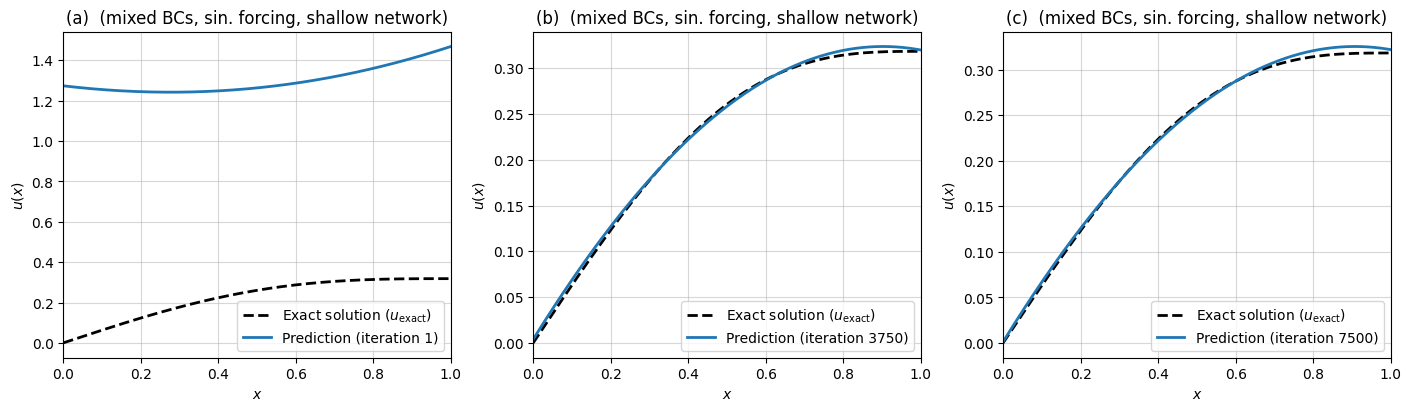

In [95]:
# --- Paper-style figure (mixed BC, sin forcing): predictions at 1 / mid / final (solutions only) ---
if 'f_sinpi_mixed' not in globals() or 'u_true_sinpi_mixed' not in globals():
    raise RuntimeError('Run the mixed-BC+sin training cell first (defines f_sinpi_mixed/u_true_sinpi_mixed).')
if 'build_photonic_model' not in globals():
    raise RuntimeError('Expected build_photonic_model to exist (defined earlier in the notebook).')
if 'fit_unsupervised_insitu_adam_fx_neumann1' not in globals():
    raise RuntimeError('Expected fit_unsupervised_insitu_adam_fx_neumann1 to exist (defined in the mixed-BC section).')

def _style_axes_paper(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

# Pull hyperparams from the training cell (authoritative)
required = ['init_seed', 'train_seed', 'N_neu_sin', 'epochs_neu_sin', 'batch_size_neu_sin', 'step_size_neu_sin', 'lambda_dirichlet_neu_sin', 'losses_neu_sin']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for mixed-BC+sin: ' + ', '.join(missing) + '. Run the training cell first.')
init_seed_neu_sin = int(init_seed)
train_seed_neu_sin = int(train_seed)
g_neu_sin_val = float(g_neu_sin)
N_neu_sin_val = int(N_neu_sin)
batch_size_neu_sin = int(batch_size_neu_sin)
step_size_neu_sin = float(step_size_neu_sin)
lambda_dirichlet_neu_sin = float(lambda_dirichlet_neu_sin)

epochs_final_neu_sin = len(losses_neu_sin)
epoch_first_neu_sin = 0
epoch_mid_neu_sin = max(0, (epochs_final_neu_sin // 2) - 1)
epoch_final_neu_sin = epochs_final_neu_sin - 1

x_plot_sin = np.linspace(0.0, 1.0, 401)
x_plot_in_sin = np.clip(x_plot_sin, 1e-6, 1.0 - 1e-6)
u_exact_sin = u_true_sinpi_mixed(x_plot_sin, g=float(g_neu_sin_val))

def _eval_u_on_grid_neu_sin(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def _train_model_neu_sin_for_epochs(epochs: int):
    model_tmp = build_photonic_model(N=int(N_neu_sin_val), seed=int(init_seed_neu_sin))
    losses_tmp = fit_unsupervised_insitu_adam_fx_neumann1(
        model_tmp,
        f_fn=f_sinpi_mixed,
        g_neumann=float(g_neu_sin_val),
        epochs=int(epochs),
        batch_size=int(batch_size_neu_sin),
        step_size=float(step_size_neu_sin),
        seed=int(train_seed_neu_sin),
        lambda_dirichlet=float(lambda_dirichlet_neu_sin),
    )
    return model_tmp, losses_tmp

# Reuse existing trained model as final snapshot when possible
if 'model_neu_sin' in globals() and 'losses_neu_sin' in globals() and isinstance(losses_neu_sin, list) and len(losses_neu_sin) >= (epoch_final_neu_sin + 1):
    model_final_neu_sin = model_neu_sin
    losses_final_neu_sin = losses_neu_sin
else:
    model_final_neu_sin, losses_final_neu_sin = _train_model_neu_sin_for_epochs(epoch_final_neu_sin + 1)

# Retrain deterministically for first/mid snapshots
model_first_neu_sin, _ = _train_model_neu_sin_for_epochs(epoch_first_neu_sin + 1)
model_mid_neu_sin, _ = _train_model_neu_sin_for_epochs(epoch_mid_neu_sin + 1)

u_pred_first_sin = _eval_u_on_grid_neu_sin(model_first_neu_sin, x_plot_in_sin)
u_pred_mid_sin = _eval_u_on_grid_neu_sin(model_mid_neu_sin, x_plot_in_sin)
u_pred_final_sin = _eval_u_on_grid_neu_sin(model_final_neu_sin, x_plot_in_sin)

print('Mixed BC (sin) snapshot iterations:', {'first': epoch_first_neu_sin + 1, 'mid': epoch_mid_neu_sin + 1, 'final': epoch_final_neu_sin + 1})
print('Final loss (mixed BC, sin):', float(losses_final_neu_sin[-1]) if isinstance(losses_final_neu_sin, list) and len(losses_final_neu_sin) else None)

fig_neu_sin_sol, (ax_first, ax_mid, ax_final) = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

def _plot_panel(ax, u_pred, it_number, title):
    ax.plot(x_plot_sin, u_exact_sin, 'k--', linewidth=2.0, label=r'Exact solution ($u_{\mathrm{exact}}$)')
    ax.plot(x_plot_sin, u_pred, color='C0', linewidth=2.0, label=f'Prediction (iteration {it_number})')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$u(x)$')
    ax.set_title(title + r'  (mixed BCs, sin. forcing, shallow network)')
    _style_axes_paper(ax)
    ax.legend(frameon=True)

_plot_panel(ax_first, u_pred_first_sin, epoch_first_neu_sin + 1, '(a)')
_plot_panel(ax_mid, u_pred_mid_sin, epoch_mid_neu_sin + 1, '(b)')
_plot_panel(ax_final, u_pred_final_sin, epoch_final_neu_sin + 1, '(c)')

plt.show()


In [106]:
# --- Save paper-ready mixed-BC (sin forcing) solutions figure (added cell) ---
import os

if 'fig_neu_sin_sol' not in globals():
    raise RuntimeError('Run the mixed-BC (sin) solutions plotting cell first so `fig_neu_sin_sol` exists.')

out_name_mixed_sin_sol = 'pde1d_mixedBC_sin_solutions.pdf'
fig_neu_sin_sol.savefig(out_name_mixed_sin_sol, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_sol))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_solutions.pdf


Neumann check (at x=1-eps): u_x(1-)≈ -0.07396263124627052  target g= 0.0  |error|= 0.07396263124627052


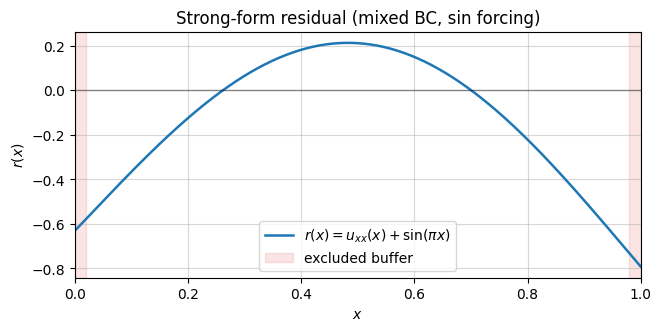

In [73]:
# --- Paper-style figure (mixed BC, sin forcing): strong-form residual + Neumann check ---
if 'model_neu_sin' not in globals():
    raise RuntimeError('Run the mixed-BC+sin training cell first so `model_neu_sin` exists.')

# Styling helper (self-contained)
def _style_axes_paper(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

g_neu_sin_val = g_neu_sin if 'g_neu_sin' in globals() else 0.0

x_grid_res = np.linspace(0.0, 1.0, 401)
x_in_res = np.clip(x_grid_res, 1e-6, 1.0 - 1e-6)
batch_res = x_in_res.shape[0]
n_modes_res = model_neu_sin.layers[0].input_size
X0_res = np.zeros((n_modes_res, batch_res), dtype=np.complex128)
X0_res[0, :] = x_in_res
if n_modes_res > 1:
    X0_res[1:, :] = 1.0
dX0_res = np.zeros_like(X0_res)
dX0_res[0, :] = 1.0
d2X0_res = np.zeros_like(X0_res)

XL_res, dXL_res, d2XL_res = forward_pass_derivatives(model_neu_sin, X0_res, dX0_res, d2X0_res)
_, u_x_res, u_xx_res, _ = linear_readout(x_in_res, XL_res, dXL_res, d2XL_res, a=None, b=0.0)

r_neu_sin = np.real(u_xx_res) + np.asarray(f_sinpi_mixed(x_in_res), dtype=np.float64)
ux_1m = float(np.real(u_x_res[-1]))
neu_err = float(abs(ux_1m - float(g_neu_sin_val)))
print('Neumann check (at x=1-eps): u_x(1-)≈', ux_1m, ' target g=', float(g_neu_sin_val), ' |error|=', neu_err)

buffer = 0.02
fig_neu_sin_res, ax = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x_in_res, r_neu_sin, linewidth=1.8, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
ax.axvspan(1.0 - buffer, 1.0, color='C3', alpha=0.12)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$r(x)$')
ax.set_title('Strong-form residual (mixed BC, sin forcing)')
_style_axes_paper(ax)
ax.legend(frameon=True, loc='best')
plt.show()


In [74]:
# --- Save paper-ready mixed-BC (sin forcing) residual figure (added cell) ---
import os

if 'fig_neu_sin_res' not in globals():
    raise RuntimeError('Run the mixed-BC (sin) residual plotting cell first so `fig_neu_sin_res` exists.')

out_name_mixed_sin_res = 'pde1d_mixedBC_sin_residual.pdf'
fig_neu_sin_res.savefig(out_name_mixed_sin_res, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_res))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_residual.pdf


In [108]:
# --- Extra diagnostics (mixed BC, sin forcing): relative L2 error per iteration (added cell) ---
# NOTE: This retrains from scratch (same init/seed) to get the full per-iteration curve.
# It can take a while because it evaluates u(x) during training.

n_eval_neu = 101
compute_every_neu_sin = 10  # set to 1 for every iteration
required = ['init_seed', 'train_seed', 'g_neu_sin', 'N_neu_sin', 'epochs_neu_sin', 'batch_size_neu_sin', 'step_size_neu_sin', 'lambda_dirichlet_neu_sin', 'losses_neu_sin']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing training variables for mixed-BC+sin diagnostics: ' + ', '.join(missing) + '. Run the training cell first.')
epochs_neu_sin_err = len(losses_neu_sin)
init_seed_neu_sin = int(init_seed)
train_seed_neu_sin = int(train_seed)
g_neu_sin_val = float(g_neu_sin)
N_neu_sin_val = int(N_neu_sin)
batch_size_neu_sin = int(batch_size_neu_sin)
step_size_neu_sin = float(step_size_neu_sin)
lambda_dirichlet_neu_sin = float(lambda_dirichlet_neu_sin)

x_err_neu_sin = np.linspace(0.0, 1.0, n_eval_neu)
x_err_in_neu_sin = np.clip(x_err_neu_sin, 1e-6, 1.0 - 1e-6)
u_exact_err_neu_sin = u_true_sinpi_mixed(x_err_neu_sin, g=float(g_neu_sin_val))
den_neu_sin = float(np.sqrt(np.mean(u_exact_err_neu_sin**2)))
den_neu_sin = den_neu_sin if den_neu_sin > 0 else 1.0

def _eval_u_real_neu_sin(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def train_neu_sin_with_l2_curve():
    rng = np.random.default_rng(train_seed_neu_sin)
    np.random.seed(init_seed_neu_sin)
    model_err_neu_sin = build_photonic_model(N=int(N_neu_sin_val), seed=int(init_seed_neu_sin))

    m = {}
    v = {}
    t = 0
    for layer in model_err_neu_sin.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses_signed_neu_sin = []
    iters_neu_sin = []
    rel_l2_neu_sin = []

    n_modes = model_err_neu_sin.layers[0].input_size

    for epoch in range(int(epochs_neu_sin_err)):
        t += 1
        x_int = rng.random(int(batch_size_neu_sin))
        x_int = np.clip(x_int, 1e-6, 1.0 - 1e-6)

        # boundary samples (Dirichlet at 0, Neumann at 1)
        x_dir = np.array([0.0], dtype=np.float64)
        x_neu = np.array([1.0], dtype=np.float64)
        x = np.concatenate([x_int, x_dir, x_neu], axis=0)
        is_dir = np.zeros((x.shape[0],), dtype=bool)
        is_neu = np.zeros((x.shape[0],), dtype=bool)
        is_dir[-2] = True
        is_neu[-1] = True

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model_err_neu_sin.forward_pass(X0)
        XL, dXL, d2XL = forward_pass_derivatives(model_err_neu_sin, X0, dX0, d2X0)
        loss, d_loss_star = build_dloss_star_fx_neumann1(
            x, XL, dXL, d2XL,
            f_fn=f_sinpi_mixed,
            g_neumann=float(g_neu_sin_val),
            a=None, b=0.0,
            is_dirichlet=is_dir,
            is_neumann=is_neu,
            lambda_dirichlet=float(lambda_dirichlet_neu_sin),
        )
        losses_signed_neu_sin.append(float(loss))

        deltas = model_err_neu_sin.backward_pass(d_loss_star)
        delta_prev = d_loss_star
        for layer in reversed(model_err_neu_sin.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(layer.input_prev, delta_prev)
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = 0.9 * m[cmpt] + (1 - 0.9) * g
                    v[cmpt] = 0.99 * v[cmpt] + (1 - 0.99) * (g ** 2)
                    mhat = m[cmpt] / (1 - 0.9 ** t)
                    vhat = v[cmpt] / (1 - 0.99 ** t)
                    step = -float(step_size_neu_sin) * mhat / (np.sqrt(vhat) + 1e-8)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch % int(compute_every_neu_sin)) == 0:
            u_pred_err = _eval_u_real_neu_sin(model_err_neu_sin, x_err_in_neu_sin)
            num = float(np.sqrt(np.mean((u_pred_err - u_exact_err_neu_sin) ** 2)))
            iters_neu_sin.append(epoch + 1)
            rel_l2_neu_sin.append(num / den_neu_sin)

        if (epoch + 1) % 500 == 0:
            print(f"iter {epoch+1}/{int(epochs_neu_sin_err)}  loss={loss:+.3e}  relL2(last)={rel_l2_neu_sin[-1]:.3e}")

    return model_err_neu_sin, losses_signed_neu_sin, np.array(iters_neu_sin), np.array(rel_l2_neu_sin)

model_err_neu_sin, losses_signed_neu_sin, iters_neu_sin, rel_l2_neu_sin = train_neu_sin_with_l2_curve()
print('Done. Final signed loss:', losses_signed_neu_sin[-1], ' Final rel L2:', rel_l2_neu_sin[-1])


iter 500/7500  loss=-5.111e-02  relL2(last)=4.409e-01
iter 1000/7500  loss=-6.622e-02  relL2(last)=2.608e-02
iter 1500/7500  loss=-8.570e-02  relL2(last)=1.976e-02
iter 2000/7500  loss=-8.981e-02  relL2(last)=3.419e-02
iter 2500/7500  loss=-7.127e-02  relL2(last)=1.150e-02
iter 3000/7500  loss=-8.580e-02  relL2(last)=1.514e-02
iter 3500/7500  loss=-4.909e-02  relL2(last)=2.718e-02
iter 4000/7500  loss=-7.584e-02  relL2(last)=2.466e-02
iter 4500/7500  loss=-6.696e-02  relL2(last)=2.848e-02
iter 5000/7500  loss=-6.163e-02  relL2(last)=1.577e-02
iter 5500/7500  loss=-6.428e-02  relL2(last)=2.524e-02
iter 6000/7500  loss=-5.807e-02  relL2(last)=1.998e-02
iter 6500/7500  loss=-6.064e-02  relL2(last)=1.205e-02
iter 7000/7500  loss=-5.395e-02  relL2(last)=1.297e-02
iter 7500/7500  loss=-8.710e-02  relL2(last)=3.775e-02
Done. Final signed loss: -0.08710458583651168  Final rel L2: 0.037750306143858506


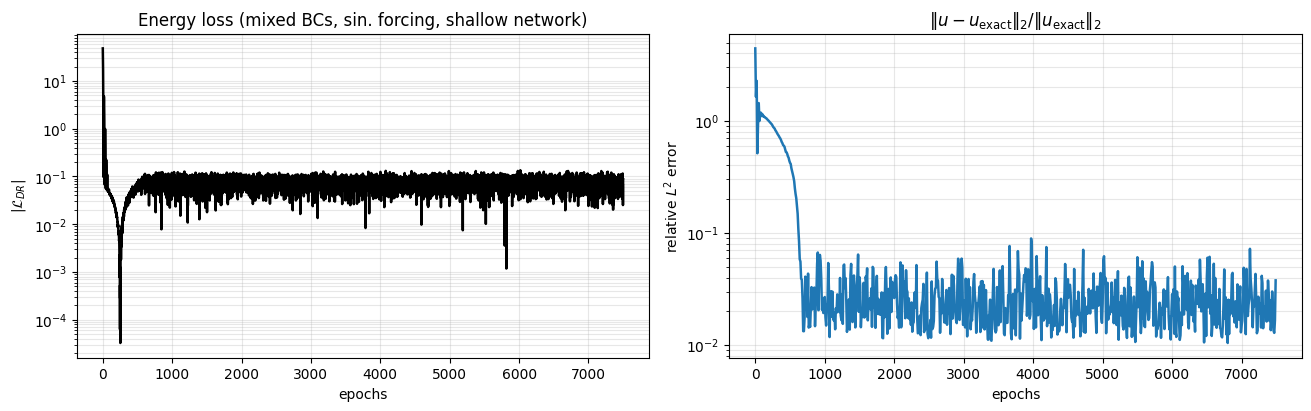

In [122]:
# --- Paper-style losses + relative L2 error (mixed BC, sin forcing) ---
# If you ran the per-iteration diagnostics cell, this will plot both |loss| and relative L2.
# Otherwise it will plot only |loss| from `losses_neu_sin`.

if 'losses_signed_neu_sin' in globals():
    loss_neu_sin_arr = np.asarray(losses_signed_neu_sin, dtype=float)
elif 'losses_neu_sin' in globals():
    loss_neu_sin_arr = np.asarray(losses_neu_sin, dtype=float)
else:
    raise RuntimeError('No losses found. Run the mixed-BC+sin training cell first.')

abs_loss_neu_sin = np.abs(loss_neu_sin_arr)
epochs_neu_sin = np.arange(1, abs_loss_neu_sin.size + 1)

has_rel_neu_sin = ('rel_l2_neu_sin' in globals()) and ('iters_neu_sin' in globals())

if has_rel_neu_sin:
    fig_neu_sin_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
else:
    fig_neu_sin_loss, ax1 = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)

# Absolute energy loss
ax1.plot(epochs_neu_sin, abs_loss_neu_sin, color='k', linewidth=1.8)
ax1.set_xlabel('epochs')
ax1.set_ylabel(r'$|\mathcal{L}_{DR}|$')
ax1.set_yscale('log')
ax1.set_title('Energy loss (mixed BCs, sin. forcing, shallow network)')
ax1.grid(True, which='both', alpha=0.3)

if has_rel_neu_sin:
    ax2.plot(iters_neu_sin, rel_l2_neu_sin, color='C0', linewidth=1.8)
    ax2.set_xlabel('epochs')
    ax2.set_ylabel(r'relative $L^2$ error')
    ax2.set_yscale('log')
    ax2.set_title(r'$\|u-u_{\mathrm{exact}}\|_2 / \|u_{\mathrm{exact}}\|_2$')
    ax2.grid(True, which='both', alpha=0.3)

plt.show()


In [123]:
# --- Save paper-ready mixed-BC (sin forcing) losses figure (added cell) ---
import os

if 'fig_neu_sin_loss' not in globals():
    raise RuntimeError('Run the mixed-BC (sin) losses plotting cell first so `fig_neu_sin_loss` exists.')

out_name_mixed_sin_loss = 'pde1d_mixedBC_sin_losses.pdf'
fig_neu_sin_loss.savefig(out_name_mixed_sin_loss, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_loss))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_losses.pdf


## B5: Mixed BC, sinusoidal forcing (deep model variant)

This is a **separate** exercise from B4: same PDE/BC ($f(x)=\sin(\pi x)$, $u(0)=0$, $u'(1)=g$) but a deeper photonic model to increase expressivity, without changing any previous models/variables.

In [129]:
# Deep-model TRAINING (standalone): uses new variables only.
# Requires: build_photonic_model, fit_unsupervised_insitu_adam_fx_neumann1, forward_pass_derivatives, linear_readout already defined above.

def build_photonic_model_deep(N: int = 3, depth: int = 4, seed: int = 0) -> neu.Sequential:
    """
    depth = number of (ClementsLayer + z^2) blocks.
    Keeps everything else identical to the shallow model, just deeper.
    """
    np.random.seed(seed)
    layers = []
    for _ in range(depth):
        layers.append(neu.ClementsLayer(N))
        layers.append(neu.Activation(ComplexSquared(N)))
    return neu.Sequential(layers)

# Keep the SAME PDE/BC as the sinusoidal benchmark, but use a deeper model
init_seed_deep = 0
train_seed_deep = 1
N_neu_sin_deep = 3
depth_neu_sin_deep = 4
g_neu_sin_deep = g_neu_sin  # reuse g from the exercise above
model_neu_sin_deep = build_photonic_model_deep(N=int(N_neu_sin_deep), depth=int(depth_neu_sin_deep), seed=int(init_seed_deep))


### What the loss means vs what the diagnostics show

In this notebook the optimizer is driven by a Deep Ritz (energy) objective $J(\theta)$, which is a variational functional for the PDE. This quantity is useful for training, but it is **not** a direct, monotone measure of solution accuracy: it can be negative (due to the forcing/loading terms), it is noisy under mini-batching, and small changes in $J$ do not necessarily imply small PDE error.

To demonstrate convergence to the **PDE solution** (as in Yu & E, 2017), we therefore report *physics diagnostics* on a fixed test grid versus epoch:
- Relative $L^2$ error when an exact/reference solution is available.
- PDE residual norm $\| -u_\theta'' - f \|_{L^2}$ (always meaningful, even without $u_{exact}$).
- Boundary residuals (e.g., $|u_\theta'(1)-g|$ and $|u_\theta(0)-0|$).

To avoid redundancy, the deep model is trained **once** in the diagnostics+training cell below, and the same trained model/loss history is reused for any subsequent plots.

In [130]:
# Yu & E (2017)-style diagnostics during training (Poisson 1D, mixed BC)
# Requirements: NumPy + matplotlib for plots; diagnostics are computed independently of the Deep Ritz energy.
import numpy as np

def l2_norm_trapz(y: np.ndarray, x: np.ndarray) -> float:
    """Approximate ||y||_{L^2(0,1)} via sqrt(∫ y^2 dx) using trapezoidal rule."""
    y = np.asarray(y, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.trapz(y * y, x)))

def predict_u_ux_uxx_on_grid(model: neu.Sequential, x: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (u(x), u_x(x), u_xx(x)) computed through the photonic model + linear readout."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    batch = x.size
    n_modes = model.layers[0].input_size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)
    u, u_x, u_xx, _ = linear_readout(x, XL, dXL, d2XL, a=None, b=0.0)
    return (np.asarray(u, dtype=np.float64), np.asarray(u_x, dtype=np.float64), np.asarray(u_xx, dtype=np.float64))

def poisson_mixed_bc_diagnostics(
    model: neu.Sequential,
    f_fn,
    g_neumann: float,
    x_test: np.ndarray,
    u_exact_fn=None,
    dirichlet_value_at_0: float = 0.0,
 ) -> dict:
    """
    Diagnostics computed on a fixed grid, independent of training loss.

    PDE: -u''(x) = f(x) on (0,1), with u(0)=dirichlet_value_at_0 and u'(1)=g_neumann.

    Returns:
      - rel_l2 (NaN if u_exact_fn is None)
      - pde_res_l2 = || -u'' - f ||_{L^2}
      - neu_bc_abs = |u'(1) - g|
      - dir_bc_abs = |u(0) - dirichlet_value_at_0|
    """
    x_test = np.asarray(x_test, dtype=np.float64).reshape(-1)
    x_res = np.clip(x_test, 1e-6, 1.0 - 1e-6)
    u, _, u_xx = predict_u_ux_uxx_on_grid(model, x_res)
    f_val = np.asarray(f_fn(x_res), dtype=np.float64).reshape(-1)
    pde_res = (-u_xx - f_val)
    pde_res_l2 = l2_norm_trapz(pde_res, x_res)

    # Boundary residuals (single-point queries).
    x0 = np.array([0.0], dtype=np.float64)
    x1 = np.array([1.0], dtype=np.float64)
    u0, _, _ = predict_u_ux_uxx_on_grid(model, x0)
    _, u_x1, _ = predict_u_ux_uxx_on_grid(model, x1)
    dir_bc_abs = float(np.abs(u0[0] - dirichlet_value_at_0))
    neu_bc_abs = float(np.abs(u_x1[0] - g_neumann))

    rel_l2 = float('nan')
    if u_exact_fn is not None:
        try:
            u_ex = np.asarray(u_exact_fn(x_res, g=g_neumann), dtype=np.float64).reshape(-1)
        except TypeError:
            u_ex = np.asarray(u_exact_fn(x_res), dtype=np.float64).reshape(-1)
        num = l2_norm_trapz(u - u_ex, x_res)
        den = l2_norm_trapz(u_ex, x_res)
        rel_l2 = float(num / (den + 1e-16))

    return {
        'rel_l2': rel_l2,
        'pde_res_l2': pde_res_l2,
        'neu_bc_abs': neu_bc_abs,
        'dir_bc_abs': dir_bc_abs,
    }

def fit_unsupervised_insitu_adam_fx_neumann1_with_diagnostics(
    model: neu.Sequential,
    f_fn,
    g_neumann: float,
    *,
    epochs: int = 2000,
    batch_size: int = 64,
    step_size: float = 0.005,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    seed: int = 0,
    cache_fields: bool = False,
    use_partial_vectors: bool = False,
    a: np.ndarray | None = None,
    b: float = 0.0,
    lambda_dirichlet: float = 200.0,
    x_test: np.ndarray | None = None,
    u_exact_fn=None,
    diag_every: int = 20,
    print_every: int = 200,
 ) -> dict:
    """Same optimizer as fit_unsupervised_insitu_adam_fx_neumann1, plus Yu&E-style diagnostics vs epoch."""
    rng = np.random.default_rng(seed)
    m = {}
    v = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses = []
    diag_epochs = []
    rel_l2_hist = []
    pde_res_l2_hist = []
    neu_bc_abs_hist = []
    dir_bc_abs_hist = []

    n_modes = model.layers[0].input_size
    if x_test is None:
        x_test = np.linspace(0.0, 1.0, 401)
    x_test = np.asarray(x_test, dtype=np.float64).reshape(-1)

    for epoch in range(epochs):
        t += 1
        x_int = rng.random(batch_size)
        x_int = np.clip(x_int, 1e-6, 1.0 - 1e-6)

        # boundary samples (Dirichlet at 0, Neumann at 1)
        x_dir = np.array([0.0], dtype=np.float64)
        x_neu = np.array([1.0], dtype=np.float64)
        x = np.concatenate([x_int, x_dir, x_neu], axis=0)
        is_dir = np.zeros((x.shape[0],), dtype=bool)
        is_neu = np.zeros((x.shape[0],), dtype=bool)
        is_dir[-2] = True
        is_neu[-1] = True

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        XL, dXL, d2XL = forward_pass_derivatives(model, X0, dX0, d2X0)

        loss, d_loss_star = build_dloss_star_fx_neumann1(
            x, XL, dXL, d2XL,
            f_fn=f_fn,
            g_neumann=g_neumann,
            a=a, b=b,
            is_dirichlet=is_dir,
            is_neumann=is_neu,
            lambda_dirichlet=lambda_dirichlet,
        )
        losses.append(loss)

        deltas = model.backward_pass(d_loss_star, cache_fields=cache_fields, use_partial_vectors=use_partial_vectors)
        delta_prev = d_loss_star
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev,
                    delta_prev,
                    cache_fields=cache_fields,
                    use_partial_vectors=use_partial_vectors,
                )
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = beta1 * m[cmpt] + (1 - beta1) * g
                    v[cmpt] = beta2 * v[cmpt] + (1 - beta2) * (g ** 2)
                    mhat = m[cmpt] / (1 - beta1 ** t)
                    vhat = v[cmpt] / (1 - beta2 ** t)
                    step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        ep = epoch + 1
        if (ep % diag_every) == 0 or ep == 1 or ep == epochs:
            met = poisson_mixed_bc_diagnostics(
                model, f_fn=f_fn, g_neumann=g_neumann, x_test=x_test, u_exact_fn=u_exact_fn
            )
            diag_epochs.append(ep)
            rel_l2_hist.append(met['rel_l2'])
            pde_res_l2_hist.append(met['pde_res_l2'])
            neu_bc_abs_hist.append(met['neu_bc_abs'])
            dir_bc_abs_hist.append(met['dir_bc_abs'])

        if (ep % print_every) == 0:
            print(f"epoch {ep}/{epochs}  loss={loss:.6e}")

    return {
        'losses': np.asarray(losses, dtype=np.float64),
        'diag_epochs': np.asarray(diag_epochs, dtype=np.int64),
        'rel_l2': np.asarray(rel_l2_hist, dtype=np.float64),
        'pde_res_l2': np.asarray(pde_res_l2_hist, dtype=np.float64),
        'neu_bc_abs': np.asarray(neu_bc_abs_hist, dtype=np.float64),
        'dir_bc_abs': np.asarray(dir_bc_abs_hist, dtype=np.float64),
    }

# --- Deep-model run with diagnostics (single training run; reused by later cells) ---
# Set u_exact_fn=None when no reference solution is available.
x_test_grid = np.linspace(0.0, 1.0, 401)
u_exact_fn = u_true_sinpi_mixed if 'u_true_sinpi_mixed' in globals() else None

# Canonical hyperparameters for the deep mixed-BC+sin benchmark.
epochs_neu_sin_deep = 7500
batch_size_neu_sin_deep = 64
step_size_neu_sin_deep = 0.005
lambda_dirichlet_neu_sin_deep = 50.0

# Backwards-compatible aliases used by earlier plotting/print cells.
epochs_deep_diag = int(epochs_neu_sin_deep)
step_size_deep_diag = float(step_size_neu_sin_deep)
lambda_dirichlet_deep_diag = float(lambda_dirichlet_neu_sin_deep)

model_neu_sin_deep = build_photonic_model_deep(N=3, depth=int(depth_neu_sin_deep), seed=int(init_seed_deep))
hist_neu_sin_deep = fit_unsupervised_insitu_adam_fx_neumann1_with_diagnostics(
    model_neu_sin_deep,
    f_fn=f_sinpi_mixed,
    g_neumann=g_neu_sin_deep,
    epochs=int(epochs_neu_sin_deep),
    batch_size=batch_size_neu_sin_deep,
    step_size=float(step_size_neu_sin_deep),
    seed=train_seed_deep,
    lambda_dirichlet=float(lambda_dirichlet_neu_sin_deep),
    x_test=x_test_grid,
    u_exact_fn=u_exact_fn,
    diag_every=20,
    print_every=200,
 )

# Keep legacy variable names for backwards compatibility with existing plotting cells.
hist_neu_sin_deep_diag = hist_neu_sin_deep
losses_neu_sin_deep = list(hist_neu_sin_deep['losses'])
print('final loss (mixed BC, sin forcing, deep):', float(losses_neu_sin_deep[-1]))
print('last diagnostics (deep):', {
    'epoch': int(hist_neu_sin_deep['diag_epochs'][-1]) if len(hist_neu_sin_deep['diag_epochs']) else None,
    'pde_res_l2': float(hist_neu_sin_deep['pde_res_l2'][-1]) if len(hist_neu_sin_deep['pde_res_l2']) else None,
    'neu_bc_abs': float(hist_neu_sin_deep['neu_bc_abs'][-1]) if len(hist_neu_sin_deep['neu_bc_abs']) else None,
    'dir_bc_abs': float(hist_neu_sin_deep['dir_bc_abs'][-1]) if len(hist_neu_sin_deep['dir_bc_abs']) else None,
    'rel_l2': float(hist_neu_sin_deep['rel_l2'][-1]) if len(hist_neu_sin_deep['rel_l2']) else None,
})

epoch 200/7500  loss=-5.707686e-02
epoch 400/7500  loss=-6.598553e-02
epoch 600/7500  loss=-6.272296e-02
epoch 800/7500  loss=-8.117880e-02
epoch 1000/7500  loss=-7.987349e-02
epoch 1200/7500  loss=-7.226030e-02
epoch 1400/7500  loss=-6.101577e-02
epoch 1600/7500  loss=-8.766164e-02
epoch 1800/7500  loss=-2.767997e-02
epoch 2000/7500  loss=-8.471632e-02
epoch 2200/7500  loss=-6.353597e-02
epoch 2400/7500  loss=-5.666941e-02
epoch 2600/7500  loss=-8.375330e-02
epoch 2800/7500  loss=-6.326357e-02
epoch 3000/7500  loss=-8.614899e-02
epoch 3200/7500  loss=-6.931551e-02
epoch 3400/7500  loss=-7.807884e-02
epoch 3600/7500  loss=-6.157089e-02
epoch 3800/7500  loss=-8.983587e-02
epoch 4000/7500  loss=-7.335898e-02
epoch 4200/7500  loss=-1.154342e-01
epoch 4400/7500  loss=-7.205353e-02
epoch 4600/7500  loss=-1.115727e-01
epoch 4800/7500  loss=-8.748514e-02
epoch 5000/7500  loss=-6.688254e-02
epoch 5200/7500  loss=-7.341908e-02
epoch 5400/7500  loss=-7.612510e-02
epoch 5600/7500  loss=-7.738368e

DEEP model metrics
  Dirichlet error |u(0)|: 0.0011528996075786042
  Neumann error |u_x(1-)-g|: 0.005068752841313616   (u_x(1-)≈ -0.005068752841313616 )
  L2 error (grid): 0.0008850566563657294
  Residual RMS (full): 0.08054978407708557   max: 0.5365399068133481
  Residual RMS (interior |x-0|>0.02): 0.05368252163454489   max: 0.3002873138095953


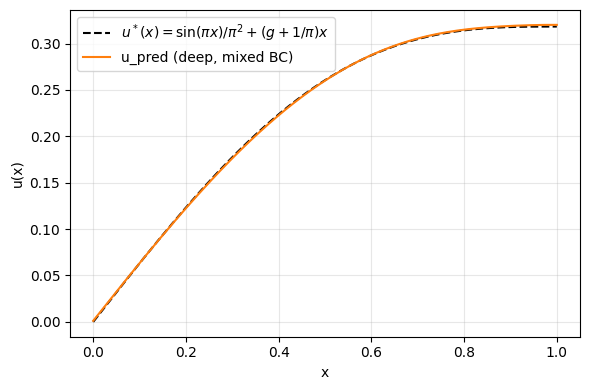

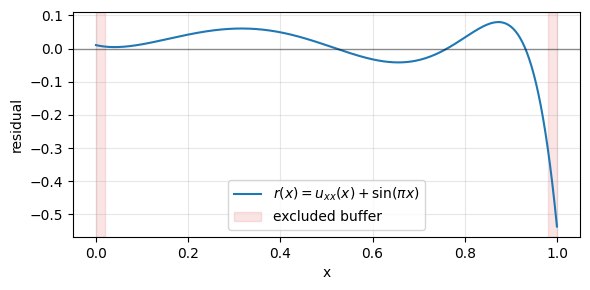

In [131]:
# Deep-model PLOT + METRICS (standalone)
x_grid = np.linspace(0.0, 1.0, 401)
x_in = np.clip(x_grid, 1e-6, 1.0 - 1e-6)
batch = x_in.shape[0]

n_modes = model_neu_sin_deep.layers[0].input_size
X0 = np.zeros((n_modes, batch), dtype=np.complex128)
X0[0, :] = x_in
if n_modes > 1:
    X0[1:, :] = 1.0
dX0 = np.zeros_like(X0); dX0[0, :] = 1.0
d2X0 = np.zeros_like(X0)

XL, dXL, d2XL = forward_pass_derivatives(model_neu_sin_deep, X0, dX0, d2X0)
u_pred, u_x_pred, u_xx_pred, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)

u_true = u_true_sinpi_mixed(x_grid, g=g_neu_sin_deep)
l2 = float(np.sqrt(np.mean((u_pred - u_true) ** 2)))
bc_dir_err = float(abs(u_pred[0]))
ux_1m = float(u_x_pred[-1])
neu_err = float(abs(ux_1m - g_neu_sin_deep))

r = u_xx_pred + f_sinpi_mixed(x_in)
r_rms = float(np.sqrt(np.mean(r ** 2)))
r_max = float(np.max(np.abs(r)))
buffer = 0.02
mask_int = (x_grid >= buffer) & (x_grid <= 1.0 - buffer)
r_rms_int = float(np.sqrt(np.mean(r[mask_int] ** 2)))
r_max_int = float(np.max(np.abs(r[mask_int])))

print('DEEP model metrics')
print('  Dirichlet error |u(0)|:', bc_dir_err)
print('  Neumann error |u_x(1-)-g|:', neu_err, '  (u_x(1-)≈', ux_1m, ')')
print('  L2 error (grid):', l2)
print('  Residual RMS (full):', r_rms, '  max:', r_max)
print(f'  Residual RMS (interior |x-0|>{buffer}):', r_rms_int, '  max:', r_max_int)

plt.figure(figsize=(6,4))
plt.plot(x_grid, u_true, 'k--', label=r'$u^*(x)=\sin(\pi x)/\pi^2 + (g+1/\pi)x$')
plt.plot(x_grid, u_pred, 'C1', label='u_pred (deep, mixed BC)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,3))
plt.plot(x_in, r, lw=1.5, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
plt.axhline(0.0, color='k', lw=1, alpha=0.4)
plt.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
plt.axvspan(1.0-buffer, 1.0, color='C3', alpha=0.12)
plt.xlabel('x'); plt.ylabel('residual')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout(); plt.show()

In [132]:
# --- Circuit info only (mixed BC, sin forcing, DEEP): architecture, modes, encoding ---
import numpy as np

print('=== CIRCUIT / MODEL INFO (mixed BC, sin forcing, DEEP) ===')
if 'model_neu_sin_deep' not in globals():
    raise RuntimeError('No `model_neu_sin_deep` found in globals(). Run the deep mixed-BC+sin training cell first.')

layers = list(getattr(model_neu_sin_deep, 'layers', []))
print('Model type:', type(model_neu_sin_deep))
print('Number of layers:', len(layers))

# Number of modes/ports
if len(layers) > 0 and hasattr(layers[0], 'input_size'):
    n_modes = int(layers[0].input_size)
else:
    n_modes = None
print('Number of modes (N):', n_modes)

print('\nLayers:')
for i, layer in enumerate(layers):
    layer_name = layer.__class__.__name__
    desc = [f'[{i}] {layer_name}']
    if hasattr(layer, 'input_size'):
        desc.append(f"in={getattr(layer, 'input_size')}")
    if hasattr(layer, 'output_size'):
        desc.append(f"out={getattr(layer, 'output_size')}")
    if hasattr(layer, 'mesh'):
        mesh = getattr(layer, 'mesh')
        desc.append(f"mesh={mesh.__class__.__name__}")
        if hasattr(mesh, 'all_tunable_components'):
            cmpts = list(mesh.all_tunable_components())
            dof_total = int(sum(int(getattr(c, 'dof', 0)) for c in cmpts))
            desc.append(f"tunable_components={len(cmpts)}")
            desc.append(f"total_dof={dof_total}")
    print('  ' + '  |  '.join(desc))

print('\n=== RUN PARAMETERS (from current globals) ===')
def _maybe_deep(name):
    return globals()[name] if name in globals() else None

print('Deep mixed BC (sin) params:')
print('  init_seed_deep =', _maybe_deep('init_seed_deep'))
print('  train_seed_deep =', _maybe_deep('train_seed_deep'))
print('  g_neu_sin_deep =', _maybe_deep('g_neu_sin_deep'))
print('  epochs (len(losses_neu_sin_deep)) =', len(losses_neu_sin_deep) if 'losses_neu_sin_deep' in globals() else None)

print('\n=== INPUT ENCODING (as implemented) ===')
print('Using n_modes =', n_modes)
print('X0 construction:')
print('  X0 = zeros((n_modes, batch), complex128)')
print('  X0[0, :] = x')
if n_modes is None:
    print('  X0[1:, :] = 1.0   (cannot confirm n_modes>1 because n_modes is None)')
elif n_modes > 1:
    print('  X0[1:, :] = 1.0')
else:
    print('  (n_modes==1) => no X0[1:, :] rows exist')

print('dX0 construction:')
print('  dX0 = zeros_like(X0)')
print('  dX0[0, :] = 1.0')
print('d2X0 construction:')
print('  d2X0 = zeros_like(X0)')


=== CIRCUIT / MODEL INFO (mixed BC, sin forcing, DEEP) ===
Model type: <class 'neuroptica.models.Sequential'>
Number of layers: 8
Number of modes (N): 3

Layers:
  [0] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [1] Activation  |  in=3  |  out=3
  [2] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [3] Activation  |  in=3  |  out=3
  [4] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [5] Activation  |  in=3  |  out=3
  [6] ClementsLayer  |  in=3  |  out=3  |  mesh=OpticalMesh  |  tunable_components=6  |  total_dof=9
  [7] Activation  |  in=3  |  out=3

=== RUN PARAMETERS (from current globals) ===
Deep mixed BC (sin) params:
  init_seed_deep = 0
  train_seed_deep = 1
  g_neu_sin_deep = 0.0
  epochs (len(losses_neu_sin_deep)) = 7500

=== INPUT ENCODING (as implemented) ===
Using n_modes = 3
X0 construction:
  X0 = zeros((n_modes, batch),

epoch 200/3750  loss=-5.707686e-02
epoch 400/3750  loss=-6.598553e-02
epoch 600/3750  loss=-6.272296e-02
epoch 800/3750  loss=-8.117880e-02
epoch 1000/3750  loss=-7.987349e-02
epoch 1200/3750  loss=-7.226030e-02
epoch 1400/3750  loss=-6.101577e-02
epoch 1600/3750  loss=-8.766164e-02
epoch 1800/3750  loss=-2.767997e-02
epoch 2000/3750  loss=-8.471632e-02
epoch 2200/3750  loss=-6.353597e-02
epoch 2400/3750  loss=-5.666941e-02
epoch 2600/3750  loss=-8.375330e-02
epoch 2800/3750  loss=-6.326357e-02
epoch 3000/3750  loss=-8.614899e-02
epoch 3200/3750  loss=-6.931551e-02
epoch 3400/3750  loss=-7.807884e-02
epoch 3600/3750  loss=-6.157089e-02
Mixed BC (sin, deep) snapshot iterations: {'first': 1, 'mid': 3750, 'final': 7500}
Final loss (mixed BC, sin, deep): -0.09504013937961689


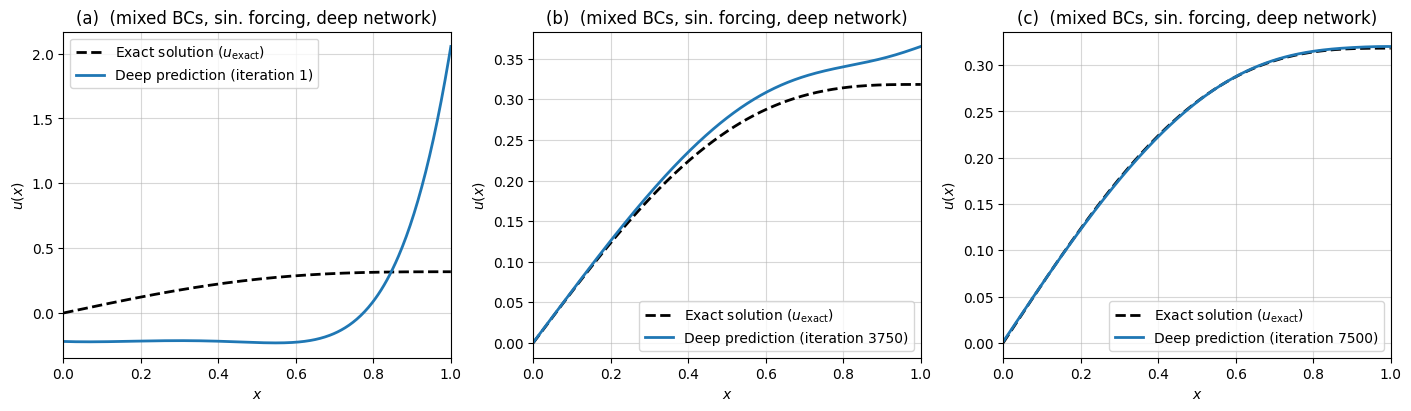

In [133]:
# --- Paper-style figure (mixed BC, sin forcing, DEEP): predictions at 1 / mid / final (solutions only) ---
if 'f_sinpi_mixed' not in globals() or 'u_true_sinpi_mixed' not in globals():
    raise RuntimeError('Run the mixed-BC+sin section above first (defines f_sinpi_mixed/u_true_sinpi_mixed).')
if 'build_photonic_model_deep' not in globals():
    raise RuntimeError('Expected build_photonic_model_deep to exist (defined in deep training cell).')
if 'fit_unsupervised_insitu_adam_fx_neumann1' not in globals():
    raise RuntimeError('Expected fit_unsupervised_insitu_adam_fx_neumann1 to exist (defined earlier in the notebook).')

def _style_axes_paper_deep(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

# Pull hyperparams from the deep training/diagnostics cell (authoritative)
required = ['init_seed_deep', 'train_seed_deep', 'N_neu_sin_deep', 'depth_neu_sin_deep', 'batch_size_neu_sin_deep', 'step_size_neu_sin_deep', 'lambda_dirichlet_neu_sin_deep', 'losses_neu_sin_deep']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing deep training variables for mixed-BC+sin: ' + ', '.join(missing) + '. Run the deep training+diagnostics cell first.')
init_seed_neu_sin_deep = int(init_seed_deep)
train_seed_neu_sin_deep = int(train_seed_deep)
g_neu_sin_deep_val = g_neu_sin_deep if 'g_neu_sin_deep' in globals() else (g_neu_sin if 'g_neu_sin' in globals() else 0.0)
N_neu_sin_deep_val = int(N_neu_sin_deep)
depth_neu_sin_deep_val = int(depth_neu_sin_deep)
batch_size_neu_sin_deep = int(batch_size_neu_sin_deep)
step_size_neu_sin_deep = float(step_size_neu_sin_deep)
lambda_dirichlet_neu_sin_deep = float(lambda_dirichlet_neu_sin_deep)

epochs_final_neu_sin_deep = len(losses_neu_sin_deep)
epoch_first_neu_sin_deep = 0
epoch_mid_neu_sin_deep = max(0, (epochs_final_neu_sin_deep // 2) - 1)
epoch_final_neu_sin_deep = epochs_final_neu_sin_deep - 1

x_plot_sin_deep = np.linspace(0.0, 1.0, 401)
x_plot_in_sin_deep = np.clip(x_plot_sin_deep, 1e-6, 1.0 - 1e-6)
u_exact_sin_deep = u_true_sinpi_mixed(x_plot_sin_deep, g=float(g_neu_sin_deep_val))

def _eval_u_on_grid_neu_sin_deep(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def _train_model_neu_sin_deep_for_epochs(epochs: int):
    model_tmp = build_photonic_model_deep(N=int(N_neu_sin_deep_val), depth=int(depth_neu_sin_deep_val), seed=int(init_seed_neu_sin_deep))
    losses_tmp = fit_unsupervised_insitu_adam_fx_neumann1(
        model_tmp,
        f_fn=f_sinpi_mixed,
        g_neumann=float(g_neu_sin_deep_val),
        epochs=int(epochs),
        batch_size=int(batch_size_neu_sin_deep),
        step_size=float(step_size_neu_sin_deep),
        seed=int(train_seed_neu_sin_deep),
        lambda_dirichlet=float(lambda_dirichlet_neu_sin_deep),
    )
    return model_tmp, losses_tmp

# Reuse existing trained model as final snapshot when possible
if 'model_neu_sin_deep' in globals() and hasattr(losses_neu_sin_deep, '__len__') and len(losses_neu_sin_deep) >= (epoch_final_neu_sin_deep + 1):
    model_final_neu_sin_deep = model_neu_sin_deep
    losses_final_neu_sin_deep = losses_neu_sin_deep
else:
    model_final_neu_sin_deep, losses_final_neu_sin_deep = _train_model_neu_sin_deep_for_epochs(epoch_final_neu_sin_deep + 1)

# Retrain deterministically for first/mid snapshots
model_first_neu_sin_deep, _ = _train_model_neu_sin_deep_for_epochs(epoch_first_neu_sin_deep + 1)
model_mid_neu_sin_deep, _ = _train_model_neu_sin_deep_for_epochs(epoch_mid_neu_sin_deep + 1)

u_pred_first_sin_deep = _eval_u_on_grid_neu_sin_deep(model_first_neu_sin_deep, x_plot_in_sin_deep)
u_pred_mid_sin_deep = _eval_u_on_grid_neu_sin_deep(model_mid_neu_sin_deep, x_plot_in_sin_deep)
u_pred_final_sin_deep = _eval_u_on_grid_neu_sin_deep(model_final_neu_sin_deep, x_plot_in_sin_deep)

print('Mixed BC (sin, deep) snapshot iterations:', {'first': epoch_first_neu_sin_deep + 1, 'mid': epoch_mid_neu_sin_deep + 1, 'final': epoch_final_neu_sin_deep + 1})
print('Final loss (mixed BC, sin, deep):', float(losses_final_neu_sin_deep[-1]) if isinstance(losses_final_neu_sin_deep, list) and len(losses_final_neu_sin_deep) else None)

fig_neu_sin_deep_sol, (ax_first, ax_mid, ax_final) = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

def _plot_panel_deep(ax, u_pred, it_number, title):
    ax.plot(x_plot_sin_deep, u_exact_sin_deep, 'k--', linewidth=2.0, label=r'Exact solution ($u_{\mathrm{exact}}$)')
    ax.plot(x_plot_sin_deep, u_pred, color='C0', linewidth=2.0, label=f'Deep prediction (iteration {it_number})')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$u(x)$')
    ax.set_title(title + r'  (mixed BCs, sin. forcing, deep network)')
    _style_axes_paper_deep(ax)
    ax.legend(frameon=True)

_plot_panel_deep(ax_first, u_pred_first_sin_deep, epoch_first_neu_sin_deep + 1, '(a)')
_plot_panel_deep(ax_mid, u_pred_mid_sin_deep, epoch_mid_neu_sin_deep + 1, '(b)')
_plot_panel_deep(ax_final, u_pred_final_sin_deep, epoch_final_neu_sin_deep + 1, '(c)')

plt.show()


In [134]:
# --- Save paper-ready mixed-BC (sin forcing, DEEP) solutions figure ---
import os

if 'fig_neu_sin_deep_sol' not in globals():
    raise RuntimeError('Run the deep mixed-BC (sin) solutions plotting cell first so `fig_neu_sin_deep_sol` exists.')

out_name_mixed_sin_deep_sol = 'pde1d_mixedBC_sin_deep_solutions.pdf'
fig_neu_sin_deep_sol.savefig(out_name_mixed_sin_deep_sol, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_deep_sol))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_deep_solutions.pdf


Neumann check (deep, at x=1-eps): u_x(1-)≈ -0.005068752841313616  target g= 0.0  |error|= 0.005068752841313616


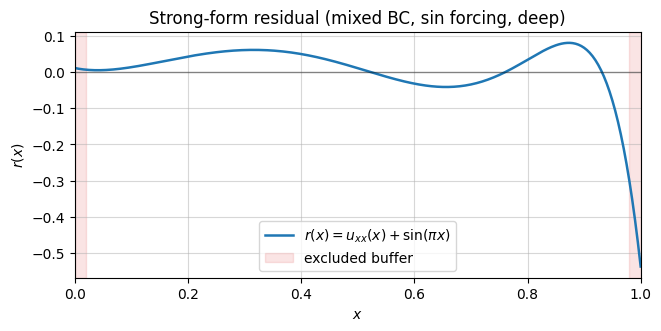

In [135]:
# --- Paper-style figure (mixed BC, sin forcing, DEEP): strong-form residual + Neumann check ---
if 'model_neu_sin_deep' not in globals():
    raise RuntimeError('Run the deep mixed-BC+sin training cell first so `model_neu_sin_deep` exists.')

def _style_axes_paper_deep(ax):
    ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
    ax.set_xlim(0.0, 1.0)

g_neu_sin_deep_val = g_neu_sin_deep if 'g_neu_sin_deep' in globals() else (g_neu_sin if 'g_neu_sin' in globals() else 0.0)

x_grid_res_deep = np.linspace(0.0, 1.0, 401)
x_in_res_deep = np.clip(x_grid_res_deep, 1e-6, 1.0 - 1e-6)
batch_res_deep = x_in_res_deep.shape[0]
n_modes_res_deep = model_neu_sin_deep.layers[0].input_size
X0_res_deep = np.zeros((n_modes_res_deep, batch_res_deep), dtype=np.complex128)
X0_res_deep[0, :] = x_in_res_deep
if n_modes_res_deep > 1:
    X0_res_deep[1:, :] = 1.0
dX0_res_deep = np.zeros_like(X0_res_deep)
dX0_res_deep[0, :] = 1.0
d2X0_res_deep = np.zeros_like(X0_res_deep)

XL_res_deep, dXL_res_deep, d2XL_res_deep = forward_pass_derivatives(model_neu_sin_deep, X0_res_deep, dX0_res_deep, d2X0_res_deep)
_, u_x_res_deep, u_xx_res_deep, _ = linear_readout(x_in_res_deep, XL_res_deep, dXL_res_deep, d2XL_res_deep, a=None, b=0.0)

r_neu_sin_deep = np.real(u_xx_res_deep) + np.asarray(f_sinpi_mixed(x_in_res_deep), dtype=np.float64)
ux_1m_deep = float(np.real(u_x_res_deep[-1]))
neu_err_deep = float(abs(ux_1m_deep - float(g_neu_sin_deep_val)))
print('Neumann check (deep, at x=1-eps): u_x(1-)≈', ux_1m_deep, ' target g=', float(g_neu_sin_deep_val), ' |error|=', neu_err_deep)

buffer = 0.02
fig_neu_sin_deep_res, ax = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(x_in_res_deep, r_neu_sin_deep, linewidth=1.8, label=r'$r(x)=u_{xx}(x)+\sin(\pi x)$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.4)
ax.axvspan(0.0, buffer, color='C3', alpha=0.12, label='excluded buffer')
ax.axvspan(1.0 - buffer, 1.0, color='C3', alpha=0.12)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$r(x)$')
ax.set_title('Strong-form residual (mixed BC, sin forcing, deep)')
_style_axes_paper_deep(ax)
ax.legend(frameon=True, loc='best')
plt.show()


In [136]:
# --- Save paper-ready mixed-BC (sin forcing, DEEP) residual figure ---
import os

if 'fig_neu_sin_deep_res' not in globals():
    raise RuntimeError('Run the deep mixed-BC (sin) residual plotting cell first so `fig_neu_sin_deep_res` exists.')

out_name_mixed_sin_deep_res = 'pde1d_mixedBC_sin_deep_residual.pdf'
fig_neu_sin_deep_res.savefig(out_name_mixed_sin_deep_res, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_deep_res))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_deep_residual.pdf


In [137]:
# --- Extra diagnostics (mixed BC, sin forcing, DEEP): relative L2 error per iteration ---
# NOTE: This retrains from scratch (same init/seed) to get the per-iteration curve.
# It can take a while because it evaluates u(x) during training.

import numpy as np
from neuroptica.components import MZI, PhaseShifter
from neuroptica.layers import OpticalMeshNetworkLayer

if 'build_photonic_model_deep' not in globals():
    raise RuntimeError('Expected `build_photonic_model_deep` from the deep training cell.')
if 'build_dloss_star_fx_neumann1' not in globals():
    raise RuntimeError('Expected `build_dloss_star_fx_neumann1` to exist (defined earlier).')
if 'u_true_sinpi_mixed' not in globals():
    raise RuntimeError('Expected `u_true_sinpi_mixed` to exist (defined in the mixed-BC sin section).')
if 'f_sinpi_mixed' not in globals():
    raise RuntimeError('Expected `f_sinpi_mixed` to exist (defined in the mixed-BC sin section).')
if 'forward_pass_derivatives' not in globals() or 'linear_readout' not in globals():
    raise RuntimeError('Expected `forward_pass_derivatives` and `linear_readout` to exist (defined earlier).')

n_eval_neu_deep = 101
compute_every_neu_sin_deep = 20  # set to 1 for every iteration

# Pull hyperparams from the canonical globals set by the deep training+diagnostics cell (authoritative)
required = ['init_seed_deep', 'train_seed_deep', 'N_neu_sin_deep', 'depth_neu_sin_deep', 'epochs_neu_sin_deep', 'batch_size_neu_sin_deep', 'step_size_neu_sin_deep', 'lambda_dirichlet_neu_sin_deep']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError('Missing deep training variables for mixed-BC+sin diagnostics: ' + ', '.join(missing) + '. Run the deep training+diagnostics cell first.')

epochs_neu_sin_deep_err = int(epochs_neu_sin_deep)
init_seed_neu_sin_deep = int(init_seed_deep)
train_seed_neu_sin_deep = int(train_seed_deep)
g_neu_sin_deep_val = g_neu_sin_deep if 'g_neu_sin_deep' in globals() else (g_neu_sin if 'g_neu_sin' in globals() else 0.0)
N_neu_sin_deep_val = int(N_neu_sin_deep)
depth_neu_sin_deep_val = int(depth_neu_sin_deep)
batch_size_neu_sin_deep = int(batch_size_neu_sin_deep)
step_size_neu_sin_deep = float(step_size_neu_sin_deep)
lambda_dirichlet_neu_sin_deep = float(lambda_dirichlet_neu_sin_deep)

x_err_neu_sin_deep = np.linspace(0.0, 1.0, n_eval_neu_deep)
x_err_in_neu_sin_deep = np.clip(x_err_neu_sin_deep, 1e-6, 1.0 - 1e-6)
u_exact_err_neu_sin_deep = u_true_sinpi_mixed(x_err_neu_sin_deep, g=float(g_neu_sin_deep_val))
den_neu_sin_deep = float(np.sqrt(np.mean(u_exact_err_neu_sin_deep**2)))
den_neu_sin_deep = den_neu_sin_deep if den_neu_sin_deep > 0 else 1.0

def _eval_u_real_neu_sin_deep(model_eval, x_in):
    n_modes = model_eval.layers[0].input_size
    batch = x_in.shape[0]
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = x_in
    if n_modes > 1:
        X0[1:, :] = 1.0
    dX0 = np.zeros_like(X0)
    dX0[0, :] = 1.0
    d2X0 = np.zeros_like(X0)
    XL, dXL, d2XL = forward_pass_derivatives(model_eval, X0, dX0, d2X0)
    u_pred_grid, _, _, _ = linear_readout(x_in, XL, dXL, d2XL, a=None, b=0.0)
    return np.real(u_pred_grid)

def train_neu_sin_deep_with_l2_curve():
    rng = np.random.default_rng(int(train_seed_neu_sin_deep))
    np.random.seed(int(init_seed_neu_sin_deep))
    model_err_neu_sin_deep = build_photonic_model_deep(N=int(N_neu_sin_deep_val), depth=int(depth_neu_sin_deep_val), seed=int(init_seed_neu_sin_deep))
    m = {}
    v = {}
    t = 0
    for layer in model_err_neu_sin_deep.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    losses_signed_neu_sin_deep = []
    iters_neu_sin_deep = []
    rel_l2_neu_sin_deep = []

    n_modes = model_err_neu_sin_deep.layers[0].input_size
    for epoch in range(int(epochs_neu_sin_deep_err)):
        t += 1
        x_int = rng.random(int(batch_size_neu_sin_deep))
        x_int = np.clip(x_int, 1e-6, 1.0 - 1e-6)

        # boundary samples (Dirichlet at 0, Neumann at 1)
        x_dir = np.array([0.0], dtype=np.float64)
        x_neu = np.array([1.0], dtype=np.float64)
        x = np.concatenate([x_int, x_dir, x_neu], axis=0)
        is_dir = np.zeros((x.shape[0],), dtype=bool)
        is_neu = np.zeros((x.shape[0],), dtype=bool)
        is_dir[-2] = True
        is_neu[-1] = True

        batch_total = x.shape[0]
        X0 = np.zeros((n_modes, batch_total), dtype=np.complex128)
        X0[0, :] = x
        if n_modes > 1:
            X0[1:, :] = 1.0
        dX0 = np.zeros_like(X0)
        dX0[0, :] = 1.0
        d2X0 = np.zeros_like(X0)

        _ = model_err_neu_sin_deep.forward_pass(X0)
        XL, dXL, d2XL = forward_pass_derivatives(model_err_neu_sin_deep, X0, dX0, d2X0)
        loss, d_loss_star = build_dloss_star_fx_neumann1(
            x, XL, dXL, d2XL,
            f_fn=f_sinpi_mixed,
            g_neumann=float(g_neu_sin_deep_val),
            a=None, b=0.0,
            is_dirichlet=is_dir,
            is_neumann=is_neu,
            lambda_dirichlet=float(lambda_dirichlet_neu_sin_deep),
        )
        losses_signed_neu_sin_deep.append(float(loss))

        deltas = model_err_neu_sin_deep.backward_pass(d_loss_star)
        delta_prev = d_loss_star
        for layer in reversed(model_err_neu_sin_deep.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(layer.input_prev, delta_prev)
                for cmpt, g_arr in gradients.items():
                    g = np.mean(g_arr, axis=-1)
                    m[cmpt] = 0.9 * m[cmpt] + (1 - 0.9) * g
                    v[cmpt] = 0.99 * v[cmpt] + (1 - 0.99) * (g ** 2)
                    mhat = m[cmpt] / (1 - 0.9 ** t)
                    vhat = v[cmpt] / (1 - 0.99 ** t)
                    step = -float(step_size_neu_sin_deep) * mhat / (np.sqrt(vhat) + 1e-8)
                    if isinstance(cmpt, PhaseShifter):
                        cmpt.phi += step[0]
                    elif isinstance(cmpt, MZI):
                        dtheta, dphi = step
                        cmpt.theta += dtheta
                        cmpt.phi += dphi
            delta_prev = deltas[layer.__name__]

        if (epoch % int(compute_every_neu_sin_deep)) == 0:
            u_pred_err = _eval_u_real_neu_sin_deep(model_err_neu_sin_deep, x_err_in_neu_sin_deep)
            num = float(np.sqrt(np.mean((u_pred_err - u_exact_err_neu_sin_deep) ** 2)))
            iters_neu_sin_deep.append(epoch + 1)
            rel_l2_neu_sin_deep.append(num / den_neu_sin_deep)

        if (epoch + 1) % 500 == 0:
            last = rel_l2_neu_sin_deep[-1] if len(rel_l2_neu_sin_deep) else float('nan')
            print(f"iter {epoch+1}/{int(epochs_neu_sin_deep_err)}  loss={loss:+.3e}  relL2(last)={last:.3e}")

    return model_err_neu_sin_deep, losses_signed_neu_sin_deep, np.array(iters_neu_sin_deep), np.array(rel_l2_neu_sin_deep)

model_err_neu_sin_deep, losses_signed_neu_sin_deep, iters_neu_sin_deep, rel_l2_neu_sin_deep = train_neu_sin_deep_with_l2_curve()
print('Done. Final signed loss:', losses_signed_neu_sin_deep[-1], ' Final rel L2:', rel_l2_neu_sin_deep[-1])


iter 500/7500  loss=-4.553e-02  relL2(last)=1.244e-01
iter 1000/7500  loss=-7.987e-02  relL2(last)=2.756e-01
iter 1500/7500  loss=-9.587e-02  relL2(last)=9.437e-02
iter 2000/7500  loss=-8.472e-02  relL2(last)=1.622e-01
iter 2500/7500  loss=-7.030e-02  relL2(last)=1.208e-01
iter 3000/7500  loss=-8.615e-02  relL2(last)=3.035e-02
iter 3500/7500  loss=-4.327e-02  relL2(last)=3.005e-02
iter 4000/7500  loss=-7.336e-02  relL2(last)=1.279e-01
iter 4500/7500  loss=-7.145e-02  relL2(last)=4.047e-02
iter 5000/7500  loss=-6.688e-02  relL2(last)=4.398e-02
iter 5500/7500  loss=-7.102e-02  relL2(last)=1.546e-02
iter 6000/7500  loss=-5.592e-02  relL2(last)=1.108e-02
iter 6500/7500  loss=-6.204e-02  relL2(last)=3.848e-02
iter 7000/7500  loss=-5.414e-02  relL2(last)=3.281e-02
iter 7500/7500  loss=-9.504e-02  relL2(last)=1.873e-02
Done. Final signed loss: -0.09504013937961689  Final rel L2: 0.018731150853136612


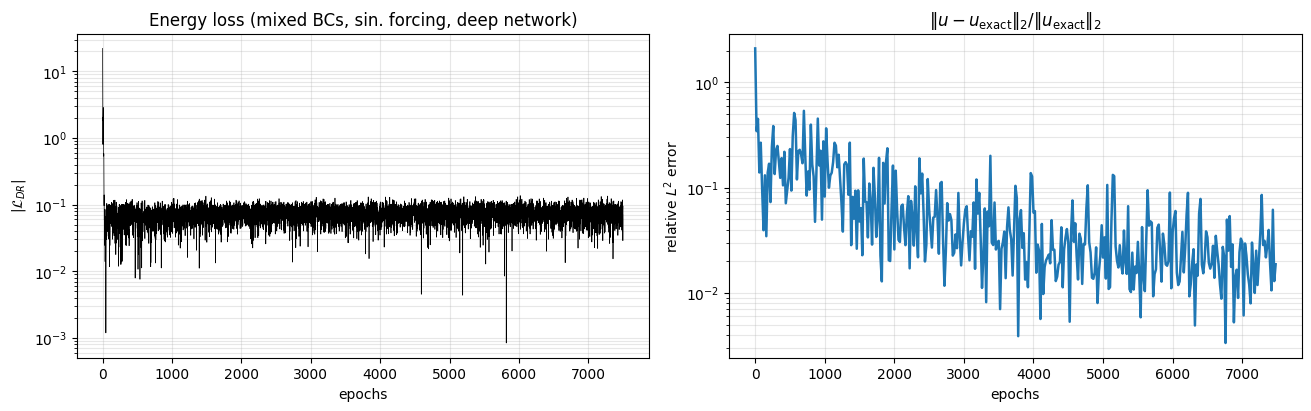

In [142]:
# --- Paper-style losses + relative L2 error (mixed BC, sin forcing, DEEP) ---
# If you ran the per-iteration diagnostics cell, this will plot both |loss| and relative L2.
# Otherwise it will plot only |loss| from `losses_neu_sin_deep`.

if 'losses_signed_neu_sin_deep' in globals():
    loss_neu_sin_deep_arr = np.asarray(losses_signed_neu_sin_deep, dtype=float)
elif 'losses_neu_sin_deep' in globals():
    loss_neu_sin_deep_arr = np.asarray(losses_neu_sin_deep, dtype=float)
else:
    raise RuntimeError('No deep losses found. Run the deep mixed-BC+sin training cell first.')

abs_loss_neu_sin_deep = np.abs(loss_neu_sin_deep_arr)
epochs_neu_sin_deep = np.arange(1, abs_loss_neu_sin_deep.size + 1)

has_rel_neu_sin_deep = ('rel_l2_neu_sin_deep' in globals()) and ('iters_neu_sin_deep' in globals())

if has_rel_neu_sin_deep:
    fig_neu_sin_deep_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
else:
    fig_neu_sin_deep_loss, ax1 = plt.subplots(1, 1, figsize=(6.5, 3.2), constrained_layout=True)

# Absolute energy loss
ax1.plot(epochs_neu_sin_deep, abs_loss_neu_sin_deep, color='k', linewidth=0.5)
ax1.set_xlabel('epochs')
ax1.set_ylabel(r'$|\mathcal{L}_{DR}|$')
ax1.set_yscale('log')
ax1.set_title('Energy loss (mixed BCs, sin. forcing, deep network)')
ax1.grid(True, which='both', alpha=0.3)

if has_rel_neu_sin_deep:
    ax2.plot(iters_neu_sin_deep, rel_l2_neu_sin_deep, color='C0', linewidth=1.8)
    ax2.set_xlabel('epochs')
    ax2.set_ylabel(r'relative $L^2$ error')
    ax2.set_yscale('log')
    ax2.set_title(r'$\|u-u_{\mathrm{exact}}\|_2 / \|u_{\mathrm{exact}}\|_2$')
    ax2.grid(True, which='both', alpha=0.3)

plt.show()


In [143]:
# --- Save paper-ready mixed-BC (sin forcing, DEEP) losses figure ---
import os

if 'fig_neu_sin_deep_loss' not in globals():
    raise RuntimeError('Run the deep mixed-BC (sin) losses plotting cell first so `fig_neu_sin_deep_loss` exists.')

out_name_mixed_sin_deep_loss = 'pde1d_mixedBC_sin_deep_losses.pdf'
fig_neu_sin_deep_loss.savefig(out_name_mixed_sin_deep_loss, bbox_inches='tight')
print('Saved:', os.path.abspath(out_name_mixed_sin_deep_loss))


Saved: \\wsl.localhost\Ubuntu\home\yosef\mulproj\pde1d_mixedBC_sin_deep_losses.pdf


## 2D Poisson equation via Deep Ritz (square domain; manufactured solution)

We consider a standard 2D Poisson problem on the square domain $\Omega = (-1,1)^2$ with homogeneous Dirichlet boundary conditions:
$$
\begin{cases}
-\Delta u(x,y) = f(x,y), & (x,y)\in\Omega,\\
u(x,y) = 0, & (x,y)\in\partial\Omega.
\end{cases}
$$

### Deep Ritz formulation (Yu & E spirit)

Following the Deep Ritz method (Yu & E, 2017), we approximate the solution by a parametric model $u_\theta$ and minimize the variational energy
$$
\mathcal{J}_{\Omega}(u_\theta)=\int_{\Omega}\left(\tfrac12\,|\nabla u_\theta|^2 - f\,u_\theta\right)\,dx,
$$
where $|\nabla u_\theta|^2 = (\partial_x u_\theta)^2 + (\partial_y u_\theta)^2$ and $-\Delta u_\theta = -(\partial_{xx}u_\theta + \partial_{yy}u_\theta)$ are treated *symmetrically* in $x$ and $y$.

The Dirichlet condition is enforced weakly via a quadratic penalty:
$$
\mathcal{J}(u_\theta)=\mathcal{J}_{\Omega}(u_\theta) + \frac{\lambda_{\mathrm{bc}}}{2}\int_{\partial\Omega} u_\theta^2\,ds.
$$

### Manufactured smooth test case

To enable exact, smooth diagnostics (and to avoid geometric/singularity effects), we use the manufactured solution
$$
u_{\mathrm{exact}}(x,y)=\sin(\pi x)\sin(\pi y),
$$
which satisfies $u_{\mathrm{exact}}=0$ on $\partial\Omega$, and yields the forcing
$$
f(x,y)=2\pi^2\sin(\pi x)\sin(\pi y).
$$

### Diagnostics (Yu & E–style)

We track the same convergence quantities typically reported for Deep Ritz Poisson benchmarks:
- training objective value versus epochs ($\mathcal{J}$),
- relative $L^2(\Omega)$ error $\|u_\theta-u_{\mathrm{exact}}\|_{L^2}/\|u_{\mathrm{exact}}\|_{L^2}$,
- $L^2(\Omega)$ norm of the strong-form residual $\|-\Delta u_\theta - f\|_{L^2(\Omega)}$,
- boundary violation in $L^2(\partial\Omega)$ and $L^\infty(\partial\Omega)$.

All derivatives are obtained by analytic propagation through the photonic model (no finite differences).

In [63]:
# 2D Poisson: diagnostics utilities (NumPy + matplotlib only)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def l2_norm_trapz_2d(z: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Approximate ||z||_{L^2(Ω)} via sqrt(∫∫ z^2 dx dy) on a tensor grid (trapz).
    z is assumed sampled on the full tensor grid defined by 1D arrays x and y.
    """
    z = np.asarray(z, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    ix = np.trapz(z * z, x, axis=1)
    ixy = np.trapz(ix, y, axis=0)
    return float(np.sqrt(ixy))

def boundary_rmse(u_b: np.ndarray) -> float:
    """RMSE on a boundary sample set (proxy for L^2(∂Ω) up to sampling/measure constants)."""
    u_b = np.asarray(u_b, dtype=np.float64).reshape(-1)
    return float(np.sqrt(np.mean(u_b * u_b)))

def boundary_linf(u_b: np.ndarray) -> float:
    u_b = np.asarray(u_b, dtype=np.float64).reshape(-1)
    return float(np.max(np.abs(u_b)))

In [64]:
# 2D helpers (minimal; used only by the 2D experiment below)
import numpy as np
import neuroptica as neu
import neuroptica.nonlinearities as nl

def build_photonic_model_2d(
    N: int = 12,
    depth: int = 2,
    seed: int = 0,
    activation: str = 'square',
) -> neu.Sequential:
    """Photonic model for 2D inputs (x,y,1) embedded into N modes.

    activation options (holomorphic-friendly):
    - 'square': uses ComplexSquared (z^2)
    - 'sigmoid': uses neuroptica.nonlinearities.Sigmoid

    Note: if you change activation, the 2D derivative pass must support it.
    """
    if N < 3:
        raise ValueError('Need N>=3 to embed (x,y,1).')
    np.random.seed(seed)
    layers = []
    act = activation.lower().strip()
    for _ in range(depth):
        layers.append(neu.ClementsLayer(N))
        if act in ('square', 'z2', 'zsquared'):
            layers.append(neu.Activation(ComplexSquared(N)))
        elif act in ('sigmoid', 'σ'):
            layers.append(neu.Activation(nl.Sigmoid(N)))
        else:
            raise ValueError(f"Unsupported activation='{activation}'. Try 'square' or 'sigmoid'.")
    return neu.Sequential(layers)

def make_dense_readout_vector(n_modes: int, seed: int = 0, *, scale: float = 1.0) -> np.ndarray:
    """Fixed dense complex readout vector a (normalized then scaled)."""
    rng = np.random.default_rng(seed)
    phases = rng.uniform(0.0, 2.0 * np.pi, size=n_modes)
    a = np.exp(1j * phases).astype(np.complex128)
    a = (scale * a / (np.linalg.norm(a) + 1e-12)).astype(np.complex128)
    return a

def embed_xy_bias(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    x_scale: float = 1.0,
    y_scale: float = 1.0,
    bias: float = 2.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build (X0, dX0_x, dX0_y) with channels: [x, y, ..., bias].

    Note: bias>1 helps avoid vanishing magnitudes through repeated squaring.
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')
    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    X0[0, :] = float(x_scale) * x
    X0[1, :] = float(y_scale) * y
    X0[-1, :] = float(bias)
    dX0_x = np.zeros_like(X0); dX0_x[0, :] = float(x_scale)
    dX0_y = np.zeros_like(X0); dX0_y[1, :] = float(y_scale)
    return X0, dX0_x, dX0_y

In [65]:
# 2D Poisson (square): Deep Ritz objective + TRIM/Adam training with clear interior/boundary separation
import numpy as np
import neuroptica as neu
import neuroptica.nonlinearities as nl
from neuroptica.components import MZI, PhaseShifter
from neuroptica.layers import OpticalMeshNetworkLayer, Activation, DropMask

PI = float(np.pi)
OMEGA_AREA = 4.0      # (-1,1)^2
OMEGA_PERIM = 8.0     # perimeter of (-1,1)^2

def forward_pass_derivatives_2d(model, X0, dX0, d2X0):
    """2D-only input-derivative propagation through the photonic model.

    This mirrors the 1D helper but supports multiple activation nonlinearities.
    """
    X = X0
    dX = dX0
    d2X = d2X0

    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            W = layer.mesh.get_transfer_matrix()
            X = W @ X
            dX = W @ dX
            d2X = W @ d2X
        elif isinstance(layer, Activation):
            Z = X
            dZ = dX
            d2Z = d2X
            nonlin = layer.nonlinearity

            # ComplexSquared: phi(z)=z^2
            if isinstance(nonlin, ComplexSquared):
                X = Z ** 2
                dX = 2 * Z * dZ
                d2X = 2 * (dZ ** 2) + 2 * Z * d2Z

            # Sigmoid: phi(z)=1/(1+exp(-z))
            elif isinstance(nonlin, nl.Sigmoid):
                X = nonlin.forward_pass(Z)
                dphi = X * (1.0 - X)
                d2phi = dphi * (1.0 - 2.0 * X)
                dX = dphi * dZ
                d2X = d2phi * (dZ ** 2) + dphi * d2Z

            else:
                raise NotImplementedError(f"Activation nonlinearity not supported in 2D derivatives: {type(nonlin)}")

        elif isinstance(layer, DropMask):
            X = layer.forward_pass(X)
            dX = dX[layer.ports]
            d2X = d2X[layer.ports]
        else:
            X = layer.forward_pass(X)
            raise NotImplementedError(f"Layer not handled for 2D input-derivatives: {layer}")
    return X, dX, d2X

# --- Problem definition (manufactured solution) ---
def u_exact_square_sin(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return np.sin(PI * x) * np.sin(PI * y)

def f_square_sin(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return 2.0 * (PI**2) * np.sin(PI * x) * np.sin(PI * y)

# --- Sampling ---
def sample_interior_square(rng: np.random.Generator, n: int) -> tuple[np.ndarray, np.ndarray]:
    x = rng.uniform(-1.0, 1.0, size=n)
    y = rng.uniform(-1.0, 1.0, size=n)
    return x.astype(np.float64), y.astype(np.float64)

def sample_boundary_square(rng: np.random.Generator, n: int) -> tuple[np.ndarray, np.ndarray]:
    """Sample points uniformly on ∂Ω for Ω=(-1,1)^2."""
    edges = rng.integers(0, 4, size=n)  # 0:x=-1, 1:x=1, 2:y=-1, 3:y=1
    t = rng.uniform(-1.0, 1.0, size=n)
    x = np.empty(n, dtype=np.float64)
    y = np.empty(n, dtype=np.float64)
    m = edges == 0
    x[m] = -1.0; y[m] = t[m]
    m = edges == 1
    x[m] = 1.0;  y[m] = t[m]
    m = edges == 2
    y[m] = -1.0; x[m] = t[m]
    m = edges == 3
    y[m] = 1.0;  x[m] = t[m]
    return x, y

# --- Model evaluation (analytic derivatives) ---
def _eval_fields_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star)."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    n_modes = model.layers[0].input_size
    X0, dX0_x, dX0_y = embed_xy_bias(
        x, y, n_modes, x_scale=embed_x_scale, y_scale=embed_y_scale, bias=embed_bias
    )
    d2X0 = np.zeros_like(X0)

    _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=False)
    XL, dXL_x, d2XL_x = forward_pass_derivatives_2d(model, X0, dX0_x, d2X0)
    XL2, dXL_y, d2XL_y = forward_pass_derivatives_2d(model, X0, dX0_y, d2X0)
    if XL2.shape != XL.shape:
        raise RuntimeError('XL mismatch between derivative passes')

    # du_dXL_star is independent of x/y; obtain it once via the existing readout helper.
    dummy = np.zeros((x.size,), dtype=np.float64)
    _, _, _, du_dXL_star = linear_readout(dummy, XL, dXL_x, d2XL_x, a=None, b=0.0, check_shapes=False)
    du_dXL_star = np.asarray(du_dXL_star, dtype=np.complex128)
    return XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star

def eval_u_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    a_readout: np.ndarray,
    cache_fields: bool = True,
    embed_x_scale: float = 0.7,
    embed_y_scale: float = 0.7,
    embed_bias: float = 1.0,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (u, u_x, u_y, u_xx, u_yy) on the provided point set."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    XL, dXL_x, d2XL_x, dXL_y, d2XL_y, _ = _eval_fields_and_derivatives(
        model, x, y, cache_fields=cache_fields,
        embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
    )

    dummy = np.zeros((x.size,), dtype=np.float64)
    u, u_x, u_xx, _ = linear_readout(dummy, XL, dXL_x, d2XL_x, a=a_readout, b=0.0, check_shapes=False)
    _, u_y, u_yy, _ = linear_readout(dummy, XL, dXL_y, d2XL_y, a=a_readout, b=0.0, check_shapes=False)
    return (np.asarray(u, dtype=np.float64),
            np.asarray(u_x, dtype=np.float64),
            np.asarray(u_y, dtype=np.float64),
            np.asarray(u_xx, dtype=np.float64),
            np.asarray(u_yy, dtype=np.float64))

# --- Deep Ritz objective and TRIM source term ---
def deep_ritz_objective_and_trim_source(
    model: neu.Sequential,
    xi: np.ndarray,
    yi: np.ndarray,
    xb: np.ndarray,
    yb: np.ndarray,
    *,
    a_readout: np.ndarray,
    lambda_bc: float,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
    ) -> tuple[dict, np.ndarray]:
    """Compute {J_total,J_int,J_bc} and TRIM source term dJ/dXL* on the concatenated batch.

    Notes (numerical stability):
    - The boundary adjoint injection scales like (|∂Ω| * λ_bc / n_bc) * u on boundary points.
      If λ_bc is large and n_bc is small, this term can dominate and drive stiff/unstable Adam updates.
    """
    xi = np.asarray(xi, dtype=np.float64).reshape(-1)
    yi = np.asarray(yi, dtype=np.float64).reshape(-1)
    xb = np.asarray(xb, dtype=np.float64).reshape(-1)
    yb = np.asarray(yb, dtype=np.float64).reshape(-1)
    if xi.shape != yi.shape:
        raise ValueError('Interior xi/yi shape mismatch')
    if xb.shape != yb.shape:
        raise ValueError('Boundary xb/yb shape mismatch')
    if xi.size == 0:
        raise ValueError('Need at least 1 interior point')

    # Concatenate for a single TRIM backward pass, but keep interior/boundary as explicit slices.
    x = np.concatenate([xi, xb])
    y = np.concatenate([yi, yb])
    n_int = xi.size
    n_bc = xb.size
    idx_int = slice(0, n_int)
    idx_bc = slice(n_int, n_int + n_bc)

    XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star = _eval_fields_and_derivatives(
        model, x, y, cache_fields=cache_fields,
        embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
    )

    dummy = np.zeros((x.size,), dtype=np.float64)
    u, u_x, u_xx, _ = linear_readout(dummy, XL, dXL_x, d2XL_x, a=a_readout, b=0.0, check_shapes=False)
    _, u_y, u_yy, _ = linear_readout(dummy, XL, dXL_y, d2XL_y, a=a_readout, b=0.0, check_shapes=False)
    u = np.asarray(u, dtype=np.float64)
    u_x = np.asarray(u_x, dtype=np.float64)
    u_y = np.asarray(u_y, dtype=np.float64)
    u_xx = np.asarray(u_xx, dtype=np.float64)
    u_yy = np.asarray(u_yy, dtype=np.float64)

    # Interior objective: ∫Ω (1/2 |∇u|^2 - f u) dx ≈ |Ω| * mean(…)
    f_int = f_square_sin(xi, yi)
    grad_sq_int = u_x[idx_int] ** 2 + u_y[idx_int] ** 2
    j_int = OMEGA_AREA * float(np.mean(0.5 * grad_sq_int - f_int * u[idx_int]))

    # Boundary penalty: (λ/2) ∫∂Ω u^2 ds ≈ (λ/2) |∂Ω| * mean(u^2)
    if lambda_bc > 0.0 and n_bc > 0:
        j_bc = 0.5 * float(lambda_bc) * OMEGA_PERIM * float(np.mean(u[idx_bc] ** 2))
    else:
        j_bc = 0.0
    j_total = j_int + j_bc

    # First variation (strong-form) used for TRIM injection.
    # Interior: δJ/δu = -Δu - f, scaled consistently with the Monte Carlo estimate.
    lap_int = (u_xx[idx_int] + u_yy[idx_int]).astype(np.float64)
    res_int = (-(lap_int) - f_int).astype(np.float64)
    d_loss_star = np.zeros_like(XL, dtype=np.complex128)
    d_loss_star[:, idx_int] = (du_dXL_star[:, idx_int] * (OMEGA_AREA * res_int / float(n_int))[None, :]).astype(np.complex128)

    # Boundary: δJ/δu = λ u (penalty), scaled with boundary Monte Carlo estimate.
    if lambda_bc > 0.0 and n_bc > 0:
        u_bc = u[idx_bc].astype(np.float64)
        d_loss_star[:, idx_bc] = (du_dXL_star[:, idx_bc] * (OMEGA_PERIM * (float(lambda_bc) * u_bc) / float(n_bc))[None, :]).astype(np.complex128)

    # Batch diagnostics for numerical auditing (does not change the loss).
    dJ_int_norm = float(np.linalg.norm(d_loss_star[:, idx_int]))
    dJ_bc_norm = float(np.linalg.norm(d_loss_star[:, idx_bc])) if n_bc > 0 else 0.0
    grad_sq_mean = float(np.mean(grad_sq_int))
    grad_sq_max = float(np.max(grad_sq_int))
    res_rms = float(np.sqrt(np.mean(res_int * res_int)))
    u_bc_rms = float(np.sqrt(np.mean(u[idx_bc] ** 2))) if n_bc > 0 else 0.0
    u_bc_max = float(np.max(np.abs(u[idx_bc]))) if n_bc > 0 else 0.0

    return {
        'J_total': float(j_total),
        'J_int': float(j_int),
        'J_bc': float(j_bc),
        'grad_sq_mean': grad_sq_mean,
        'grad_sq_max': grad_sq_max,
        'res_int_rms': res_rms,
        'u_bc_rms': u_bc_rms,
        'u_bc_max': u_bc_max,
        'dJ_int_norm': dJ_int_norm,
        'dJ_bc_norm': dJ_bc_norm,
    }, d_loss_star

# --- Training loop (in-situ Adam on photonic parameters) ---
def fit_insitu_adam_deep_ritz_poisson_2d_square(
    model: neu.Sequential,
    *,
    epochs: int,
    n_interior: int,
    n_boundary: int,
    step_size: float,
    seed: int,
    lambda_bc: float,
    lambda_bc_ramp_epochs: int,
    diag_every: int,
    a_readout: np.ndarray | None = None,
    a_readout_scale: float = 3.0,
    cache_fields: bool = True,
    max_step: float = 0.05,
    embed_x_scale: float = 0.7,
    embed_y_scale: float = 0.7,
    embed_bias: float = 1.0,
    beta1: float = 0.9,
    beta2: float = 0.99,
    epsilon: float = 1e-8,
    global_grad_clip: float | None = None,
    only_interior: bool = False,
    audit_every: int = 50,
    print_every: int = 300,
    test_grid_n: int = 81,
    boundary_eval_n: int = 300,
    ) -> dict:
    """Train Deep Ritz Poisson on Ω=(-1,1)^2 with weak Dirichlet and log Yu&E-style diagnostics.

    Numerical stabilization knobs (do not change the loss):
    - max_step: per-parameter phase update clipping (trust-region surrogate).
    - global_grad_clip: global L2 norm clip on the *raw* per-parameter gradient vectors (before Adam moments).
    - beta1: reduce momentum to prevent boundary-driven oscillations early on.
    - only_interior: diagnostic mode (λ_bc forced to 0 and no boundary sampling).
    """
    rng = np.random.default_rng(seed)
    n_modes = model.layers[0].input_size

    if a_readout is None:
        a_readout = make_dense_readout_vector(n_modes, seed=seed + 999, scale=float(a_readout_scale))
    else:
        a_readout = np.asarray(a_readout, dtype=np.complex128).reshape(-1)
        if a_readout.shape != (n_modes,):
            raise ValueError(f'a_readout must have shape (n_modes,), got {a_readout.shape}, n_modes={n_modes}')

    # Adam state per tunable component
    m: dict = {}
    v: dict = {}
    t = 0
    for layer in model.layers:
        if isinstance(layer, OpticalMeshNetworkLayer):
            for cmpt in layer.mesh.all_tunable_components():
                m[cmpt] = np.zeros(cmpt.dof)
                v[cmpt] = np.zeros(cmpt.dof)

    # Histories
    losses_total = []
    losses_int = []
    losses_bc = []
    diag_epochs = []
    rel_l2_hist = []
    pde_res_l2_hist = []
    bc_l2_hist = []
    bc_linf_hist = []

    # Audit histories (numerical)
    dJ_int_norm_hist = []
    dJ_bc_norm_hist = []
    grad_sq_mean_hist = []
    grad_sq_max_hist = []
    res_int_rms_hist = []
    u_bc_rms_hist = []
    u_bc_max_hist = []
    grad_global_norm_hist = []
    grad_global_scale_hist = []
    update_rms_hist = []
    update_max_hist = []

    # Fixed diagnostic grids
    x_test = np.linspace(-1.0, 1.0, int(test_grid_n))
    y_test = np.linspace(-1.0, 1.0, int(test_grid_n))
    Xg, Yg = np.meshgrid(x_test, y_test, indexing='xy')
    xg = Xg.reshape(-1)
    yg = Yg.reshape(-1)

    tt = np.linspace(-1.0, 1.0, int(boundary_eval_n))
    xb_eval = np.concatenate([-np.ones_like(tt), np.ones_like(tt), tt, tt])
    yb_eval = np.concatenate([tt, tt, -np.ones_like(tt), np.ones_like(tt)])

    for epoch in range(int(epochs)):
        t += 1
        ep = epoch + 1

        if only_interior:
            lambda_eff = 0.0
        else:
            if lambda_bc_ramp_epochs > 0:
                ramp = min(1.0, ep / float(lambda_bc_ramp_epochs))
            else:
                ramp = 1.0
            lambda_eff = float(lambda_bc) * float(ramp)

        xi, yi = sample_interior_square(rng, int(n_interior))
        if only_interior or int(n_boundary) <= 0 or lambda_eff <= 0.0:
            xb = np.empty((0,), dtype=np.float64)
            yb = np.empty((0,), dtype=np.float64)
        else:
            xb, yb = sample_boundary_square(rng, int(n_boundary))

        J, dJ_star = deep_ritz_objective_and_trim_source(
            model, xi, yi, xb, yb,
            a_readout=a_readout, lambda_bc=lambda_eff, cache_fields=cache_fields,
            embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
        )
        losses_total.append(J['J_total'])
        losses_int.append(J['J_int'])
        losses_bc.append(J['J_bc'])

        # --- Numerical audit logging (batch-level) ---
        if (ep % int(audit_every)) == 0 or ep == 1 or ep == int(epochs):
            dJ_int_norm_hist.append(J['dJ_int_norm'])
            dJ_bc_norm_hist.append(J['dJ_bc_norm'])
            grad_sq_mean_hist.append(J['grad_sq_mean'])
            grad_sq_max_hist.append(J['grad_sq_max'])
            res_int_rms_hist.append(J['res_int_rms'])
            u_bc_rms_hist.append(J['u_bc_rms'])
            u_bc_max_hist.append(J['u_bc_max'])

        # TRIM backprop through photonic mesh + Adam update
        deltas = model.backward_pass(dJ_star, cache_fields=cache_fields, use_partial_vectors=False)
        delta_prev = dJ_star

        # Collect raw per-parameter gradients first (so we can do global norm clipping).
        grads_mean: dict = {}
        for layer in reversed(model.layers):
            if isinstance(layer, OpticalMeshNetworkLayer):
                gradients = layer.mesh.compute_gradients(
                    layer.input_prev, delta_prev, cache_fields=cache_fields, use_partial_vectors=False
                )
                for cmpt, g_arr in gradients.items():
                    grads_mean[cmpt] = np.mean(g_arr, axis=-1)
            delta_prev = deltas[layer.__name__]

        # Global gradient norm clipping (raw gradients, before Adam moments).
        if global_grad_clip is not None and len(grads_mean) > 0:
            sq = 0.0
            for g in grads_mean.values():
                gg = np.asarray(g, dtype=np.float64).reshape(-1)
                sq += float(np.sum(gg * gg))
            gnorm = float(np.sqrt(sq))
            if gnorm > float(global_grad_clip) and gnorm > 0.0:
                gscale = float(global_grad_clip) / gnorm
            else:
                gscale = 1.0
        else:
            gnorm = 0.0
            gscale = 1.0

        # Apply Adam + per-parameter step clipping; track update norms (effective step per epoch).
        upd_sq = 0.0
        upd_max = 0.0
        ndof = 0
        for cmpt, g in grads_mean.items():
            g = gscale * np.asarray(g, dtype=np.float64)
            m[cmpt] = beta1 * m[cmpt] + (1.0 - beta1) * g
            v[cmpt] = beta2 * v[cmpt] + (1.0 - beta2) * (g ** 2)
            mhat = m[cmpt] / (1.0 - beta1 ** t)
            vhat = v[cmpt] / (1.0 - beta2 ** t)
            step = -step_size * mhat / (np.sqrt(vhat) + epsilon)
            step = np.clip(step, -max_step, max_step)

            s = np.asarray(step, dtype=np.float64).reshape(-1)
            upd_sq += float(np.sum(s * s))
            upd_max = max(upd_max, float(np.max(np.abs(s))) if s.size else 0.0)
            ndof += int(s.size)

            if isinstance(cmpt, PhaseShifter):
                cmpt.phi += step[0]
            elif isinstance(cmpt, MZI):
                dtheta, dphi = step
                cmpt.theta += dtheta
                cmpt.phi += dphi

        upd_rms = float(np.sqrt(upd_sq / max(1, ndof)))
        if (ep % int(audit_every)) == 0 or ep == 1 or ep == int(epochs):
            grad_global_norm_hist.append(gnorm)
            grad_global_scale_hist.append(gscale)
            update_rms_hist.append(upd_rms)
            update_max_hist.append(float(upd_max))

        # Yu&E-style diagnostics on a fixed grid
        if (ep % int(diag_every)) == 0 or ep == 1 or ep == int(epochs):
            u, _, _, u_xx, u_yy = eval_u_and_derivatives(
                model, xg, yg, a_readout=a_readout, cache_fields=cache_fields,
                embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
            )
            u_grid = u.reshape(Yg.shape)
            u_true = u_exact_square_sin(Xg, Yg)
            r = (-(u_xx + u_yy) - f_square_sin(xg, yg)).reshape(Yg.shape)

            pde_res_l2 = l2_norm_trapz_2d(r, x_test, y_test)
            num = l2_norm_trapz_2d(u_grid - u_true, x_test, y_test)
            den = l2_norm_trapz_2d(u_true, x_test, y_test)
            rel_l2 = float(num / (den + 1e-16))

            u_b, _, _, _, _ = eval_u_and_derivatives(
                model, xb_eval, yb_eval, a_readout=a_readout, cache_fields=cache_fields,
                embed_x_scale=embed_x_scale, embed_y_scale=embed_y_scale, embed_bias=embed_bias
            )
            bc_l2 = boundary_rmse(u_b)
            bc_linf = boundary_linf(u_b)

            diag_epochs.append(ep)
            rel_l2_hist.append(rel_l2)
            pde_res_l2_hist.append(pde_res_l2)
            bc_l2_hist.append(bc_l2)
            bc_linf_hist.append(bc_linf)

        if (ep % int(print_every)) == 0:
            print(
                f"epoch {ep}/{epochs}  J={J['J_total']:.6e}  J_int={J['J_int']:.3e}  J_bc={J['J_bc']:.3e}  (lambda_bc={lambda_eff:.3g})  upd_rms={upd_rms:.2e}  gscale={gscale:.2e}"
            )

    return {
        'losses_total': np.asarray(losses_total, dtype=np.float64),
        'losses_int': np.asarray(losses_int, dtype=np.float64),
        'losses_bc': np.asarray(losses_bc, dtype=np.float64),
        'diag_epochs': np.asarray(diag_epochs, dtype=np.int64),
        'rel_l2': np.asarray(rel_l2_hist, dtype=np.float64),
        'pde_res_l2': np.asarray(pde_res_l2_hist, dtype=np.float64),
        'bc_l2': np.asarray(bc_l2_hist, dtype=np.float64),
        'bc_linf': np.asarray(bc_linf_hist, dtype=np.float64),
        'a_readout': a_readout,
        'lambda_bc': float(lambda_bc),
        'lambda_bc_ramp_epochs': int(lambda_bc_ramp_epochs),
        'embed_x_scale': float(embed_x_scale),
        'embed_y_scale': float(embed_y_scale),
        'embed_bias': float(embed_bias),
        'a_readout_scale': float(a_readout_scale),
        'test_grid_n': int(test_grid_n),
        'boundary_eval_n': int(boundary_eval_n),
        'only_interior': bool(only_interior),
        'global_grad_clip': None if global_grad_clip is None else float(global_grad_clip),
        'audit_every': int(audit_every),
        'audit': {
            'dJ_int_norm': np.asarray(dJ_int_norm_hist, dtype=np.float64),
            'dJ_bc_norm': np.asarray(dJ_bc_norm_hist, dtype=np.float64),
            'grad_sq_mean': np.asarray(grad_sq_mean_hist, dtype=np.float64),
            'grad_sq_max': np.asarray(grad_sq_max_hist, dtype=np.float64),
            'res_int_rms': np.asarray(res_int_rms_hist, dtype=np.float64),
            'u_bc_rms': np.asarray(u_bc_rms_hist, dtype=np.float64),
            'u_bc_max': np.asarray(u_bc_max_hist, dtype=np.float64),
            'grad_global_norm': np.asarray(grad_global_norm_hist, dtype=np.float64),
            'grad_global_scale': np.asarray(grad_global_scale_hist, dtype=np.float64),
            'update_rms': np.asarray(update_rms_hist, dtype=np.float64),
            'update_max': np.asarray(update_max_hist, dtype=np.float64),
        },
    }

In [66]:
# --- 2D Fourier embedding (optional) ---
# The PDF link is behind a bot-check from here, but the common "Fourier layer" idea
# is to map (x,y) -> Fourier features to represent oscillatory PDE solutions.
#
# IMPORTANT: for Poisson we need u_xx and u_yy, so we also provide analytic 1st/2nd derivatives
# of the embedding and propagate them through the photonic model.

import numpy as np

# Select embedding kind for the 2D experiment:
# - 'linear': X0=[x,y,bias] (existing)
# - 'fourier': X0=[sin(ωx), cos(ωx), sin(ωy), cos(ωy), bias]
# - 'fourier_sinsin': X0=[sin(kπt)sin(lπs) for k<=Kx,l<=Ky, bias] with t=(x+1)/2, s=(y+1)/2 (Dirichlet-friendly)
EMBED_2D_KIND = 'fourier_sinsin'

# For the manufactured solution u=sin(pi x) sin(pi y), on t=(x+1)/2 this corresponds to mode n=2.
# We set Kx=Ky=4 to give the model enough Fourier bandwidth.
FOURIER_KX_2D = 4
FOURIER_KY_2D = 4
FOURIER_SCALE_2D = 1.0
FOURIER_BIAS_2D = 1.0
FOURIER_OMEGA_2D = float(np.pi)  # used only by EMBED_2D_KIND='fourier'


def embed_xy_fourier(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    omega: float,
    bias: float,
    scale: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return (X0, dX0_x, d2X0_x, dX0_y, d2X0_y) using sin/cos features."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')
    if n_modes < 5:
        raise ValueError('Fourier embedding needs n_modes >= 5 (sin/cos x, sin/cos y, bias).')

    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    dX0_x = np.zeros_like(X0)
    d2X0_x = np.zeros_like(X0)
    dX0_y = np.zeros_like(X0)
    d2X0_y = np.zeros_like(X0)

    wx = float(omega) * x
    wy = float(omega) * y

    sx = np.sin(wx)
    cx = np.cos(wx)
    sy = np.sin(wy)
    cy = np.cos(wy)

    sc = float(scale)

    # Channels: [sin(wx), cos(wx), sin(wy), cos(wy), bias]
    X0[0, :] = sc * sx
    X0[1, :] = sc * cx
    X0[2, :] = sc * sy
    X0[3, :] = sc * cy
    X0[4, :] = float(bias)

    # x-derivatives
    dX0_x[0, :] = sc * float(omega) * cx
    dX0_x[1, :] = -sc * float(omega) * sx
    d2X0_x[0, :] = -sc * (float(omega) ** 2) * sx
    d2X0_x[1, :] = -sc * (float(omega) ** 2) * cx

    # y-derivatives
    dX0_y[2, :] = sc * float(omega) * cy
    dX0_y[3, :] = -sc * float(omega) * sy
    d2X0_y[2, :] = -sc * (float(omega) ** 2) * sy
    d2X0_y[3, :] = -sc * (float(omega) ** 2) * cy

    return X0, dX0_x, d2X0_x, dX0_y, d2X0_y


def embed_xy_fourier_sinsin(
    x: np.ndarray,
    y: np.ndarray,
    n_modes: int,
    *,
    kx: int,
    ky: int,
    scale: float,
    bias: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Dirichlet-friendly 2D Fourier basis using products sin(kπt)sin(lπs), t=(x+1)/2, s=(y+1)/2."""
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    kx = int(kx)
    ky = int(ky)
    if kx < 1 or ky < 1:
        raise ValueError('kx, ky must be >= 1')

    n_feat = kx * ky
    if n_modes < (n_feat + 1):
        raise ValueError(f'Need n_modes >= {n_feat+1} for sinsin embedding (got {n_modes}).')

    batch = x.size
    X0 = np.zeros((n_modes, batch), dtype=np.complex128)
    dX0_x = np.zeros_like(X0)
    d2X0_x = np.zeros_like(X0)
    dX0_y = np.zeros_like(X0)
    d2X0_y = np.zeros_like(X0)

    t = 0.5 * (x + 1.0)
    s = 0.5 * (y + 1.0)

    sc = float(scale)

    # factors from chain rule dt/dx = 1/2, ds/dy = 1/2
    for kk in range(1, kx + 1):
        ax = float(kk) * np.pi
        sinx = np.sin(ax * t)
        cosx = np.cos(ax * t)
        dx = 0.5 * ax  # d/dx of (ax * t)

        for ll in range(1, ky + 1):
            ay = float(ll) * np.pi
            siny = np.sin(ay * s)
            cosy = np.cos(ay * s)
            dy = 0.5 * ay

            idx = (kk - 1) * ky + (ll - 1)
            phi = sinx * siny

            X0[idx, :] = sc * phi

            dX0_x[idx, :] = sc * (dx * cosx) * siny
            d2X0_x[idx, :] = sc * (-(dx ** 2) * sinx) * siny

            dX0_y[idx, :] = sc * sinx * (dy * cosy)
            d2X0_y[idx, :] = sc * sinx * (-(dy ** 2) * siny)

    X0[n_feat, :] = float(bias)

    return X0, dX0_x, d2X0_x, dX0_y, d2X0_y


# Patch _eval_fields_and_derivatives to optionally use Fourier embedding.
# Signature stays the same so the rest of the 2D code remains unchanged.

def _eval_fields_and_derivatives(
    model: neu.Sequential,
    x: np.ndarray,
    y: np.ndarray,
    *,
    cache_fields: bool,
    embed_x_scale: float,
    embed_y_scale: float,
    embed_bias: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    n_modes = model.layers[0].input_size

    kind = str(EMBED_2D_KIND).lower().strip()
    if kind == 'fourier_sinsin':
        X0, dX0_x, d2X0_x, dX0_y, d2X0_y = embed_xy_fourier_sinsin(
            x, y, n_modes,
            kx=int(FOURIER_KX_2D),
            ky=int(FOURIER_KY_2D),
            scale=float(FOURIER_SCALE_2D),
            bias=float(FOURIER_BIAS_2D),
        )
    elif kind == 'fourier':
        X0, dX0_x, d2X0_x, dX0_y, d2X0_y = embed_xy_fourier(
            x, y, n_modes,
            omega=float(FOURIER_OMEGA_2D),
            bias=float(FOURIER_BIAS_2D),
            scale=float(FOURIER_SCALE_2D),
        )
    elif kind == 'linear':
        X0, dX0_x, dX0_y = embed_xy_bias(
            x, y, n_modes,
            x_scale=float(embed_x_scale),
            y_scale=float(embed_y_scale),
            bias=float(embed_bias),
        )
        d2X0_x = np.zeros_like(X0)
        d2X0_y = np.zeros_like(X0)
    else:
        raise ValueError(f"Unknown EMBED_2D_KIND={EMBED_2D_KIND!r}. Use 'linear', 'fourier', or 'fourier_sinsin'.")

    _ = model.forward_pass(X0, cache_fields=cache_fields, use_partial_vectors=False)

    XL, dXL_x, d2XL_x = forward_pass_derivatives_2d(model, X0, dX0_x, d2X0_x)
    XL2, dXL_y, d2XL_y = forward_pass_derivatives_2d(model, X0, dX0_y, d2X0_y)
    if XL2.shape != XL.shape:
        raise RuntimeError('XL mismatch between derivative passes')

    dummy = np.zeros((x.size,), dtype=np.float64)
    _, _, _, du_dXL_star = linear_readout(dummy, XL, dXL_x, d2XL_x, a=None, b=0.0, check_shapes=False)
    du_dXL_star = np.asarray(du_dXL_star, dtype=np.complex128)
    return XL, dXL_x, d2XL_x, dXL_y, d2XL_y, du_dXL_star


In [67]:
# --- 2D Poisson (square): training run (Fourier sin-sin embedding, Kx=Ky=4) ---

# Two-stage recipe:
#   1) interior-only (lambda_bc=0) to verify PDE residual can decrease
#   2) enable boundary penalty with slow ramp

# Fourier sinsin with Kx=Ky=4 uses 16 features + bias => N_2d must be >= 17

# Shared model settings
N_2d = 17
depth_2d = 6
activation_2d = 'sigmoid'

# The linear embed_* params are ignored when EMBED_2D_KIND='fourier_sinsin'
embed_x_scale_2d = 1.0
embed_y_scale_2d = 1.0
embed_bias_2d = 0.0

a_readout_scale_2d = 25.0

# Optimizer knobs
step_size_2d = 1e-3
max_step_2d = 0.05
beta1_2d = 0.9
epsilon_2d = 1e-8

# Numerical stabilization
global_grad_clip_2d = 5.0
audit_every_2d = 50

init_seed_2d = 123
train_seed_2d = 456

# ------------------------
# Stage 1: interior-only
# ------------------------
print('--- Stage 1: interior-only (no boundary term) ---')
model_poisson_2d = build_photonic_model_2d(N=N_2d, depth=depth_2d, seed=init_seed_2d, activation=activation_2d)

hist_poisson_2d_int = fit_insitu_adam_deep_ritz_poisson_2d_square(
    model_poisson_2d,
    epochs=1000,
    n_interior=2048,
    n_boundary=0,
    step_size=step_size_2d,
    seed=train_seed_2d,
    lambda_bc=0.0,
    lambda_bc_ramp_epochs=0,
    diag_every=50,
    cache_fields=True,
    max_step=max_step_2d,
    embed_x_scale=embed_x_scale_2d,
    embed_y_scale=embed_y_scale_2d,
    embed_bias=embed_bias_2d,
    a_readout_scale=a_readout_scale_2d,
    beta1=beta1_2d,
    epsilon=epsilon_2d,
    global_grad_clip=global_grad_clip_2d,
    only_interior=True,
    audit_every=audit_every_2d,
    print_every=100,
    test_grid_n=61,
    boundary_eval_n=200,
)

# Quick summary
print('Stage-1 final: relL2=', float(hist_poisson_2d_int['rel_l2'][-1]), '  pde_res=', float(hist_poisson_2d_int['pde_res_l2'][-1]))

# ------------------------
# Stage 2: boundary ramp
# ------------------------
print('--- Stage 2: boundary ramp ---')

hist_poisson_2d_bc = fit_insitu_adam_deep_ritz_poisson_2d_square(
    model_poisson_2d,
    epochs=1000,
    n_interior=2048,
    n_boundary=2048,
    step_size=step_size_2d,
    seed=train_seed_2d,
    # lambda_bc=5.0,
    lambda_bc=20.0,
    # lambda_bc_ramp_epochs=2000,
    lambda_bc_ramp_epochs=500,
    diag_every=25,
    cache_fields=True,
    max_step=max_step_2d,
    embed_x_scale=embed_x_scale_2d,
    embed_y_scale=embed_y_scale_2d,
    embed_bias=embed_bias_2d,
    a_readout_scale=a_readout_scale_2d,
    beta1=beta1_2d,
    epsilon=epsilon_2d,
    global_grad_clip=global_grad_clip_2d,
    only_interior=False,
    audit_every=audit_every_2d,
    print_every=100,
    test_grid_n=61,
    boundary_eval_n=200,
)

print('Stage-2 final: relL2=', float(hist_poisson_2d_bc['rel_l2'][-1]), '  pde_res=', float(hist_poisson_2d_bc['pde_res_l2'][-1]))

# Default plots below will use the stage-2 history
hist_poisson_2d = hist_poisson_2d_bc


--- Stage 1: interior-only (no boundary term) ---
epoch 100/1000  J=-3.371504e+00  J_int=-3.372e+00  J_bc=0.000e+00  (lambda_bc=0)  upd_rms=2.59e-04  gscale=1.00e+00


KeyboardInterrupt: 

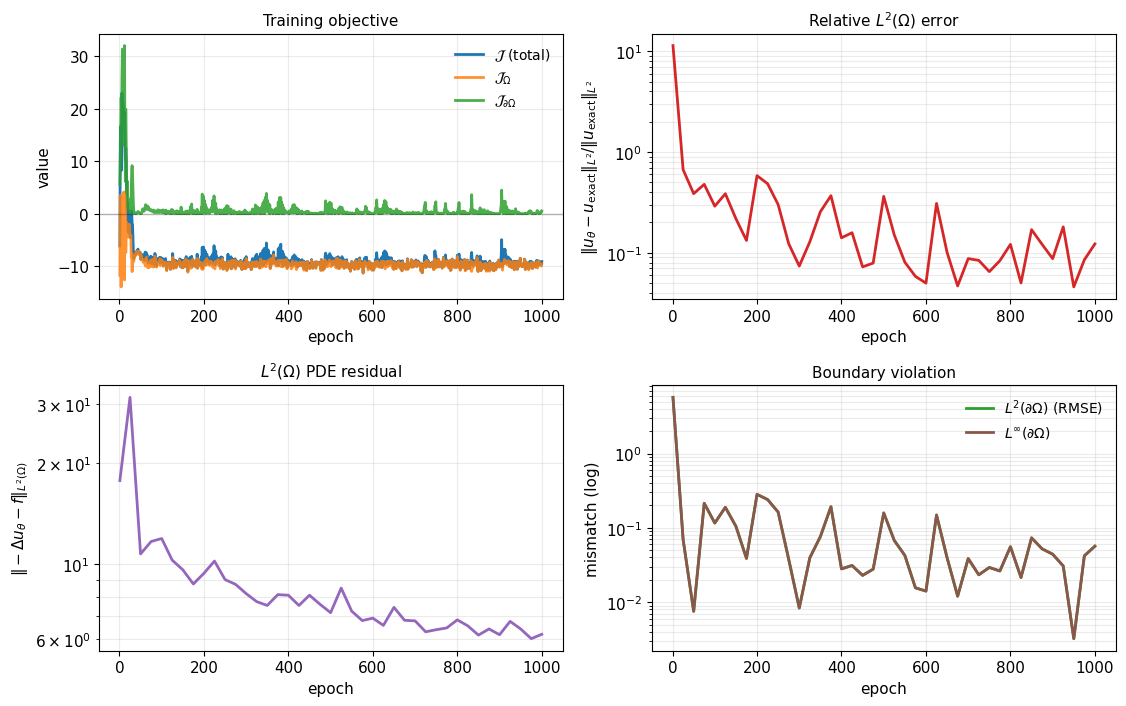

In [ ]:
# 2D Poisson: Yu & E–style diagnostics (NumPy + matplotlib only)
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

H2 = hist_poisson_2d

loss_total = H2['losses_total']
loss_int = H2['losses_int']
loss_bc = H2['losses_bc']
epochs_arr = np.arange(1, loss_total.size + 1)

ep2 = H2['diag_epochs']
rel_l2_2d = H2['rel_l2']
pde_res_l2_2d = H2['pde_res_l2']
bc_l2_2d = H2['bc_l2']
bc_linf_2d = H2['bc_linf']

mpl.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

eps_plot = 1e-16
fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.2))

# 1) Training objective value (note: Ritz energies can be negative)
ax = axes[0, 0]
ax.plot(epochs_arr, loss_total, color='C0', label=r'$\mathcal{J}$ (total)')
ax.plot(epochs_arr, loss_int, color='C1', alpha=0.85, label=r'$\mathcal{J}_\Omega$')
ax.plot(epochs_arr, loss_bc, color='C2', alpha=0.85, label=r'$\mathcal{J}_{\partial\Omega}$')
ax.axhline(0.0, color='k', lw=1.0, alpha=0.25)
ax.set_title('Training objective')
ax.set_xlabel('epoch')
ax.set_ylabel('value')
ax.grid(True, alpha=0.25)
ax.legend(loc='best', frameon=False)

# 2) Relative L2 error
ax = axes[0, 1]
ax.semilogy(ep2, np.maximum(rel_l2_2d, eps_plot), color='C3')
ax.set_title(r'Relative $L^2(\Omega)$ error')
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\|u_\theta-u_{\mathrm{exact}}\|_{L^2}/\|u_{\mathrm{exact}}\|_{L^2}$')
ax.grid(True, which='both', alpha=0.25)

# 3) PDE residual norm
ax = axes[1, 0]
ax.semilogy(ep2, np.maximum(pde_res_l2_2d, eps_plot), color='C4')
ax.set_title(r'$L^2(\Omega)$ PDE residual')
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\| -\Delta u_\theta - f \|_{L^2(\Omega)}$')
ax.grid(True, which='both', alpha=0.25)

# 4) Boundary mismatch norms
ax = axes[1, 1]
ax.semilogy(ep2, np.maximum(bc_l2_2d, eps_plot), color='C2', label=r'$L^2(\partial\Omega)$ (RMSE)')
ax.semilogy(ep2, np.maximum(bc_linf_2d, eps_plot), color='C5', label=r'$L^\infty(\partial\Omega)$')
ax.set_title('Boundary violation')
ax.set_xlabel('epoch')
ax.set_ylabel('mismatch (log)')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='best', frameon=False)

fig.tight_layout()
plt.show()

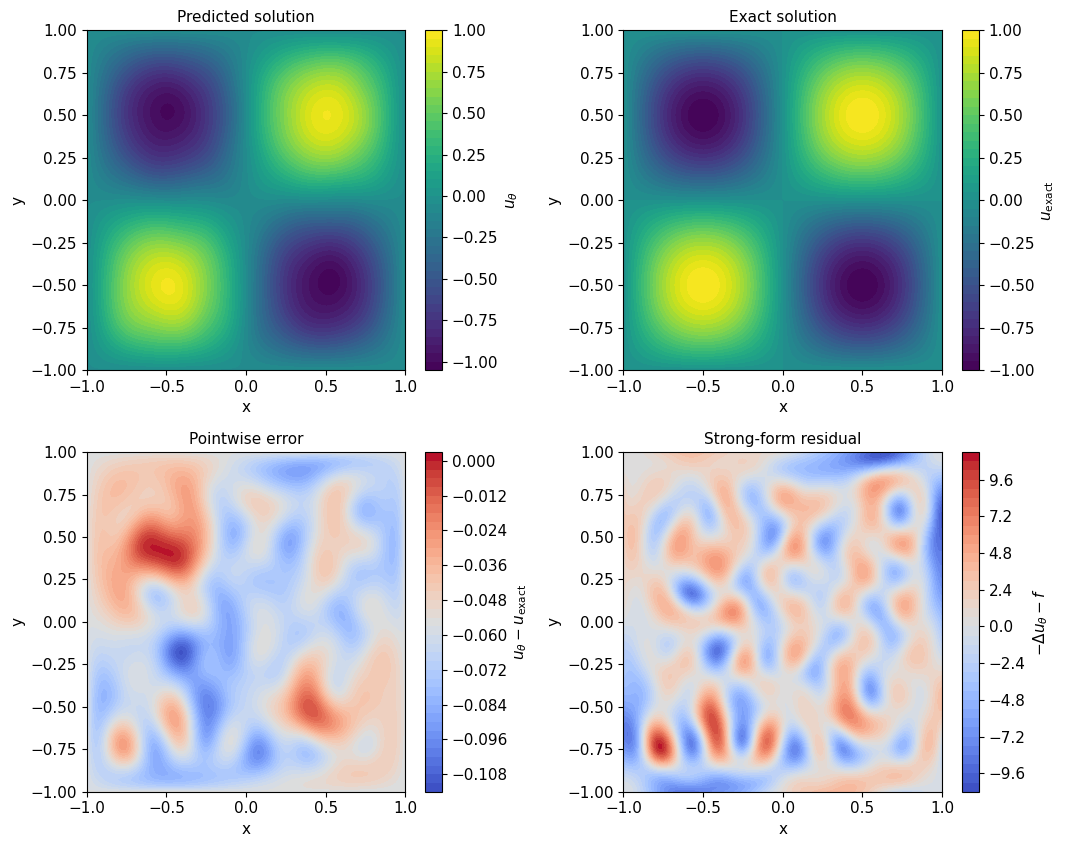

In [ ]:
# 2D Poisson: visualize u_theta vs u_exact (and error/residual)
import numpy as np
import matplotlib.pyplot as plt

xv = np.linspace(-1.0, 1.0, 161)
yv = np.linspace(-1.0, 1.0, 161)
Xv, Yv = np.meshgrid(xv, yv, indexing='xy')
x_flat = Xv.reshape(-1)
y_flat = Yv.reshape(-1)

a_viz = hist_poisson_2d['a_readout']
u, _, _, u_xx, u_yy = eval_u_and_derivatives(
    model_poisson_2d, x_flat, y_flat, a_readout=a_viz, cache_fields=True,
    embed_x_scale=float(hist_poisson_2d.get('embed_x_scale', 0.7)),
    embed_y_scale=float(hist_poisson_2d.get('embed_y_scale', 0.7)),
    embed_bias=float(hist_poisson_2d.get('embed_bias', 1.0)),
 )
u_pred = u.reshape(Yv.shape)
u_true = u_exact_square_sin(Xv, Yv)
err = u_pred - u_true
res = (-(u_xx + u_yy) - f_square_sin(x_flat, y_flat)).reshape(Yv.shape)

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.6))

ax = axes[0, 0]
im = ax.contourf(Xv, Yv, u_pred, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$u_\theta$')
ax.set_title('Predicted solution')
ax.set_xlabel('x'); ax.set_ylabel('y')

ax = axes[0, 1]
im = ax.contourf(Xv, Yv, u_true, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$u_{\mathrm{exact}}$')
ax.set_title('Exact solution')
ax.set_xlabel('x'); ax.set_ylabel('y')

ax = axes[1, 0]
im = ax.contourf(Xv, Yv, err, levels=40, cmap='coolwarm')
fig.colorbar(im, ax=ax, label=r'$u_\theta-u_{\mathrm{exact}}$')
ax.set_title('Pointwise error')
ax.set_xlabel('x'); ax.set_ylabel('y')

ax = axes[1, 1]
im = ax.contourf(Xv, Yv, res, levels=40, cmap='coolwarm')
fig.colorbar(im, ax=ax, label=r'$-\Delta u_\theta - f$')
ax.set_title('Strong-form residual')
ax.set_xlabel('x'); ax.set_ylabel('y')

fig.tight_layout()
plt.show()